## Data Collection

In [2]:
import pandas as pd
import numpy as np
import matplotlib
import seaborn
import sklearn
import xgboost
import lightgbm
import tensorflow
import keras
import random
import time
import os

# Print versions
print("Library Versions:")
print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")
print(f"matplotlib: {matplotlib.__version__}")
print(f"seaborn: {seaborn.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"xgboost: {xgboost.__version__}")
print(f"lightgbm: {lightgbm.__version__}")
print(f"tensorflow: {tensorflow.__version__}")
print(f"keras: {keras.__version__}")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

Library Versions:
pandas: 2.2.3
numpy: 2.1.3
matplotlib: 3.10.0
seaborn: 0.13.2
scikit-learn: 1.6.1
xgboost: 3.1.2
lightgbm: 4.6.0
tensorflow: 2.20.0
keras: 3.12.0


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)

In [4]:
df = pd.read_csv("dataset_small.csv")

# Dataset shape
shape_df = pd.DataFrame({
    "Metric": ["Rows", "Columns"],
    "Value": [df.shape[0], df.shape[1]]
})
display(shape_df)

# Data types
dtype_counts = df.dtypes.value_counts().reset_index()
dtype_counts.columns = ["Data Type", "Count"]
display(dtype_counts)

missing_total = df.isnull().sum()
missing_df = pd.DataFrame(missing_total[missing_total > 0])
if missing_df.empty:
    display(pd.DataFrame({
        "Status": ["No missing values detected"],
        "Total Missing": [0]
    }))
else:
    missing_df.columns = ["Missing Count"]
    display(missing_df)

# Duplicate rows
duplicate_count = df.duplicated().sum()
duplicate_df = pd.DataFrame({
    "Status": ["No duplicates found" if duplicate_count == 0 else "Duplicate rows found"],
    "Total Duplicates": [duplicate_count]
})
display(duplicate_df)

# Class distribution
target_counts = df['phishing'].value_counts().reset_index()
target_counts.columns = ['Class', 'Count']
target_counts['Percentage'] = round(target_counts['Count'] / df.shape[0] * 100, 2)
display(target_counts)

# Summary stats (first few columns only for brevity)
summary_stats = df.describe().T.head()
display(summary_stats)

,Metric,Value
0,Rows,58645
1,Columns,112


,Data Type,Count
0,int64,111
1,float64,1


,Status,Total Missing
0,No missing values detected,0


,Status,Total Duplicates
0,Duplicate rows found,1240


,Class,Count,Percentage
0,1,30647,52.26
1,0,27998,47.74


,count,mean,std,min,25%,50%,75%,max
qty_dot_url,58645.0,2.284338,1.473209,1.0,2.0,2.0,3.0,24.0
qty_hyphen_url,58645.0,0.457123,1.339340,0.0,0.0,0.0,0.0,35.0
qty_underline_url,58645.0,0.171285,0.801919,0.0,0.0,0.0,0.0,21.0
qty_slash_url,58645.0,1.937522,2.037525,0.0,0.0,1.0,3.0,44.0
qty_questionmark_url,58645.0,0.014102,0.138156,0.0,0.0,0.0,0.0,9.0



Class Distribution:
 phishing
1    30647
0    27998
Name: count, dtype: int64


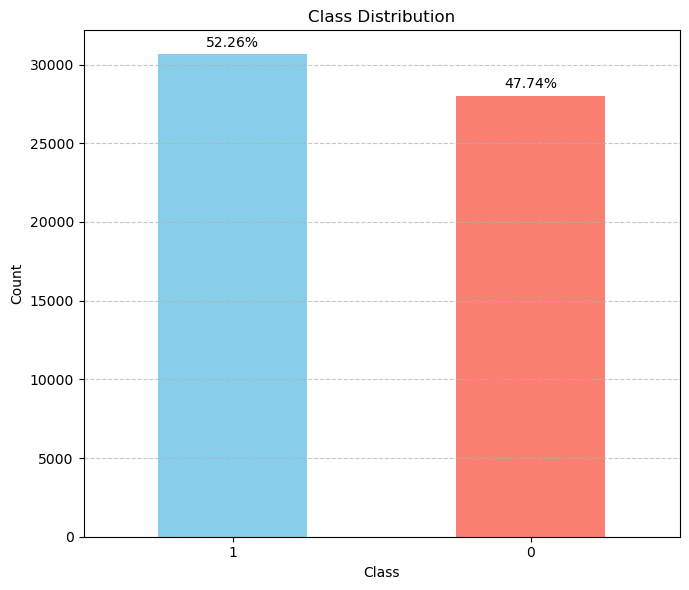

In [5]:
import matplotlib.pyplot as plt

class_column = 'phishing'  # change to your actual class column name if different

# Show class distribution
class_counts = df[class_column].value_counts()
print("\nClass Distribution:\n", class_counts)

# Calculate percentages
class_percentages = class_counts / class_counts.sum() * 100

# Plot bar chart
plt.figure(figsize=(7, 6))
bars = class_counts.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add percentage text on top of bars
for i, (count, pct) in enumerate(zip(class_counts, class_percentages)):
    plt.text(i, count + max(class_counts)*0.01, f'{pct:.2f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


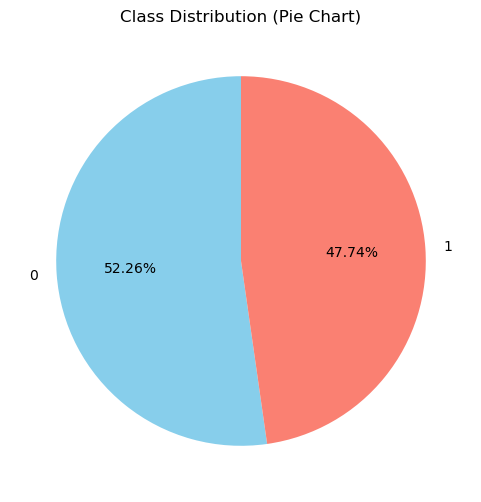

Class Imbalance Ratio (Major/Minor): 0.91


In [6]:
plt.figure(figsize=(6,6))
plt.pie(df['phishing'].value_counts(), labels=df['phishing'].unique(),
        autopct='%1.2f%%', colors=['skyblue','salmon'], startangle=90)
plt.title("Class Distribution (Pie Chart)")
plt.show()

imbalance_ratio = df['phishing'].value_counts()[0] / df['phishing'].value_counts()[1]
print(f"Class Imbalance Ratio (Major/Minor): {imbalance_ratio:.2f}")


## Data Preprocessing

### Check & handle missing values

In [7]:
df_cleaned = df.copy()

# Check for missing values
print("----------Missing Values Count per Column ----------")
missing_counts = df_cleaned.isnull().sum()
print(missing_counts[missing_counts > 0])

# If missing values exist, fill them with mean (only for numeric columns)
if missing_counts.sum() > 0:
    df_cleaned.fillna(df_cleaned.mean(numeric_only=True), inplace=True)
    print("\nMissing values have been imputed with mean.")
else:
    print("\nNo missing values found. No imputation needed.")

----------Missing Values Count per Column ----------
Series([], dtype: int64)

No missing values found. No imputation needed.


### Check & drop duplicate rows

In [8]:
duplicate_count = df_cleaned.duplicated().sum()
print(f"\n----------Duplicate Check----------\nFound {duplicate_count} duplicate rows.")

if duplicate_count > 0:
    df_cleaned.drop_duplicates(inplace=True)
    print(f"\nDropped {duplicate_count} duplicate rows.\nNew shape: {df_cleaned.shape}")
else:
    print("\nNo duplicate rows found.")


----------Duplicate Check----------
Found 1240 duplicate rows.

Dropped 1240 duplicate rows.
New shape: (57405, 112)


### Dropping Single-Valued Columns

In [9]:
print("----------Single-Valued Columns----------\n")
single_val_cols = []

for col in df_cleaned.columns:
    if df_cleaned[col].nunique() == 1:
        single_val_cols.append(col)

if single_val_cols:
    print(f"Found {len(single_val_cols)} single-valued columns:")
    df_cleaned.drop(columns=single_val_cols, inplace=True)
    for col in single_val_cols:
        print(f"{col}")
    print(f"\nDropped {len(single_val_cols)} columns.")
else:
    print("\nNo single-valued columns found.")

----------Single-Valued Columns----------

Found 13 single-valued columns:
qty_slash_domain
qty_questionmark_domain
qty_equal_domain
qty_and_domain
qty_exclamation_domain
qty_space_domain
qty_tilde_domain
qty_comma_domain
qty_plus_domain
qty_asterisk_domain
qty_hashtag_domain
qty_dollar_domain
qty_percent_domain

Dropped 13 columns.


### Removing Problematic Binary Columns

In [10]:
print("\n----------Dropping Binary Columns with -1----------")

binary_columns_with_minus_one = [
    col for col in df_cleaned.columns
    if sorted(df_cleaned[col].dropna().unique().tolist()) in [[-1, 0], [-1, 1]]
]

if binary_columns_with_minus_one:
    print(f"Found {len(binary_columns_with_minus_one)} binary columns with [-1, 0] or [-1, 1]:")
    for col in binary_columns_with_minus_one:
        print(f"{col}")
    df_cleaned.drop(columns=binary_columns_with_minus_one, inplace=True)
    print(f"\nDropped {len(binary_columns_with_minus_one)} columns.")
else:
    print("No binary (-1, 0) or (-1, 1) columns found.")



----------Dropping Binary Columns with -1----------
Found 7 binary columns with [-1, 0] or [-1, 1]:
qty_questionmark_directory
qty_hashtag_directory
qty_slash_file
qty_questionmark_file
qty_hashtag_file
qty_dollar_file
qty_hashtag_params

Dropped 7 columns.


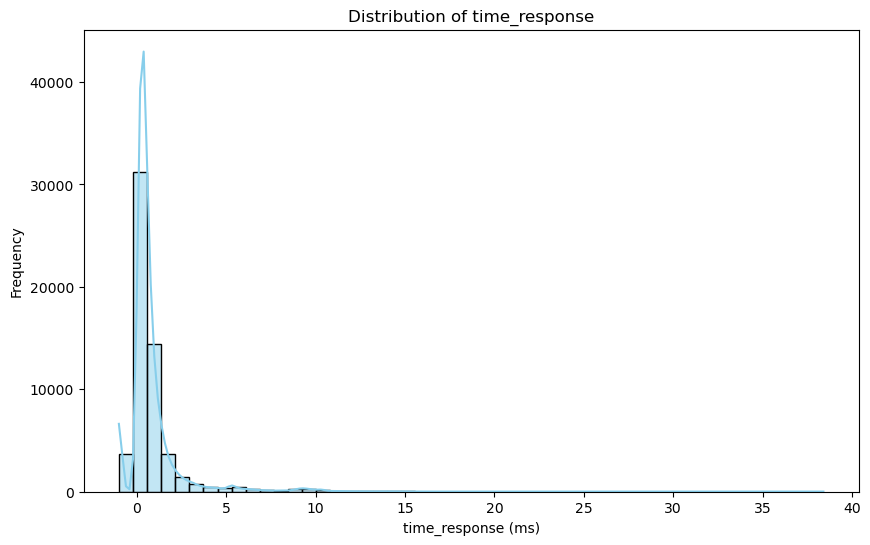

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df_cleaned['time_response'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of time_response')
plt.xlabel('time_response (ms)')
plt.ylabel('Frequency')
plt.show()


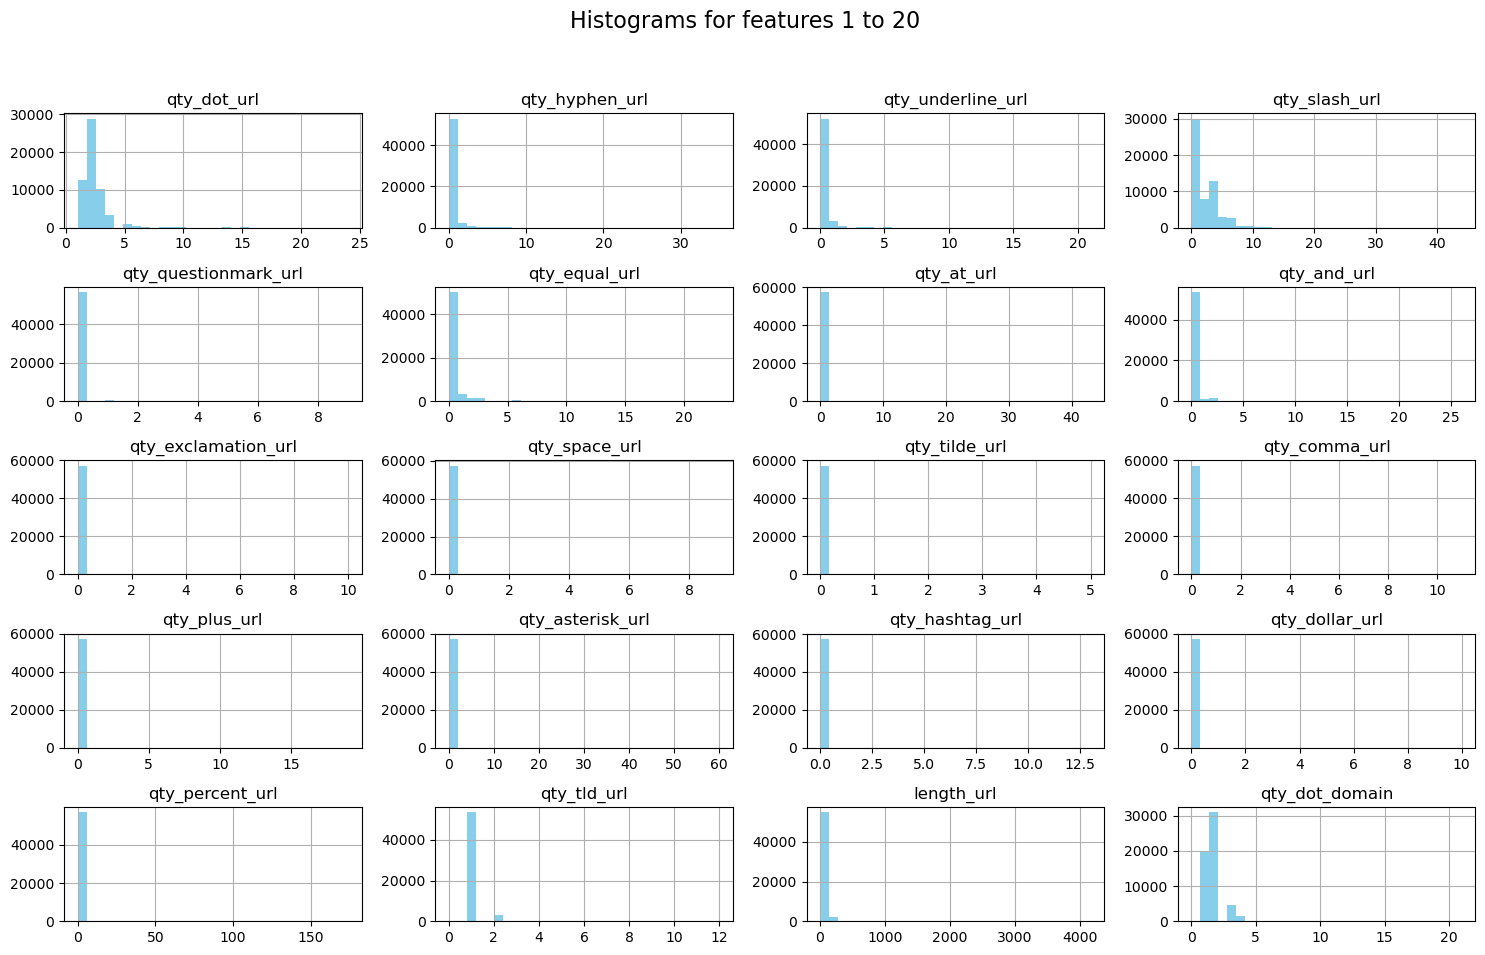

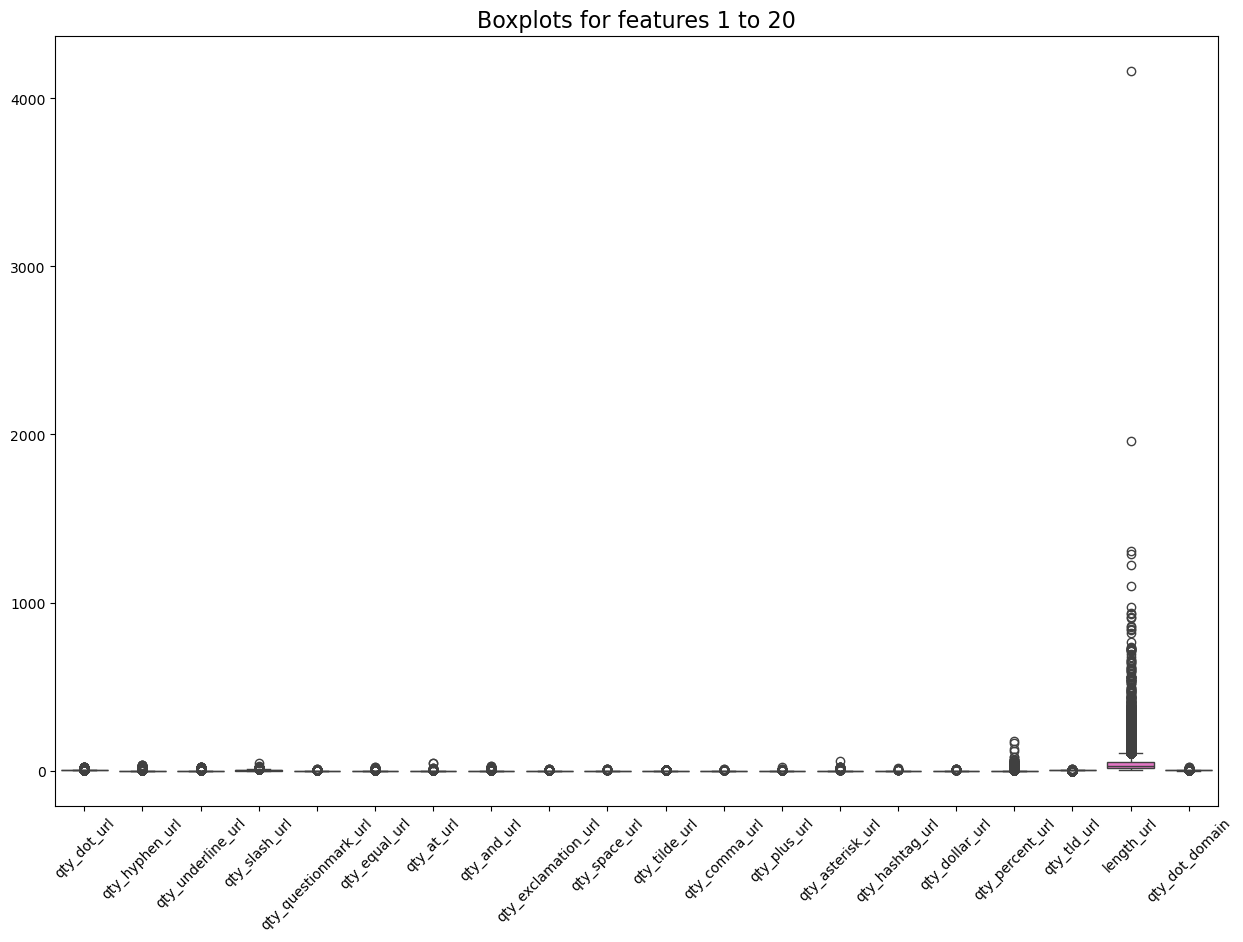

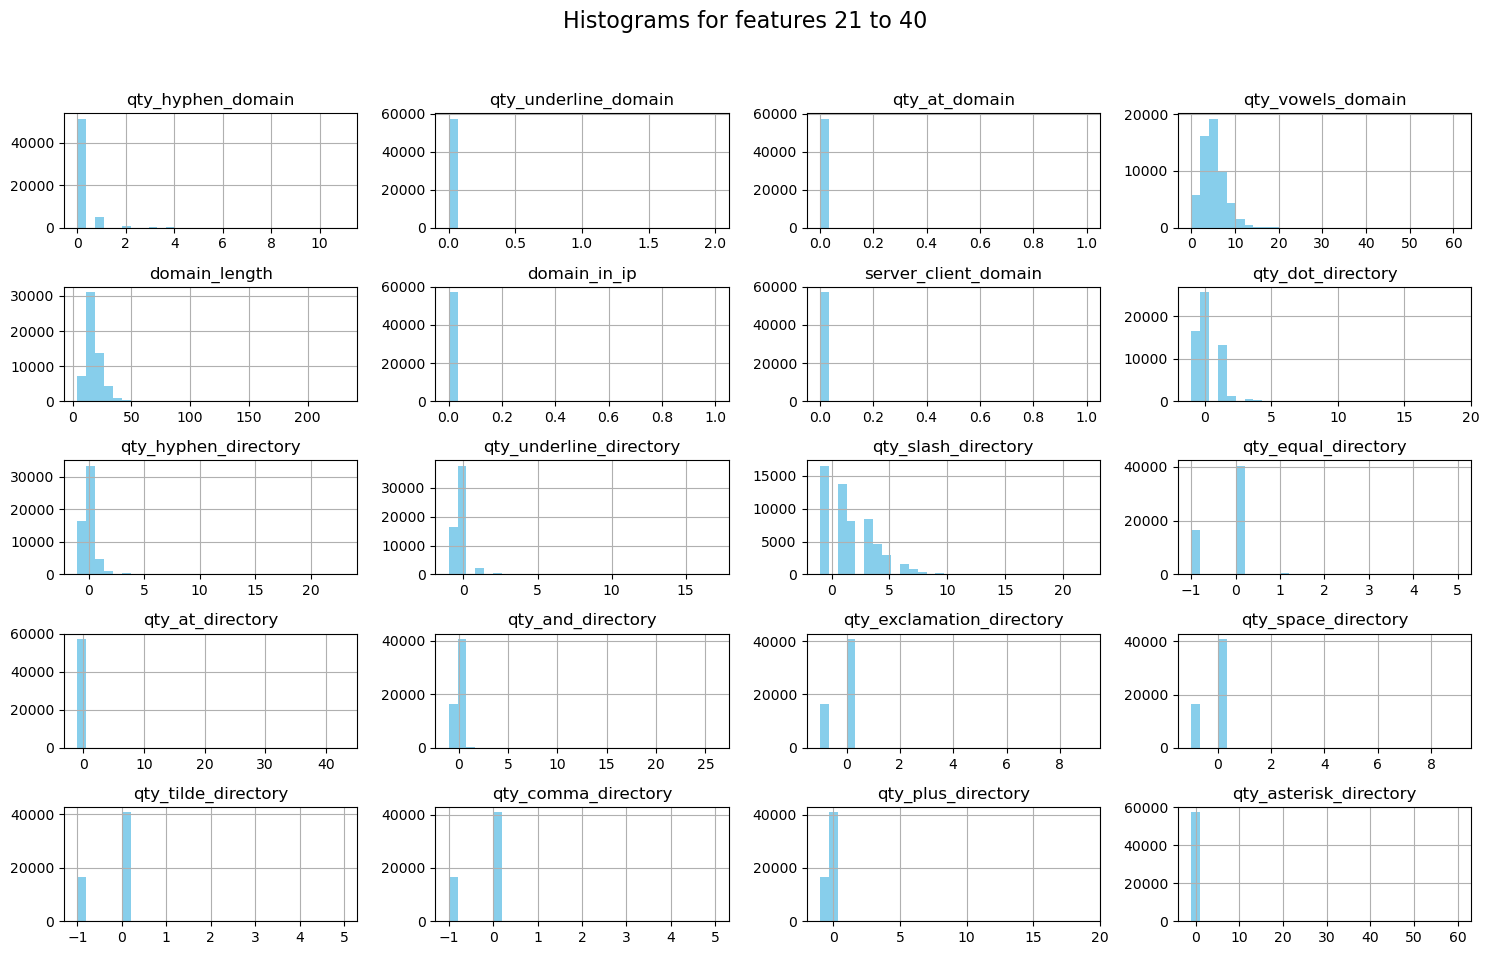

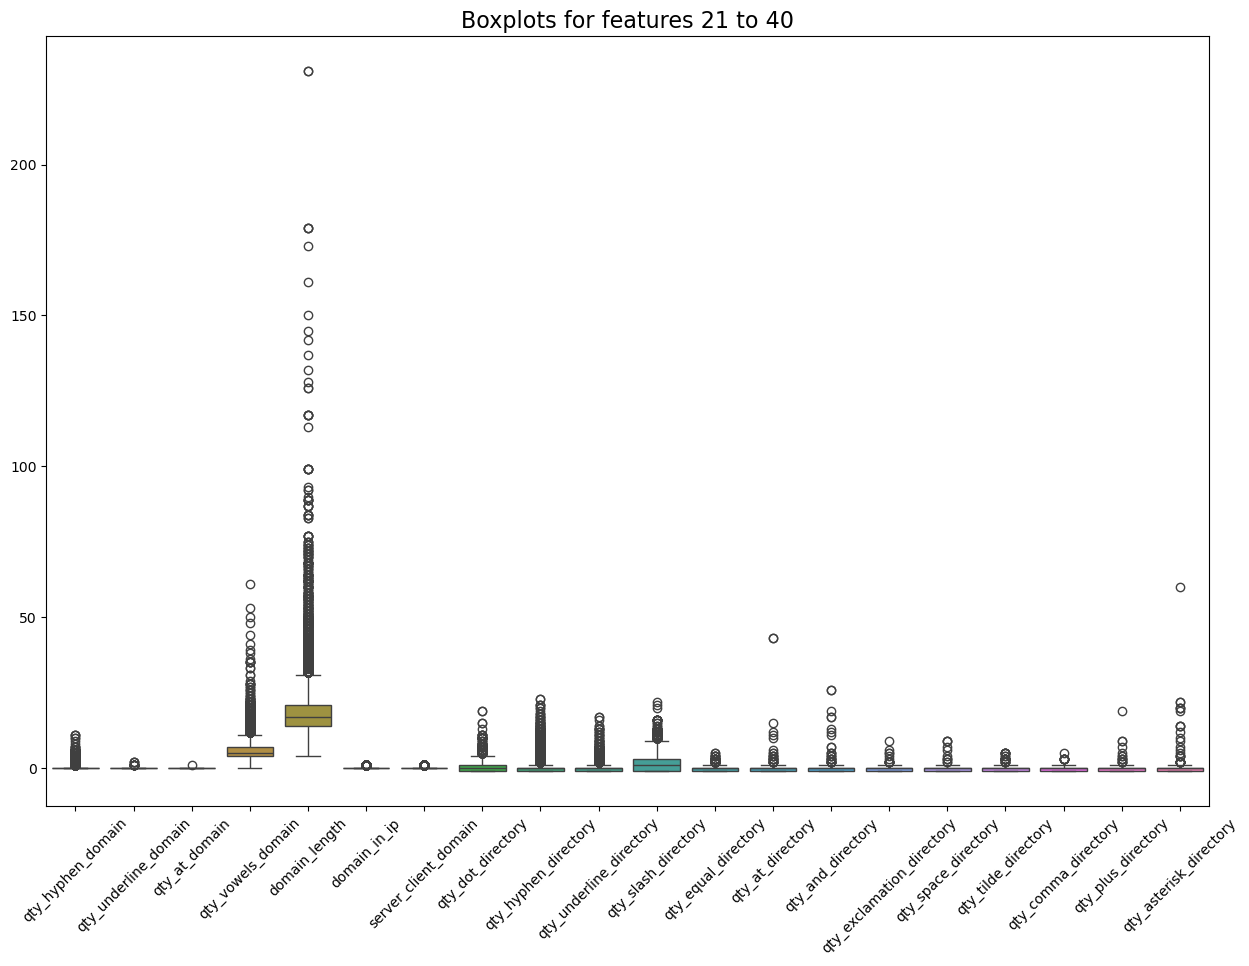

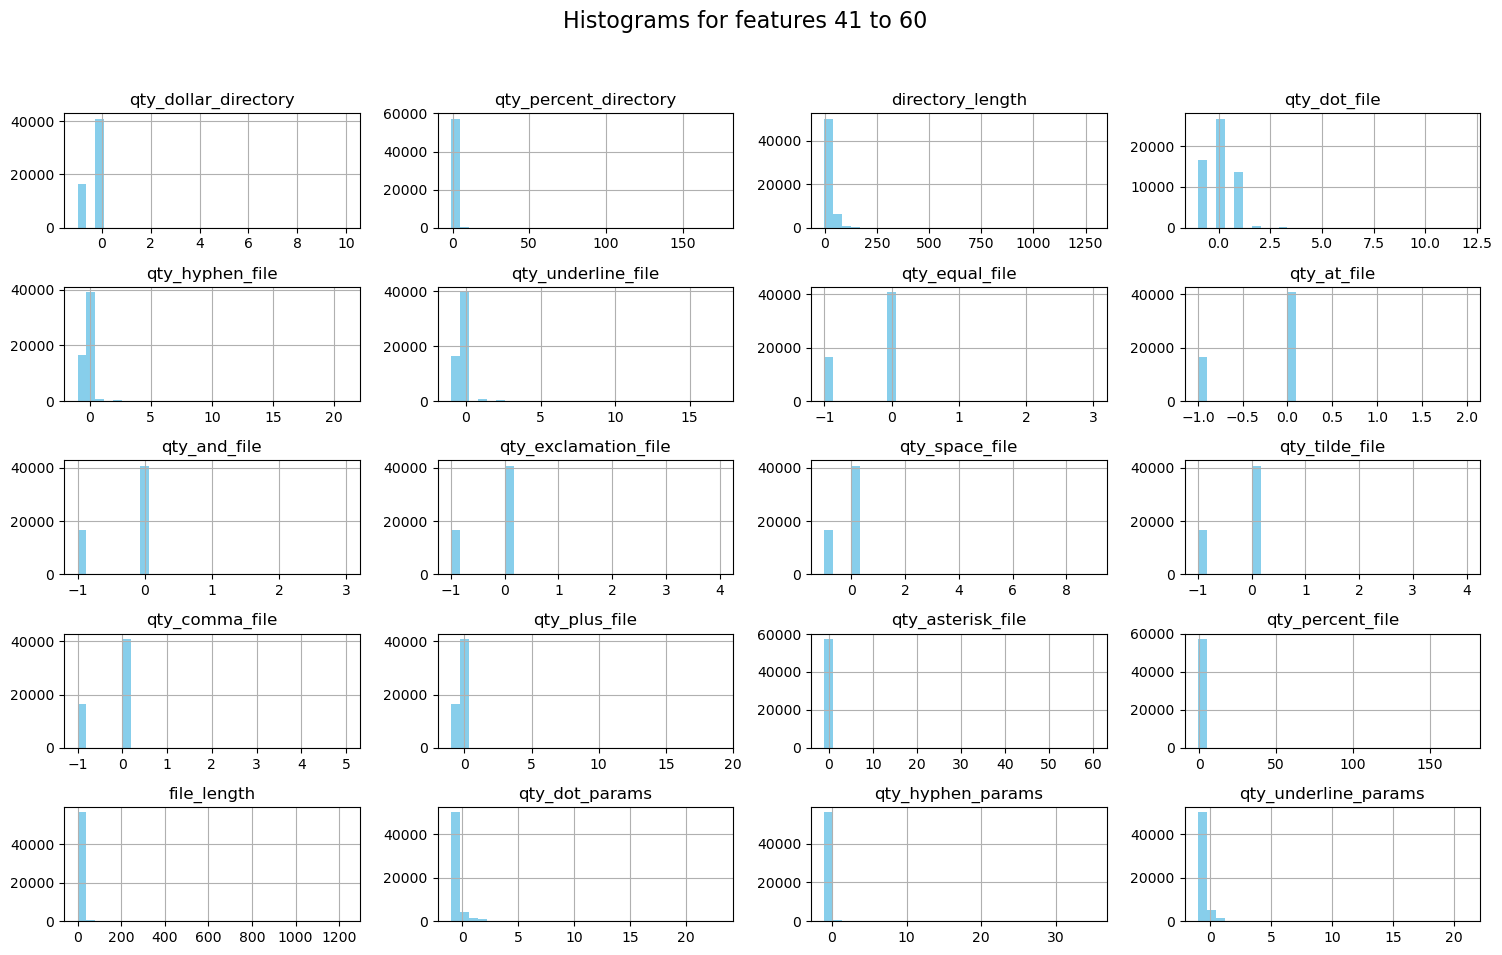

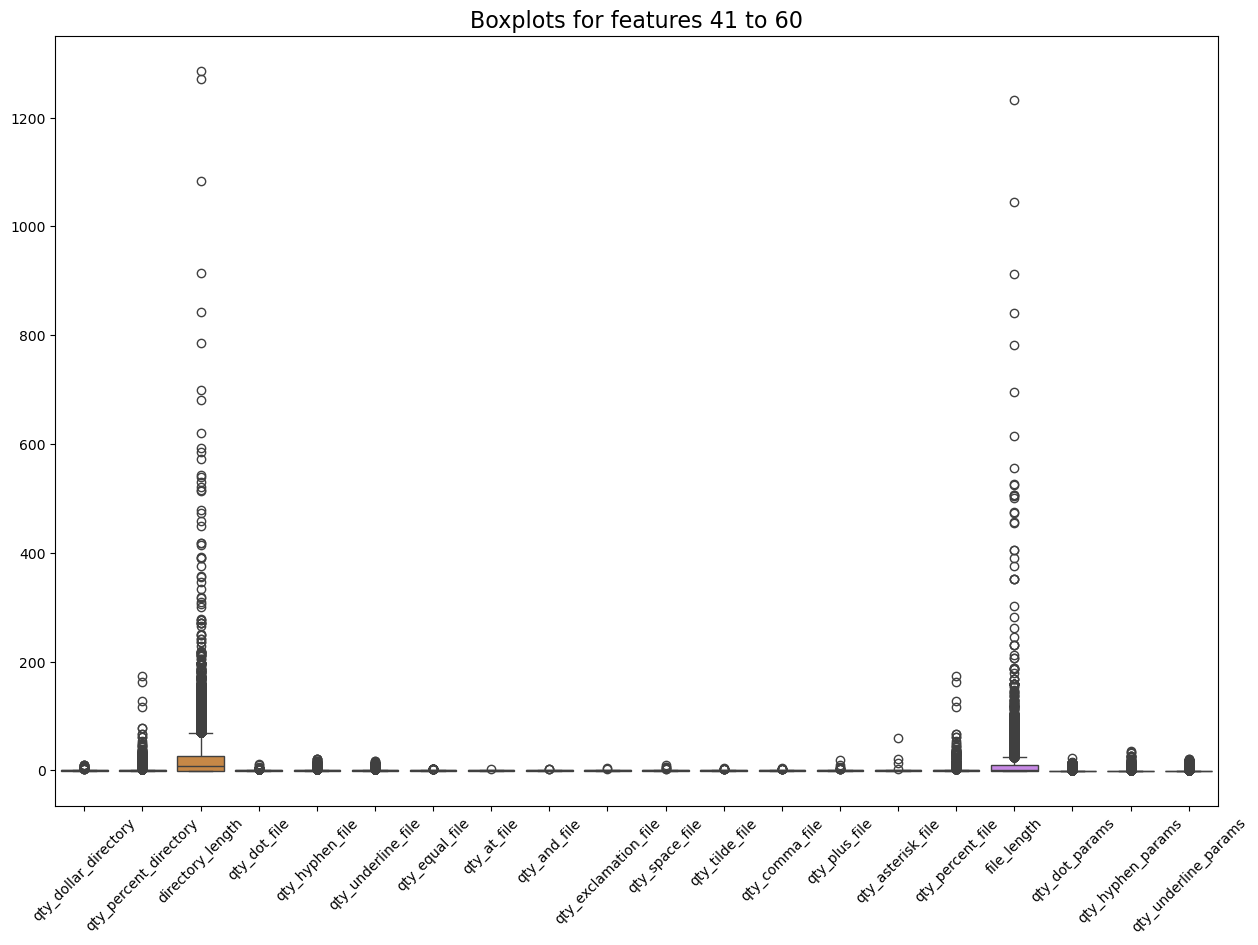

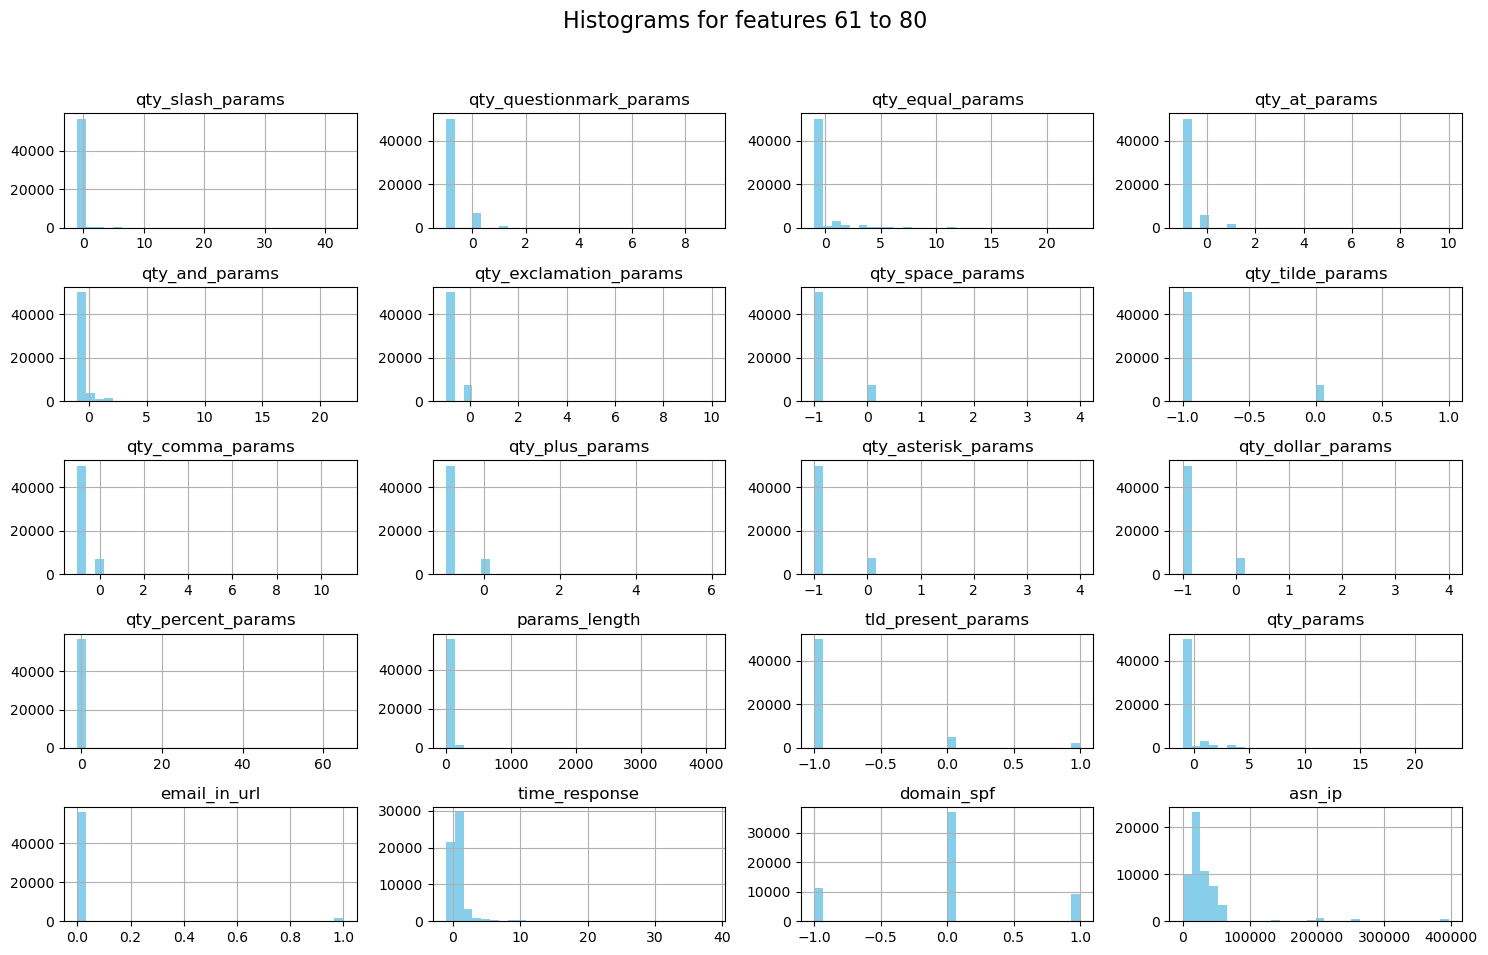

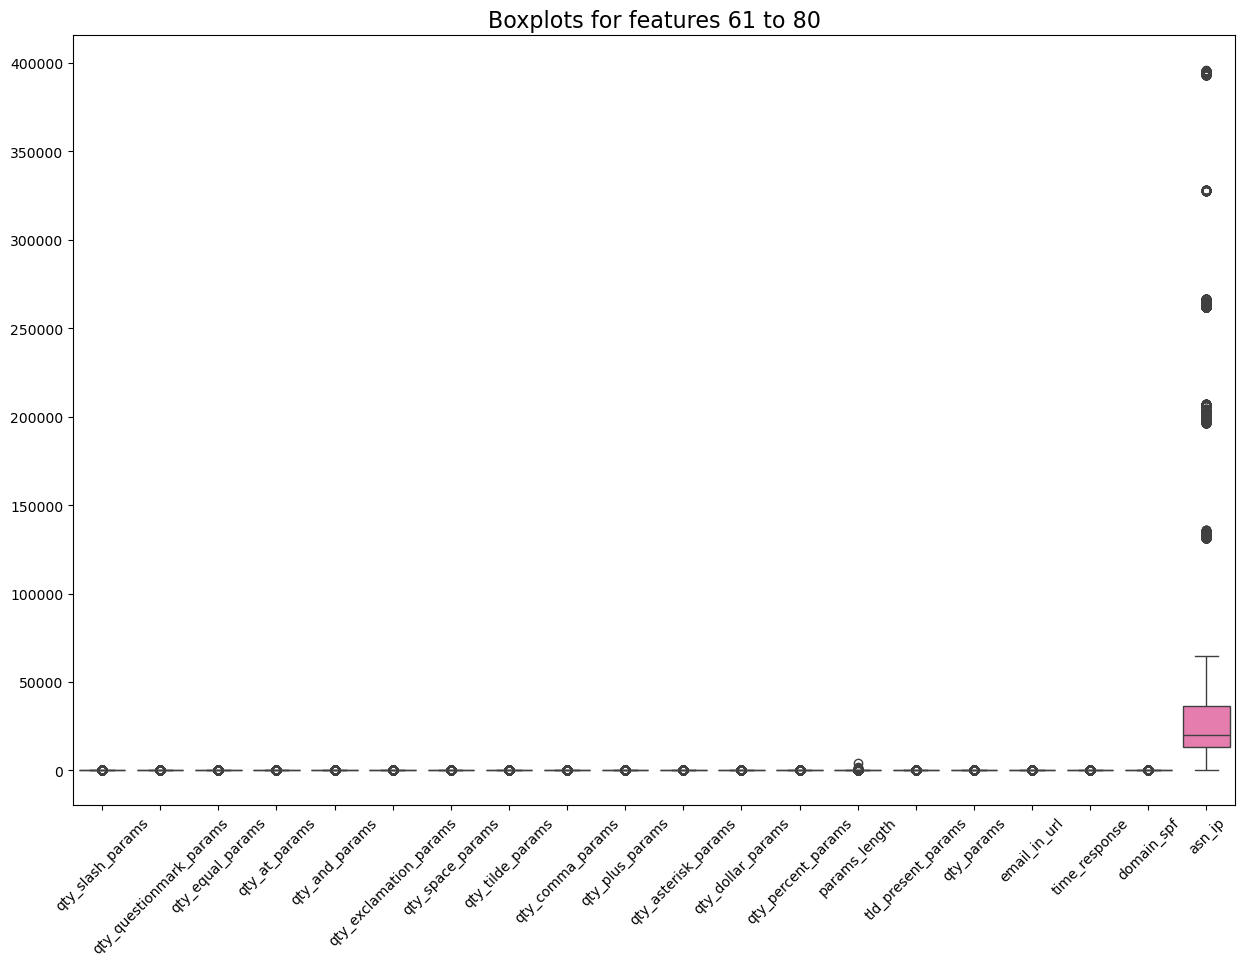

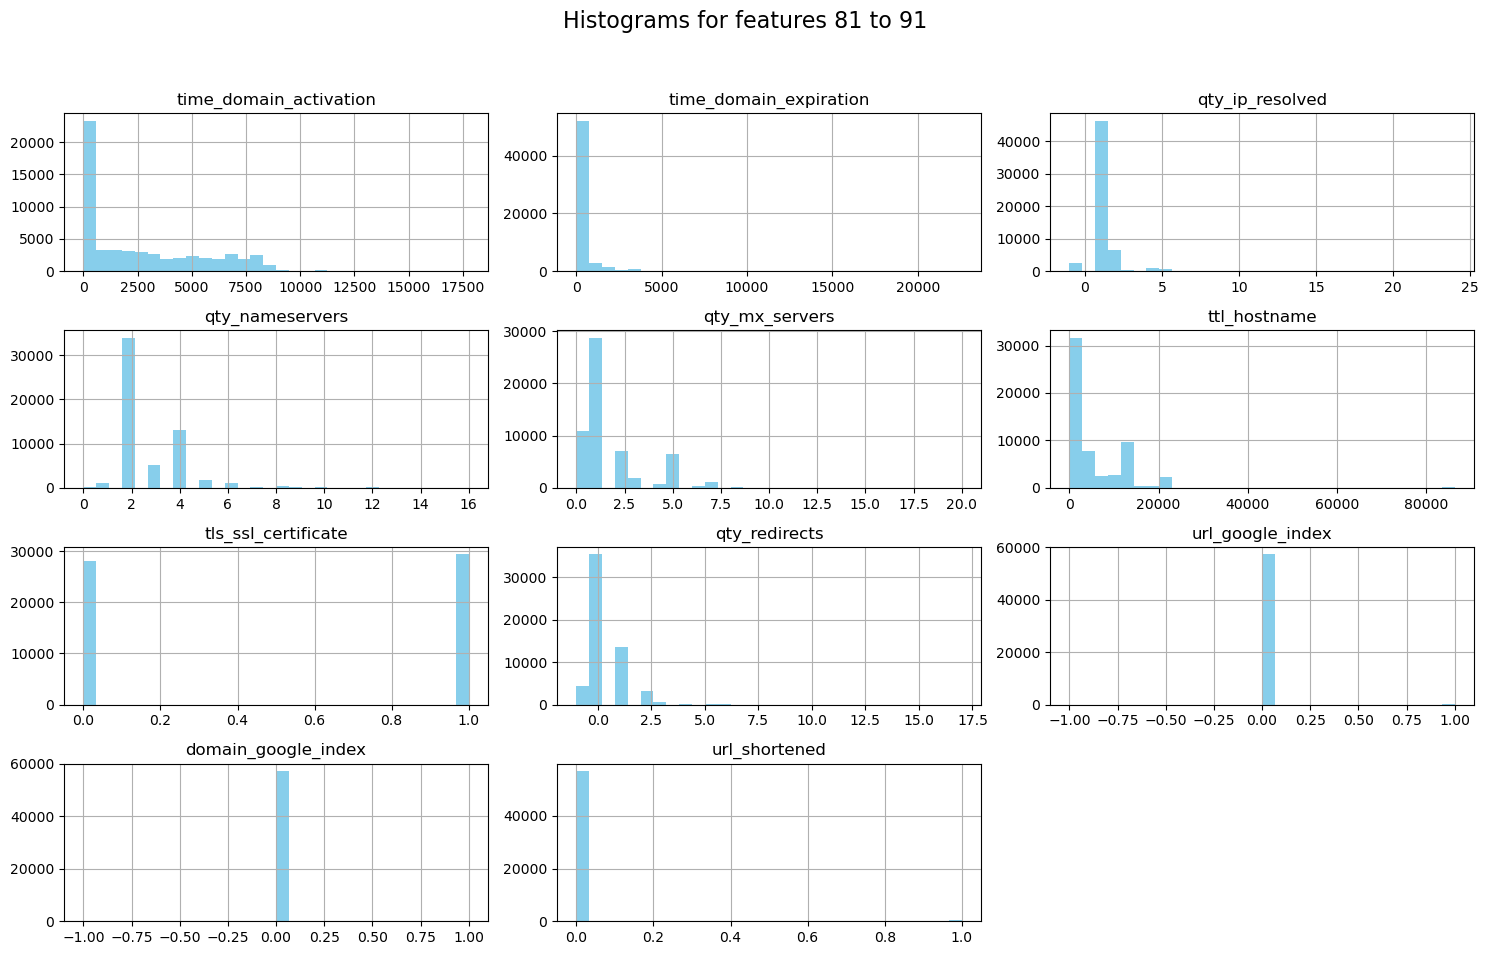

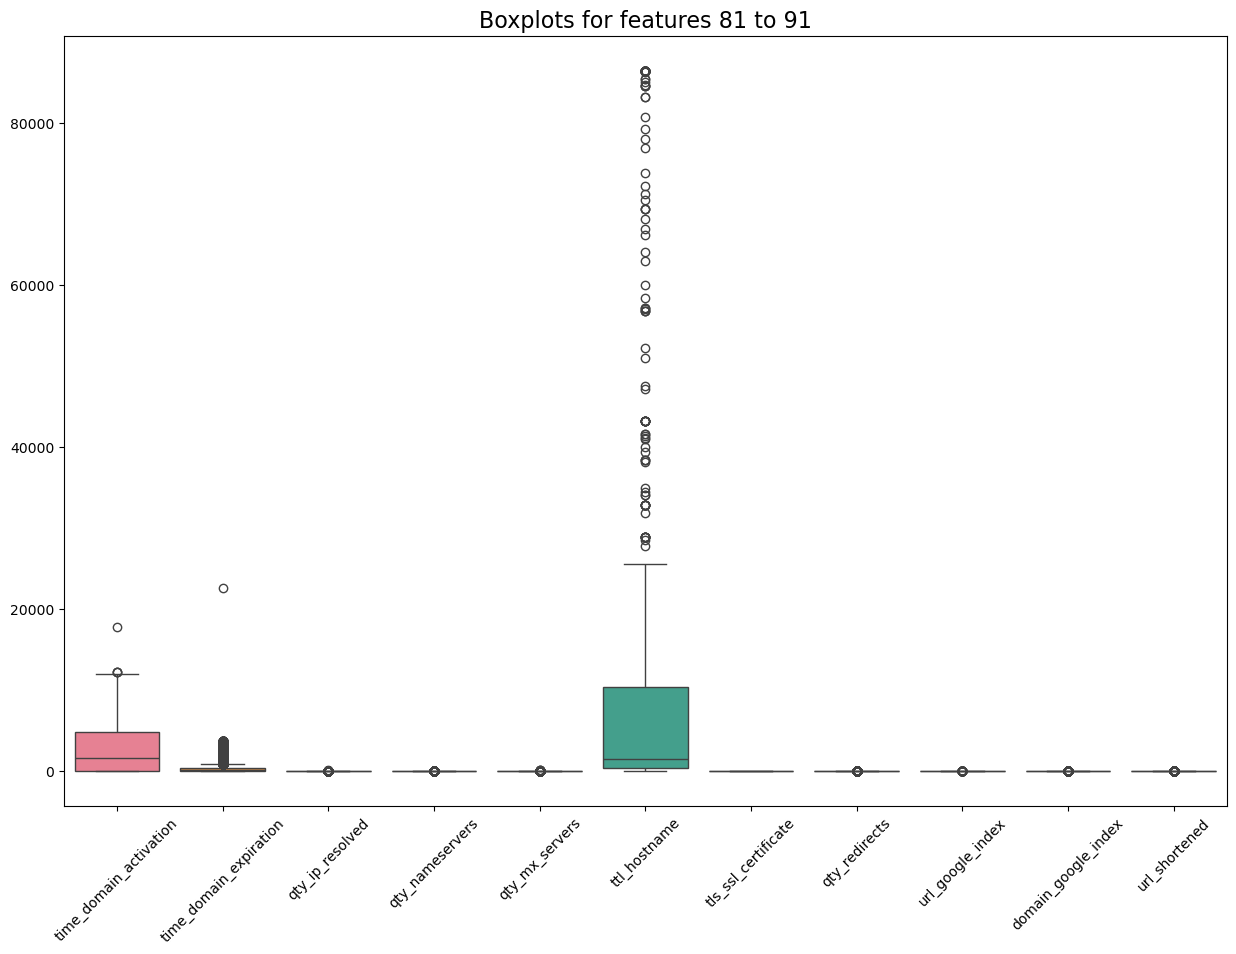

In [12]:
numeric_cols = df_cleaned.select_dtypes(include=np.number).columns.tolist()
numeric_cols.remove('phishing')  # remove target

# Batch plotting
batch_size = 20
for i in range(0, len(numeric_cols), batch_size):
    cols_batch = numeric_cols[i:i+batch_size]

    # Histograms
    df_cleaned[cols_batch].hist(bins=30, figsize=(15,10), color='skyblue')
    plt.suptitle(f'Histograms for features {i+1} to {i+len(cols_batch)}', fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    # Boxplots
    plt.figure(figsize=(15,10))
    sns.boxplot(data=df_cleaned[cols_batch])
    plt.title(f'Boxplots for features {i+1} to {i+len(cols_batch)}', fontsize=16)
    plt.xticks(rotation=45)
    plt.show()


### Train-test split

In [13]:
X = df_cleaned.drop(columns=['phishing'])
y = df_cleaned['phishing']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

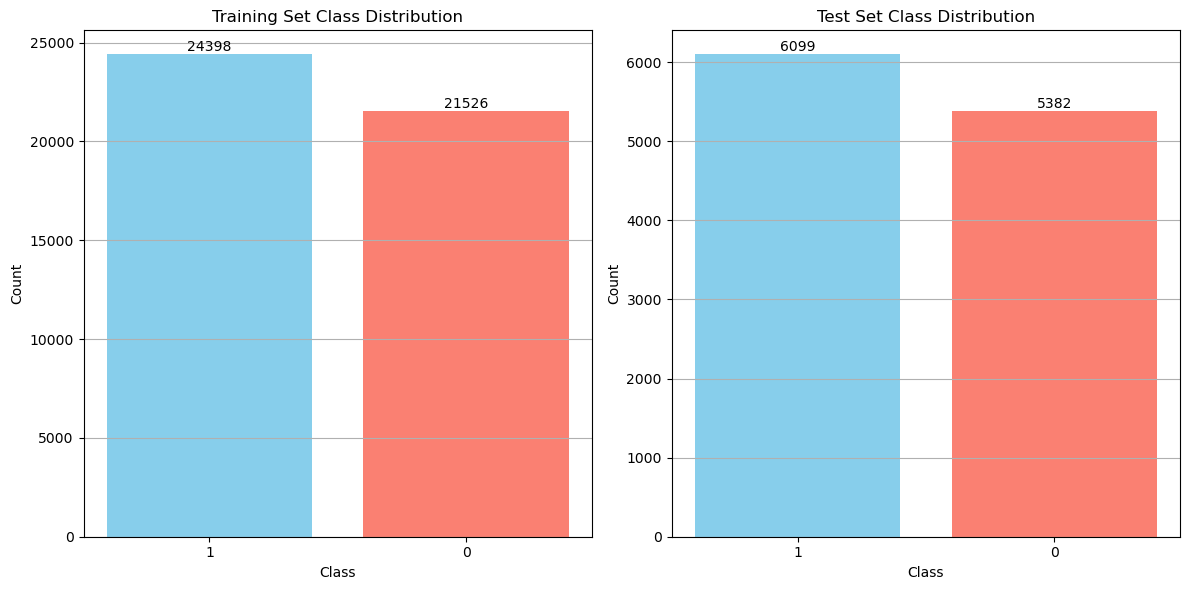

In [14]:
import matplotlib.pyplot as plt

# Get value counts
overall_counts = y.value_counts()
train_counts = y_train.value_counts()
test_counts = y_test.value_counts()

# Create a figure with 2 subplots: Training and Test set distributions
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# --- Training set distribution ---
axs[0].bar(train_counts.index.astype(str), train_counts.values, color=['skyblue', 'salmon'])
axs[0].set_title('Training Set Class Distribution')
axs[0].set_xlabel('Class')
axs[0].set_ylabel('Count')
axs[0].grid(axis='y')

# Add count labels on top of bars
for i, value in enumerate(train_counts.values):
    axs[0].text(i, value + 1, str(value), ha='center', va='bottom')

# --- Test set distribution ---
axs[1].bar(test_counts.index.astype(str), test_counts.values, color=['skyblue', 'salmon'])
axs[1].set_title('Test Set Class Distribution')
axs[1].set_xlabel('Class')
axs[1].set_ylabel('Count')
axs[1].grid(axis='y')

# Add count labels on top of bars
for i, value in enumerate(test_counts.values):
    axs[1].text(i, value + 1, str(value), ha='center', va='bottom')

plt.tight_layout()
plt.show()


### Outlier Detection

Outliers removed from training set: 460
New training shapes: X_train=(45464, 91), y_train=(45464,)


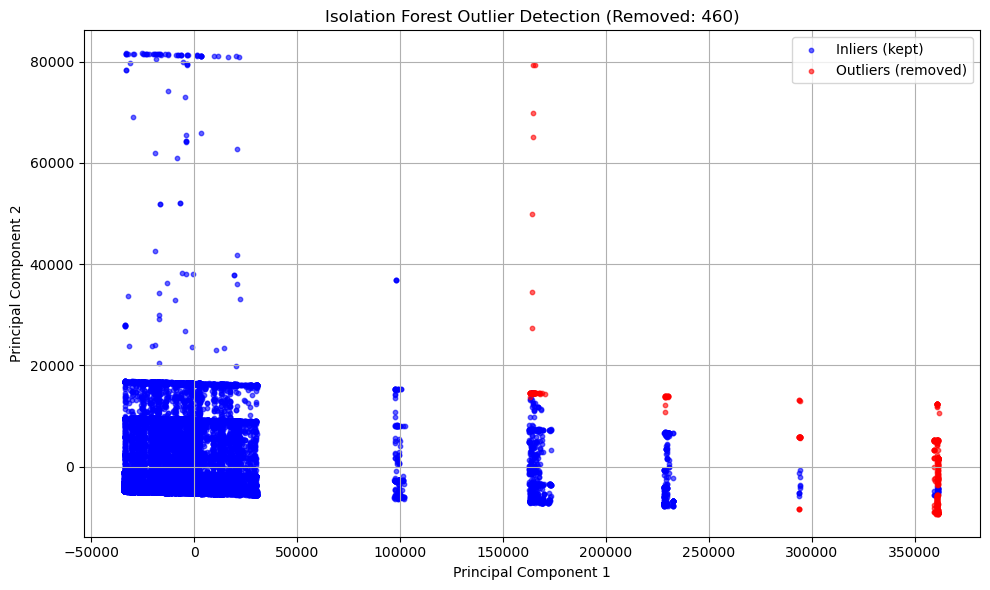

In [15]:
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# --------- Step 1: Outlier Detection on Original Training Data ---------
iso = IsolationForest(contamination=0.01, random_state=42)
outlier_preds = iso.fit_predict(X_train)

# Identify and count outliers
mask = outlier_preds == 1  # 1 = inlier, -1 = outlier
num_outliers = (~mask).sum()

# Apply the same mask to both X_train and y_train
X_train = X_train[mask].reset_index(drop=True)
y_train = y_train[mask].reset_index(drop=True)

print(f"Outliers removed from training set: {num_outliers}")
print(f"New training shapes: X_train={X_train.shape}, y_train={y_train.shape}")


# --------- Step 2: Apply PCA for Visualization ---------
pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train)

# Re-run IsolationForest just for visualization on PCA-reduced data
iso_vis = IsolationForest(contamination=0.01, random_state=42)
outlier_preds_vis = iso_vis.fit_predict(X_train_pca)

# --------- Step 3: Visualization ---------
plt.figure(figsize=(10, 6))
plt.scatter(
    X_train_pca[outlier_preds_vis == 1, 0],
    X_train_pca[outlier_preds_vis == 1, 1],
    c='blue', label='Inliers (kept)', s=10, alpha=0.6
)
plt.scatter(
    X_train_pca[outlier_preds_vis == -1, 0],
    X_train_pca[outlier_preds_vis == -1, 1],
    c='red', label='Outliers (removed)', s=10, alpha=0.6
)
plt.title(f"Isolation Forest Outlier Detection (Removed: {num_outliers})")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### Remove low-variance features

In [16]:
from sklearn.feature_selection import VarianceThreshold

# Record original number of features
original_feature_count = X_train.shape[1]

# Apply Variance Threshold
selector = VarianceThreshold(threshold=0.01)
X_train_reduced = pd.DataFrame(selector.fit_transform(X_train), columns=X_train.columns[selector.get_support()])
X_test_reduced = pd.DataFrame(selector.transform(X_test), columns=X_test.columns[selector.get_support()])

# Get number of features after selection
reduced_feature_count = X_train_reduced.shape[1]
features_removed = original_feature_count - reduced_feature_count

# Print results
print("\n----------Remove Low-Variance Features----------")
print(f"Number of features after variance thresholding: {reduced_feature_count}")
print(f"Number of features removed: {features_removed}")


----------Remove Low-Variance Features----------
Number of features after variance thresholding: 79
Number of features removed: 12


### Remove highly correlated features

In [17]:
corr_matrix = X_train.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_features = [col for col in upper.columns if any(upper[col] > 0.8)]

X_train.drop(columns=high_corr_features, inplace=True)
X_test.drop(columns=high_corr_features, inplace=True)
print("\n----------Correlation Analysis----------")
print(f"Highly correlated features removed: {len(high_corr_features)}")



----------Correlation Analysis----------
Highly correlated features removed: 37


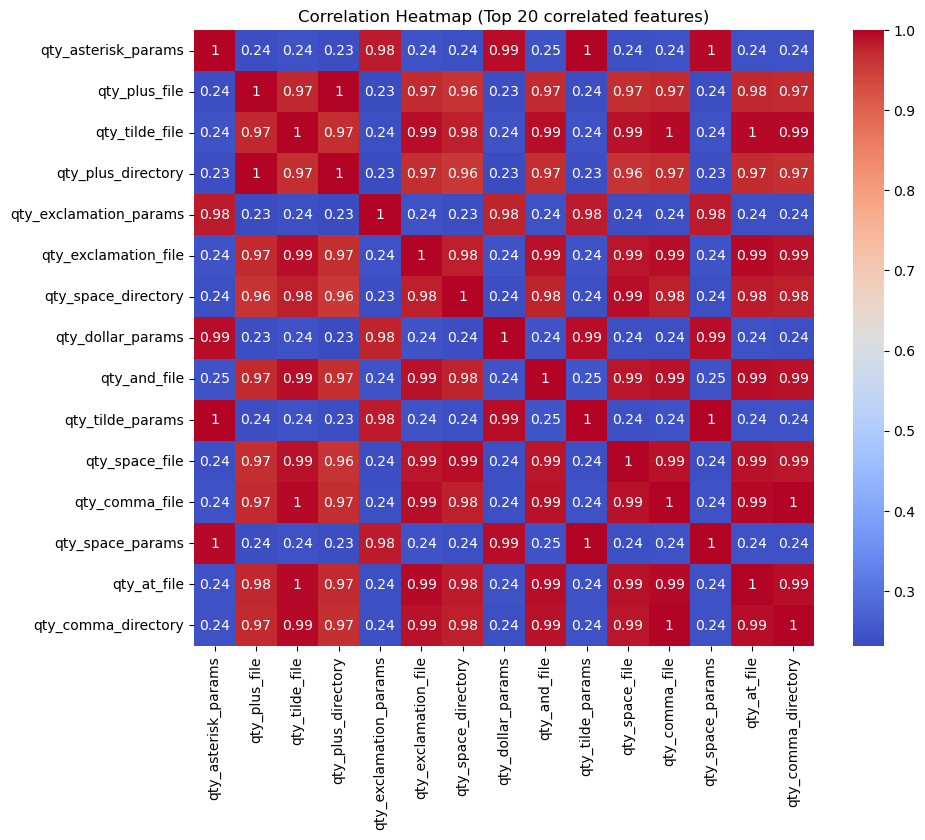

In [18]:
# Select top N correlated features
top_corr_pairs = upper.stack().sort_values(ascending=False).head(20)
top_features = list(set([i for pair in top_corr_pairs.index for i in pair]))

plt.figure(figsize=(10,8))
sns.heatmap(df_cleaned[top_features].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap (Top 20 correlated features)")
plt.show()


### Feature Scaling

In [19]:
scaler = MinMaxScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X_train.columns)

### Check Class Distribution

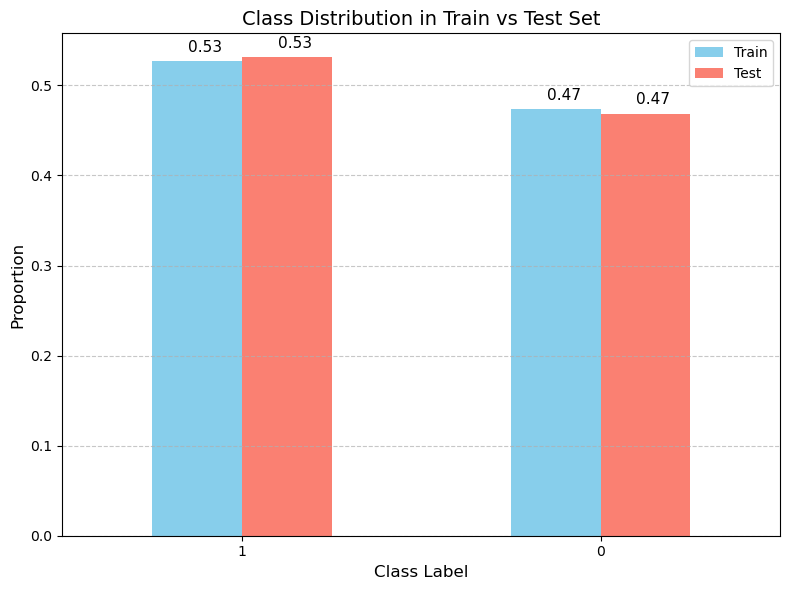

In [20]:
import matplotlib.pyplot as plt

# Compute normalized class distributions
train_dist = y_train.value_counts(normalize=True)
test_dist = y_test.value_counts(normalize=True)

# Create a DataFrame for visualization
dist_df = pd.DataFrame({
    'Train': train_dist,
    'Test': test_dist
})

# Plot
dist_df.plot(kind='bar', figsize=(8, 6), color=['skyblue', 'salmon'])
plt.title('Class Distribution in Train vs Test Set', fontsize=14)
plt.xlabel('Class Label', fontsize=12)
plt.ylabel('Proportion', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels
for i in range(len(dist_df)):
    plt.text(i - 0.15, dist_df.iloc[i, 0] + 0.01, f"{dist_df.iloc[i, 0]:.2f}", fontsize=11)
    plt.text(i + 0.10, dist_df.iloc[i, 1] + 0.01, f"{dist_df.iloc[i, 1]:.2f}", fontsize=11)

plt.tight_layout()
plt.show()

### Final Shapes

In [21]:
print("-----Preprocessing complete-----")
print(f"Train shape       : {X_train.shape}")
print(f"Test shape        : {X_test.shape}")
print(f"Number of features: {X_train.shape[1]}")

-----Preprocessing complete-----
Train shape       : (45464, 54)
Test shape        : (11481, 54)
Number of features: 54


In [22]:
print(f"Initial feature count: {df.shape[1]}")
print(f"After single-value and binary cleanup: {df_cleaned.shape[1]}")
print(f"After variance filtering: {X_train.shape[1]}")
print(f"After correlation filtering: {X_train.shape[1]}")

Initial feature count: 112
After single-value and binary cleanup: 92
After variance filtering: 54
After correlation filtering: 54


## Feature Selection

In [23]:
# Ensure X_train and y_train have aligned and clean indexes
X_train = X_train.reset_index(drop=True)
y_train = pd.Series(y_train).reset_index(drop=True)

In [24]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import recall_score, roc_auc_score
from sklearn.metrics import confusion_matrix
import pandas as pd
import numpy as np

# ---------- INPUT ----------
# X_train: preprocessed feature matrix (shape: [n_samples, 55])
# y_train: binary target vector

# 1. Compute Feature Importance Scores
mi_selector = SelectKBest(score_func=mutual_info_classif, k='all')
mi_selector.fit(X_train, y_train)
mi_scores = pd.Series(mi_selector.scores_, index=X_train.columns)
mi_rank = mi_scores.rank(ascending=False)

rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)
rf_scores = pd.Series(rf.feature_importances_, index=X_train.columns)
rf_rank = rf_scores.rank(ascending=False)

perm = permutation_importance(rf, X_train, y_train, n_repeats=10, random_state=42)
perm_scores = pd.Series(perm.importances_mean, index=X_train.columns)
perm_rank = perm_scores.rank(ascending=False)

# 2. Aggregate rankings (weighted sum)
combined_rank = 0.4 * mi_rank + 0.3 * rf_rank + 0.3 * perm_rank
sorted_features = combined_rank.sort_values().index.tolist()

# 3. Evaluation function (maximize recall, reduce FPR)
def evaluate_feature_subset(feature_list, X, y):
    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    recalls = []
    fprs = []

    for train_idx, val_idx in skf.split(X, y):
        X_train_cv, X_val_cv = X.iloc[train_idx][feature_list], X.iloc[val_idx][feature_list]
        y_train_cv, y_val_cv = y.iloc[train_idx], y.iloc[val_idx]

        model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
        model.fit(X_train_cv, y_train_cv)

        y_pred = model.predict(X_val_cv)
        recall = recall_score(y_val_cv, y_pred)

        # Calculate FPR
        tn, fp, fn, tp = confusion_matrix(y_val_cv, y_pred).ravel()
        fpr = fp / (fp + tn) if (fp + tn) != 0 else 0.0

        recalls.append(recall)
        fprs.append(fpr)

    avg_recall = np.mean(recalls)
    avg_fpr = np.mean(fprs)
    score = (0.6 * avg_recall) + (0.4 * (1 - avg_fpr))  # custom weighted score
    return score, avg_recall, avg_fpr

# 4. Grid search top-k
best_k = 0
best_score = 0
best_recall = 0
best_fpr = 1.0

for k in range(10, 40, 5):  # Try top-10 to top-50 features
    top_k_features = sorted_features[:k]
    score, avg_recall, avg_fpr = evaluate_feature_subset(top_k_features, X_train, y_train)

    print(f"Top-{k} | Score: {score:.4f} | Recall: {avg_recall:.4f} | FPR: {avg_fpr:.4f}")

    if score > best_score:
        best_k = k
        best_score = score
        best_recall = avg_recall
        best_fpr = avg_fpr

# 5. Final selected features
final_features = sorted_features[:best_k]
X_train_final = X_train[final_features]
X_test_final = X_test[final_features]

# 6. Output
print(f"\nSelected Top-{best_k} Features (Score = {best_score:.4f}, Recall = {best_recall:.4f}, FPR = {best_fpr:.4f}):")
for i, feat in enumerate(final_features, 1):
    print(f"{i}. {feat}")

Top-10 | Score: 0.9488 | Recall: 0.9574 | FPR: 0.0641
Top-15 | Score: 0.9518 | Recall: 0.9591 | FPR: 0.0591
Top-20 | Score: 0.9541 | Recall: 0.9605 | FPR: 0.0555
Top-25 | Score: 0.9551 | Recall: 0.9612 | FPR: 0.0540
Top-30 | Score: 0.9558 | Recall: 0.9619 | FPR: 0.0532
Top-35 | Score: 0.9554 | Recall: 0.9615 | FPR: 0.0536

Selected Top-30 Features (Score = 0.9558, Recall = 0.9619, FPR = 0.0532):
1. directory_length
2. length_url
3. time_domain_activation
4. qty_slash_url
5. file_length
6. ttl_hostname
7. asn_ip
8. qty_dot_directory
9. qty_dot_domain
10. time_domain_expiration
11. qty_hyphen_file
12. qty_hyphen_directory
13. qty_underline_directory
14. qty_equal_directory
15. time_response
16. qty_vowels_domain
17. qty_dot_url
18. qty_mx_servers
19. params_length
20. qty_ip_resolved
21. qty_nameservers
22. qty_hyphen_url
23. qty_redirects
24. qty_hyphen_params
25. tls_ssl_certificate
26. domain_spf
27. qty_equal_url
28. qty_slash_params
29. qty_percent_params
30. qty_questionmark_params

Text(0.5, 1.0, 'Feature Importance Comparison')

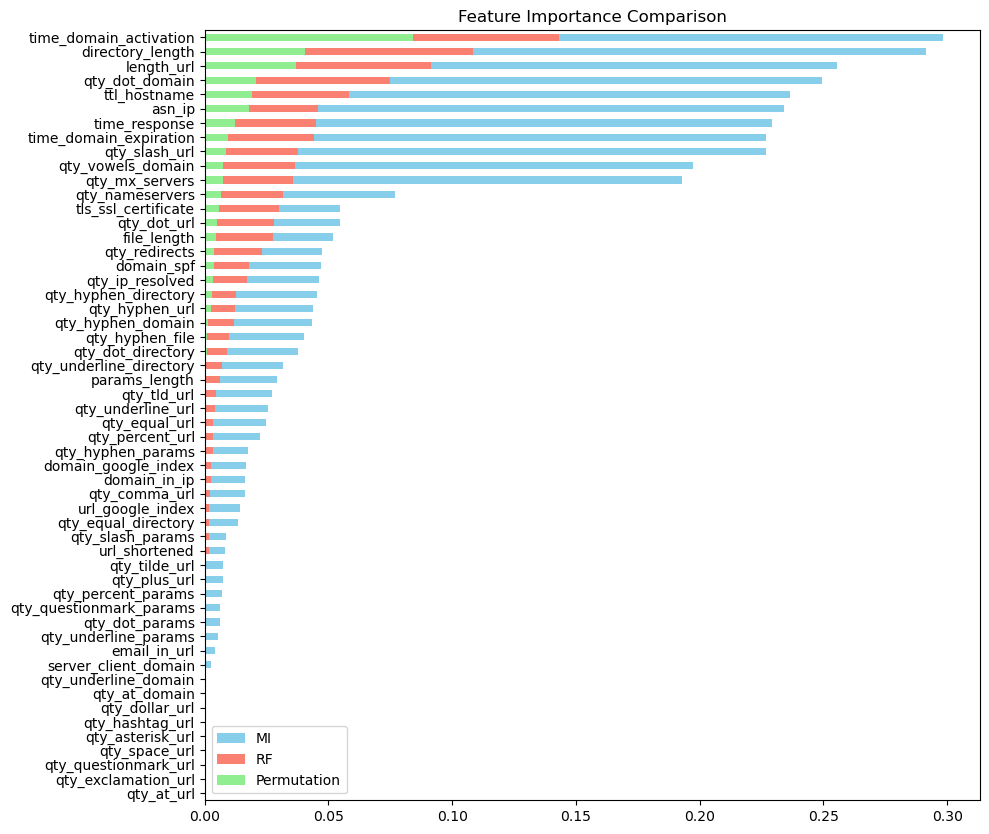

In [25]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 10))
mi_scores.sort_values().plot(kind='barh', color='skyblue', label='MI')
rf_scores.sort_values().plot(kind='barh', color='salmon', label='RF')
perm_scores.sort_values().plot(kind='barh', color='lightgreen', label='Permutation')
plt.legend()
plt.title("Feature Importance Comparison")

## ML

In [26]:
X_train_final = X_train_final.to_numpy()
y_train = y_train.to_numpy().ravel()

### RF

In [ ]:
SEED = 42
np.random.seed(SEED)

rf_model = RandomForestClassifier(n_estimators=100, random_state=SEED)

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)

accuracy_scores, precision_scores, recall_scores = [], [], []
f1_scores, auc_scores, fpr_scores = [], [], []

fold = 1
for train_idx, val_idx in cv.split(X_train_final, y_train):
    X_tr, X_val = X_train_final[train_idx], X_train_final[val_idx]
    y_tr, y_val = y_train[train_idx], y_train[val_idx]

    # Train model
    rf_model.fit(X_tr, y_tr)

    # Predict
    y_pred = rf_model.predict(X_val)
    y_proba = rf_model.predict_proba(X_val)[:, 1]

    # Confusion Matrix
    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()

    # Metrics
    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred)
    rec = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    auc = roc_auc_score(y_val, y_proba)
    fpr = fp / (fp + tn)

    # Store
    accuracy_scores.append(acc)
    precision_scores.append(prec)
    recall_scores.append(rec)
    f1_scores.append(f1)
    auc_scores.append(auc)
    fpr_scores.append(fpr)

    fold += 1

print("\n========== Cross-Validation Results (Random Forest) ==========")
print(f"Accuracy    : {np.mean(accuracy_scores):.4f} ± {np.std(accuracy_scores):.4f}")
print(f"Precision   : {np.mean(precision_scores):.4f} ± {np.std(precision_scores):.4f}")
print(f"Recall (TPR): {np.mean(recall_scores):.4f} ± {np.std(recall_scores):.4f}")
print(f"F1-score    : {np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}")
print(f"FPR         : {np.mean(fpr_scores):.4f} ± {np.std(fpr_scores):.4f}")
print(f"AUC-ROC     : {np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f}")


========== Cross-Validation Results (Random Forest) ==========
Accuracy    : 0.9550 ± 0.0028
Precision   : 0.9532 ± 0.0040
Recall (TPR): 0.9617 ± 0.0050
F1-score    : 0.9574 ± 0.0027
FPR         : 0.0526 ± 0.0048
AUC-ROC     : 0.9906 ± 0.0010


### Fine Tuned Random Forest

In [ ]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)
from joblib import parallel_backend
import numpy as np
from sklearn.metrics import make_scorer, confusion_matrix

def false_positive_rate(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return fp / (fp + tn)

fpr_scorer = make_scorer(false_positive_rate, greater_is_better=False)

# ---------------------------
# Reproducibility
# ---------------------------
SEED = 42
np.random.seed(SEED)

# ============================================================
# 1. Define Base RF and Parameter Grid
# ============================================================
rf_base = RandomForestClassifier(
    random_state=SEED,
    n_jobs=1      # IMPORTANT: avoid nested parallelism when using n_jobs=-1 in GridSearchCV
)

rf_param_grid = {
    'n_estimators': [800],       # drop 1000
    'max_depth': [40],            # drop 80, None
    'max_features': [0.3],       # drop 0.2
    'min_samples_leaf': [1],           # drop 2
    'min_samples_split': [2],          # drop 3
    'bootstrap': [False]               # drop True
}

# ============================================================
# 2. GridSearchCV — Exhaustive Hyperparameter Search
# ============================================================
cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=SEED
)

rf_gsearch = GridSearchCV(
    estimator=rf_base,
    param_grid=rf_param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,        # parallelize the gridsearch
    verbose=2
)

# Fit GridSearchCV
with parallel_backend('threading'):
    rf_gsearch.fit(X_train_final, y_train)

best_rf = rf_gsearch.best_estimator_

print("\nBest Parameters Found:")
for k, v in rf_gsearch.best_params_.items():
    print(f"  {k}: {v}")

# Cross-validate best model
cv_results = cross_validate(
    best_rf,
    X_train_final,
    y_train,
    cv=cv,
    scoring={
        'accuracy': 'accuracy',
        'precision': 'precision',
        'recall': 'recall',
        'f1': 'f1',
        'roc_auc': 'roc_auc',
        'fpr': fpr_scorer
    },
    return_train_score=False,
    n_jobs=1
)

print("\n========== Cross-Validation Results (Tuned Random Forest) ==========")
print(f"Accuracy    : {cv_results['test_accuracy'].mean():.4f} ± {cv_results['test_accuracy'].std():.4f}")
print(f"Precision   : {cv_results['test_precision'].mean():.4f} ± {cv_results['test_precision'].std():.4f}")
print(f"Recall (TPR): {cv_results['test_recall'].mean():.4f} ± {cv_results['test_recall'].std():.4f}")
print(f"F1-score    : {cv_results['test_f1'].mean():.4f} ± {cv_results['test_f1'].std():.4f}")
print(f"FPR         : {cv_results['test_fpr'].mean():.4f} ± {cv_results['test_fpr'].std():.4f}")
print(f"AUC-ROC     : {cv_results['test_roc_auc'].mean():.4f} ± {cv_results['test_roc_auc'].std():.4f}")



Fitting 10 folds for each of 1 candidates, totalling 10 fits
[CV] END bootstrap=False, max_depth=40, max_features=0.3, min_samples_leaf=1, min_samples_split=2, n_estimators=800; total time= 3.3min
[CV] END bootstrap=False, max_depth=40, max_features=0.3, min_samples_leaf=1, min_samples_split=2, n_estimators=800; total time= 3.3min
[CV] END bootstrap=False, max_depth=40, max_features=0.3, min_samples_leaf=1, min_samples_split=2, n_estimators=800; total time= 3.3min
[CV] END bootstrap=False, max_depth=40, max_features=0.3, min_samples_leaf=1, min_samples_split=2, n_estimators=800; total time= 3.3min
[CV] END bootstrap=False, max_depth=40, max_features=0.3, min_samples_leaf=1, min_samples_split=2, n_estimators=800; total time= 3.3min
[CV] END bootstrap=False, max_depth=40, max_features=0.3, min_samples_leaf=1, min_samples_split=2, n_estimators=800; total time= 3.3min
[CV] END bootstrap=False, max_depth=40, max_features=0.3, min_samples_leaf=1, min_samples_split=2, n_estimators=800; total 

### 30 runs (RF)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)

# ======================================================
# CONFIG
# ======================================================
SEEDS = range(30)   # 0 to 29

# Storage for CSV exports
per_seed_records = []

# Final (300-fold) storage
all_accuracy, all_precision, all_recall = [], [], []
all_f1, all_auc, all_fpr = [], [], []

# ======================================================
# RUN 30 SEEDS
# ======================================================
for seed in SEEDS:
    print(f"\n========== SEED {seed} (Random Forest) ==========")

    seed_acc, seed_prec, seed_rec = [], [], []
    seed_f1, seed_auc, seed_fpr = [], [], []

    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=seed)

    for train_idx, val_idx in cv.split(X_train_final, y_train):
        X_tr, X_val = X_train_final[train_idx], X_train_final[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        rf = RandomForestClassifier(
            n_estimators=100,
            random_state=seed
        )
        rf.fit(X_tr, y_tr)

        y_pred = rf.predict(X_val)
        y_proba = rf.predict_proba(X_val)[:, 1]

        tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()

        acc = accuracy_score(y_val, y_pred)
        prec = precision_score(y_val, y_pred)
        rec = recall_score(y_val, y_pred)
        f1 = f1_score(y_val, y_pred)
        auc = roc_auc_score(y_val, y_proba)
        fpr = fp / (fp + tn)

        seed_acc.append(acc)
        seed_prec.append(prec)
        seed_rec.append(rec)
        seed_f1.append(f1)
        seed_auc.append(auc)
        seed_fpr.append(fpr)

    # Per-seed summary
    seed_result = {
        "seed": seed,
        "accuracy_mean": np.mean(seed_acc),
        "precision_mean": np.mean(seed_prec),
        "recall_mean": np.mean(seed_rec),
        "f1_mean": np.mean(seed_f1),
        "fpr_mean": np.mean(seed_fpr),
        "auc_mean": np.mean(seed_auc)
    }

    per_seed_records.append(seed_result)

    # Print per-seed summary
    print(f"Accuracy    : {seed_result['accuracy_mean']:.4f}")
    print(f"Precision   : {seed_result['precision_mean']:.4f}")
    print(f"Recall      : {seed_result['recall_mean']:.4f}")
    print(f"F1-score    : {seed_result['f1_mean']:.4f}")
    print(f"FPR         : {seed_result['fpr_mean']:.4f}")
    print(f"AUC-ROC     : {seed_result['auc_mean']:.4f}")

    # Store all 300-fold results
    all_accuracy.extend(seed_acc)
    all_precision.extend(seed_prec)
    all_recall.extend(seed_rec)
    all_f1.extend(seed_f1)
    all_auc.extend(seed_auc)
    all_fpr.extend(seed_fpr)

# ======================================================
# SAVE CSV 1 — PER-SEED RESULTS
# ======================================================
df_seed = pd.DataFrame(per_seed_records)
df_seed.to_csv("rf_per_seed_results.csv", index=False)
print("\nSaved: rf_per_seed_results.csv")

# ======================================================
# FINAL OVERALL 300-FOLD RESULTS
# ======================================================
final_accuracy_mean = np.mean(all_accuracy)
final_precision_mean = np.mean(all_precision)
final_recall_mean = np.mean(all_recall)
final_f1_mean = np.mean(all_f1)
final_fpr_mean = np.mean(all_fpr)
final_auc_mean = np.mean(all_auc)

final_accuracy_std = np.std(all_accuracy)
final_precision_std = np.std(all_precision)
final_recall_std = np.std(all_recall)
final_f1_std = np.std(all_f1)
final_fpr_std = np.std(all_fpr)
final_auc_std = np.std(all_auc)

print("\n========== FINAL OVERALL RESULTS (300 runs) ==========")
print(f"Accuracy    : {final_accuracy_mean:.4f} ± {final_accuracy_std:.4f}")
print(f"Precision   : {final_precision_mean:.4f} ± {final_precision_std:.4f}")
print(f"Recall      : {final_recall_mean:.4f} ± {final_recall_std:.4f}")
print(f"F1-score    : {final_f1_mean:.4f} ± {final_f1_std:.4f}")
print(f"FPR         : {final_fpr_mean:.4f} ± {final_fpr_std:.4f}")
print(f"AUC-ROC     : {final_auc_mean:.4f} ± {final_auc_std:.4f}")

# ======================================================
# SAVE CSV 2 — FINAL OVERALL RESULTS
# ======================================================
df_final = pd.DataFrame({
    "metric": ["accuracy", "precision", "recall", "f1", "fpr", "auc"],
    "mean": [
        final_accuracy_mean,
        final_precision_mean,
        final_recall_mean,
        final_f1_mean,
        final_fpr_mean,
        final_auc_mean
    ],
    "std": [
        final_accuracy_std,
        final_precision_std,
        final_recall_std,
        final_f1_std,
        final_fpr_std,
        final_auc_std
    ]
})

df_final.to_csv("rf_final_overall_results.csv", index=False)
print("Saved: rf_final_overall_results.csv")



========== SEED 0 (Random Forest) ==========
Accuracy    : 0.9546
Precision   : 0.9530
Recall      : 0.9613
F1-score    : 0.9571
FPR         : 0.0527
AUC-ROC     : 0.9905

========== SEED 1 (Random Forest) ==========
Accuracy    : 0.9544
Precision   : 0.9518
Recall      : 0.9621
F1-score    : 0.9569
FPR         : 0.0542
AUC-ROC     : 0.9904

========== SEED 2 (Random Forest) ==========
Accuracy    : 0.9550
Precision   : 0.9530
Recall      : 0.9621
F1-score    : 0.9575
FPR         : 0.0528
AUC-ROC     : 0.9904

========== SEED 3 (Random Forest) ==========
Accuracy    : 0.9551
Precision   : 0.9530
Recall      : 0.9622
F1-score    : 0.9576
FPR         : 0.0528
AUC-ROC     : 0.9904

========== SEED 4 (Random Forest) ==========
Accuracy    : 0.9552
Precision   : 0.9534
Recall      : 0.9620
F1-score    : 0.9576
FPR         : 0.0524
AUC-ROC     : 0.9904

========== SEED 5 (Random Forest) ==========
Accuracy    : 0.9549
Precision   : 0.9529
Recall      : 0.9618
F1-score    : 0.9573
FPR       

### XGBoost

In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    random_state=SEED,
    use_label_encoder=False,
    eval_metric='logloss',
    verbosity=0,
    n_jobs=-1,
    deterministic_histogram=True
)

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)

accuracy_scores, precision_scores, recall_scores = [], [], []
f1_scores, auc_scores, fpr_scores = [], [], []

fold = 1
for train_idx, val_idx in cv.split(X_train_final, y_train):
    X_tr, X_val = X_train_final[train_idx], X_train_final[val_idx]
    y_tr, y_val = y_train[train_idx], y_train[val_idx]

    # Train model
    xgb_model.fit(X_tr, y_tr)

    # Predict
    y_pred = xgb_model.predict(X_val)
    y_proba = xgb_model.predict_proba(X_val)[:, 1]

    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()

    # Metrics
    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred)
    rec = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    auc = roc_auc_score(y_val, y_proba)
    fpr = fp / (fp + tn)

    # Store metrics
    accuracy_scores.append(acc)
    precision_scores.append(prec)
    recall_scores.append(rec)
    f1_scores.append(f1)
    auc_scores.append(auc)
    fpr_scores.append(fpr)

    fold += 1

print("\n========== Cross-Validation Results (XGBoost) ==========")
print(f"Accuracy    : {np.mean(accuracy_scores):.4f} ± {np.std(accuracy_scores):.4f}")
print(f"Precision   : {np.mean(precision_scores):.4f} ± {np.std(precision_scores):.4f}")
print(f"Recall (TPR): {np.mean(recall_scores):.4f} ± {np.std(recall_scores):.4f}")
print(f"F1-score    : {np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}")
print(f"FPR         : {np.mean(fpr_scores):.4f} ± {np.std(fpr_scores):.4f}")
print(f"AUC-ROC     : {np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f}")


========== Cross-Validation Results (XGBoost) ==========
Accuracy    : 0.9546 ± 0.0025
Precision   : 0.9551 ± 0.0040
Recall (TPR): 0.9588 ± 0.0057
F1-score    : 0.9570 ± 0.0024
FPR         : 0.0501 ± 0.0049
AUC-ROC     : 0.9903 ± 0.0006


### Fine Tuned XGBoost

In [ ]:
# ============================================================
# Tuned XGBoost (GridSearchCV + Full Metrics + FPR)
# ============================================================

import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, make_scorer
)

# ============================================================
# 1. Custom FPR Metric
# ============================================================

def false_positive_rate(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return fp / (fp + tn)

fpr_scorer = make_scorer(false_positive_rate, greater_is_better=False)

# ============================================================
# 2. Reproducibility
# ============================================================

SEED = 42
np.random.seed(SEED)

# ============================================================
# 3. Base XGBoost Model (Clean, no deprecated params)
# ============================================================

xgb_base = XGBClassifier(
    random_state=SEED,
    eval_metric='logloss',
    use_label_encoder=False,
    n_jobs=-1,
    tree_method='hist'
)

# ============================================================
# 4. Parameter Grid
# ============================================================

xg_param_grid = {
    'n_estimators': [1000,1500],
    'max_depth': [6, 8],
    'learning_rate': [0.1],
    'subsample': [0.8],
    'colsample_bytree': [0.8],

    'gamma': [0, 1],
    'min_child_weight': [1, 3],
    'reg_alpha': [0, 1],
    'reg_lambda': [1, 10]
}




# ============================================================
# 5. GridSearchCV
# ============================================================

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)

xg_gsearch = GridSearchCV(
    estimator=xgb_base,
    param_grid=xg_param_grid,
    scoring={
        'accuracy': 'accuracy',
        'f1': 'f1',
        'roc_auc': 'roc_auc',
        'fpr': fpr_scorer
    },
    refit='f1',
    cv=cv,
    n_jobs=-1,
    verbose=2
)

print("\nRunning XGBoost Grid Search...")
xg_gsearch.fit(X_train_final, y_train)

best_xgb = xg_gsearch.best_estimator_

print("\n==================== Best Parameters ====================")
for k, v in xg_gsearch.best_params_.items():
    print(f"{k}: {v}")

# Evaluate with 10-fold CV
accuracy_scores, precision_scores, recall_scores = [], [], []
f1_scores, auc_scores, fpr_scores = [], [], []

for tr_idx, val_idx in cv.split(X_train_final, y_train):
    X_tr, X_val = X_train_final[tr_idx], X_train_final[val_idx]
    y_tr, y_val = y_train[tr_idx], y_train[val_idx]

    # Create fresh XGB instance with best params
    fold_xgb = XGBClassifier(
        **xg_gsearch.best_params_,
        random_state=SEED,
        use_label_encoder=False,
        eval_metric='logloss',
        n_jobs=-1,
        tree_method='hist'
    )
    fold_xgb.fit(X_tr, y_tr)

    y_pred = fold_xgb.predict(X_val)
    y_proba = fold_xgb.predict_proba(X_val)[:, 1]

    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()

    accuracy_scores.append(accuracy_score(y_val, y_pred))
    precision_scores.append(precision_score(y_val, y_pred))
    recall_scores.append(recall_score(y_val, y_pred))
    f1_scores.append(f1_score(y_val, y_pred))
    auc_scores.append(roc_auc_score(y_val, y_proba))
    fpr_scores.append(fp / (fp + tn))

print("\n========== 10-Fold CV Results (Tuned XGBoost) ==========")
print(f"Accuracy    : {np.mean(accuracy_scores):.4f} ± {np.std(accuracy_scores):.4f}")
print(f"Precision   : {np.mean(precision_scores):.4f} ± {np.std(precision_scores):.4f}")
print(f"Recall (TPR): {np.mean(recall_scores):.4f} ± {np.std(recall_scores):.4f}")
print(f"F1-score    : {np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}")
print(f"FPR         : {np.mean(fpr_scores):.4f} ± {np.std(fpr_scores):.4f}")
print(f"AUC-ROC     : {np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f}")



Running XGBoost Grid Search...
Fitting 10 folds for each of 64 candidates, totalling 640 fits

==================== Best Parameters ====================
colsample_bytree: 0.8
gamma: 0
learning_rate: 0.1
max_depth: 6
min_child_weight: 1
n_estimators: 1000
reg_alpha: 0
reg_lambda: 1
subsample: 0.8

========== 10-Fold CV Results (Tuned XGBoost) ==========
Accuracy    : 0.9595 ± 0.0022
Precision   : 0.9600 ± 0.0029
Recall (TPR): 0.9633 ± 0.0032
F1-score    : 0.9616 ± 0.0021
FPR         : 0.0447 ± 0.0034
AUC-ROC     : 0.9918 ± 0.0005


### 30 runs (XGBoost)

In [ ]:
import numpy as np
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)

# ======================================================
# CONFIG
# ======================================================
SEEDS = range(30)  # seeds 0–29

# CSV storage lists
per_seed_records = []

# Final metric storage (all 300 folds)
all_accuracy, all_precision, all_recall = [], [], []
all_f1, all_auc, all_fpr = [], [], []

# ======================================================
# LOOP OVER 30 SEEDS
# ======================================================
for seed in SEEDS:
    print(f"\n========== SEED {seed} (XGBoost) ==========")

    # Per-seed lists
    seed_acc, seed_prec, seed_rec = [], [], []
    seed_f1, seed_auc, seed_fpr = [], [], []

    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=seed)

    for train_idx, val_idx in cv.split(X_train_final, y_train):

        X_tr, X_val = X_train_final[train_idx], X_train_final[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        xgb_model = XGBClassifier(
            random_state=seed,
            use_label_encoder=False,
            eval_metric='logloss',
            verbosity=0,
            n_jobs=-1,
            deterministic_histogram=True
        )

        xgb_model.fit(X_tr, y_tr)

        y_pred = xgb_model.predict(X_val)
        y_proba = xgb_model.predict_proba(X_val)[:, 1]

        tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()

        acc = accuracy_score(y_val, y_pred)
        prec = precision_score(y_val, y_pred)
        rec = recall_score(y_val, y_pred)
        f1 = f1_score(y_val, y_pred)
        auc = roc_auc_score(y_val, y_proba)
        fpr = fp / (fp + tn)

        seed_acc.append(acc)
        seed_prec.append(prec)
        seed_rec.append(rec)
        seed_f1.append(f1)
        seed_auc.append(auc)
        seed_fpr.append(fpr)

    # =============================
    # PRINT PER-SEED RESULT
    # =============================
    print(f"Accuracy    : {np.mean(seed_acc):.4f}")
    print(f"Precision   : {np.mean(seed_prec):.4f}")
    print(f"Recall      : {np.mean(seed_rec):.4f}")
    print(f"F1-score    : {np.mean(seed_f1):.4f}")
    print(f"FPR         : {np.mean(seed_fpr):.4f}")
    print(f"AUC-ROC     : {np.mean(seed_auc):.4f}")

    per_seed_records.append({
        "seed": seed,
        "accuracy_mean": np.mean(seed_acc),
        "precision_mean": np.mean(seed_prec),
        "recall_mean": np.mean(seed_rec),
        "f1_mean": np.mean(seed_f1),
        "fpr_mean": np.mean(seed_fpr),
        "auc_mean": np.mean(seed_auc)
    })

    # Add all 300 folds data
    all_accuracy.extend(seed_acc)
    all_precision.extend(seed_prec)
    all_recall.extend(seed_rec)
    all_f1.extend(seed_f1)
    all_auc.extend(seed_auc)
    all_fpr.extend(seed_fpr)

# ======================================================
# SAVE CSV 1 — PER-SEED RESULTS
# ======================================================
df_seed = pd.DataFrame(per_seed_records)
df_seed.to_csv("xgb_per_seed_results.csv", index=False)
print("\nSaved: xgb_per_seed_results.csv")

# ======================================================
# FINAL OVERALL 300-FOLD RESULTS
# ======================================================
final_accuracy_mean = np.mean(all_accuracy)
final_precision_mean = np.mean(all_precision)
final_recall_mean = np.mean(all_recall)
final_f1_mean = np.mean(all_f1)
final_fpr_mean = np.mean(all_fpr)
final_auc_mean = np.mean(all_auc)

final_accuracy_std = np.std(all_accuracy)
final_precision_std = np.std(all_precision)
final_recall_std = np.std(all_recall)
final_f1_std = np.std(all_f1)
final_fpr_std = np.std(all_fpr)
final_auc_std = np.std(all_auc)

print("\n========== FINAL 30-SEED OVERALL RESULTS (300 runs) ==========")
print(f"Accuracy    : {final_accuracy_mean:.4f} ± {final_accuracy_std:.4f}")
print(f"Precision   : {final_precision_mean:.4f} ± {final_precision_std:.4f}")
print(f"Recall      : {final_recall_mean:.4f} ± {final_recall_std:.4f}")
print(f"F1-score    : {final_f1_mean:.4f} ± {final_f1_std:.4f}")
print(f"FPR         : {final_fpr_mean:.4f} ± {final_fpr_std:.4f}")
print(f"AUC-ROC     : {final_auc_mean:.4f} ± {final_auc_std:.4f}")

# ======================================================
# SAVE CSV 2 — FINAL RESULTS
# ======================================================
df_final = pd.DataFrame({
    "metric": ["accuracy", "precision", "recall", "f1", "fpr", "auc"],
    "mean": [
        final_accuracy_mean,
        final_precision_mean,
        final_recall_mean,
        final_f1_mean,
        final_fpr_mean,
        final_auc_mean
    ],
    "std": [
        final_accuracy_std,
        final_precision_std,
        final_recall_std,
        final_f1_std,
        final_fpr_std,
        final_auc_std
    ]
})

df_final.to_csv("xgb_final_overall_results.csv", index=False)
print("Saved: xgb_final_overall_results.csv")



========== SEED 0 (XGBoost) ==========
Accuracy    : 0.9539
Precision   : 0.9548
Recall      : 0.9579
F1-score    : 0.9563
FPR         : 0.0505
AUC-ROC     : 0.9901

========== SEED 1 (XGBoost) ==========
Accuracy    : 0.9532
Precision   : 0.9541
Recall      : 0.9573
F1-score    : 0.9557
FPR         : 0.0513
AUC-ROC     : 0.9901

========== SEED 2 (XGBoost) ==========
Accuracy    : 0.9541
Precision   : 0.9547
Recall      : 0.9583
F1-score    : 0.9565
FPR         : 0.0506
AUC-ROC     : 0.9901

========== SEED 3 (XGBoost) ==========
Accuracy    : 0.9533
Precision   : 0.9538
Recall      : 0.9576
F1-score    : 0.9557
FPR         : 0.0516
AUC-ROC     : 0.9902

========== SEED 4 (XGBoost) ==========
Accuracy    : 0.9535
Precision   : 0.9539
Recall      : 0.9580
F1-score    : 0.9560
FPR         : 0.0515
AUC-ROC     : 0.9899

========== SEED 5 (XGBoost) ==========
Accuracy    : 0.9536
Precision   : 0.9557
Recall      : 0.9562
F1-score    : 0.9559
FPR         : 0.0493
AUC-ROC     : 0.9899

===

### Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

logreg_model = LogisticRegression(max_iter=1000, random_state=SEED, solver='liblinear')

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)

accuracy_scores, precision_scores, recall_scores = [], [], []
f1_scores, auc_scores, fpr_scores = [], [], []

for train_idx, val_idx in cv.split(X_train_final, y_train):
    X_tr, X_val = X_train_final[train_idx], X_train_final[val_idx]
    y_tr, y_val = y_train[train_idx], y_train[val_idx]

    # Train model
    logreg_model.fit(X_tr, y_tr)

    # Predict
    y_pred = logreg_model.predict(X_val)
    y_proba = logreg_model.predict_proba(X_val)[:, 1]

    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()

    # Metrics
    accuracy_scores.append(accuracy_score(y_val, y_pred))
    precision_scores.append(precision_score(y_val, y_pred))
    recall_scores.append(recall_score(y_val, y_pred))
    f1_scores.append(f1_score(y_val, y_pred))
    auc_scores.append(roc_auc_score(y_val, y_proba))
    fpr_scores.append(fp / (fp + tn))

print("\n========== Cross-Validation Results (Logistic Regression) ==========")
print(f"Accuracy    : {np.mean(accuracy_scores):.4f} ± {np.std(accuracy_scores):.4f}")
print(f"Precision   : {np.mean(precision_scores):.4f} ± {np.std(precision_scores):.4f}")
print(f"Recall (TPR): {np.mean(recall_scores):.4f} ± {np.std(recall_scores):.4f}")
print(f"F1-score    : {np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}")
print(f"FPR         : {np.mean(fpr_scores):.4f} ± {np.std(fpr_scores):.4f}")
print(f"AUC-ROC     : {np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f}")


========== Cross-Validation Results (Logistic Regression) ==========
Accuracy    : 0.8779 ± 0.0035
Precision   : 0.8618 ± 0.0025
Recall (TPR): 0.9148 ± 0.0062
F1-score    : 0.8875 ± 0.0035
FPR         : 0.1631 ± 0.0034
AUC-ROC     : 0.9470 ± 0.0033


### 30 runs (Logistic Regression)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)

# ======================================================
# CONFIG
# ======================================================
SEEDS = range(30)  # seeds 0–29

# Storage for CSV exports
per_seed_records = []

# Final (300-fold) storage
all_accuracy, all_precision, all_recall = [], [], []
all_f1, all_auc, all_fpr = [], [], []

# ======================================================
# LOOP OVER 30 SEEDS
# ======================================================
for seed in SEEDS:
    print(f"\n========== SEED {seed} (Logistic Regression) ==========")

    # Per-seed lists (10 folds)
    seed_acc, seed_prec, seed_rec = [], [], []
    seed_f1, seed_auc, seed_fpr = [], [], []

    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=seed)

    for train_idx, val_idx in cv.split(X_train_final, y_train):

        X_tr, X_val = X_train_final[train_idx], X_train_final[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        logreg_model = LogisticRegression(
            max_iter=1000,
            random_state=seed,
            solver='liblinear'
        )

        logreg_model.fit(X_tr, y_tr)

        y_pred = logreg_model.predict(X_val)
        y_proba = logreg_model.predict_proba(X_val)[:, 1]

        tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()

        acc = accuracy_score(y_val, y_pred)
        prec = precision_score(y_val, y_pred)
        rec = recall_score(y_val, y_pred)
        f1 = f1_score(y_val, y_pred)
        auc = roc_auc_score(y_val, y_proba)
        fpr = fp / (fp + tn)

        seed_acc.append(acc)
        seed_prec.append(prec)
        seed_rec.append(rec)
        seed_f1.append(f1)
        seed_auc.append(auc)
        seed_fpr.append(fpr)

    # =============================
    # PRINT PER-SEED RESULTS
    # =============================
    print(f"Accuracy    : {np.mean(seed_acc):.4f}")
    print(f"Precision   : {np.mean(seed_prec):.4f}")
    print(f"Recall      : {np.mean(seed_rec):.4f}")
    print(f"F1-score    : {np.mean(seed_f1):.4f}")
    print(f"FPR         : {np.mean(seed_fpr):.4f}")
    print(f"AUC-ROC     : {np.mean(seed_auc):.4f}")

    # Store this seed's summary
    per_seed_records.append({
        "seed": seed,
        "accuracy_mean": np.mean(seed_acc),
        "precision_mean": np.mean(seed_prec),
        "recall_mean": np.mean(seed_rec),
        "f1_mean": np.mean(seed_f1),
        "fpr_mean": np.mean(seed_fpr),
        "auc_mean": np.mean(seed_auc)
    })

    # Store all 300-fold results
    all_accuracy.extend(seed_acc)
    all_precision.extend(seed_prec)
    all_recall.extend(seed_rec)
    all_f1.extend(seed_f1)
    all_auc.extend(seed_auc)
    all_fpr.extend(seed_fpr)

# ======================================================
# SAVE CSV 1 — PER-SEED RESULTS
# ======================================================
df_seed = pd.DataFrame(per_seed_records)
df_seed.to_csv("logreg_per_seed_results.csv", index=False)
print("\nSaved: logreg_per_seed_results.csv")

# ======================================================
# FINAL OVERALL RESULTS (300 folds)
# ======================================================
final_accuracy_mean = np.mean(all_accuracy)
final_precision_mean = np.mean(all_precision)
final_recall_mean = np.mean(all_recall)
final_f1_mean = np.mean(all_f1)
final_fpr_mean = np.mean(all_fpr)
final_auc_mean = np.mean(all_auc)

final_accuracy_std = np.std(all_accuracy)
final_precision_std = np.std(all_precision)
final_recall_std = np.std(all_recall)
final_f1_std = np.std(all_f1)
final_fpr_std = np.std(all_fpr)
final_auc_std = np.std(all_auc)

print("\n========== FINAL OVERALL RESULTS (30 Seeds × 10-Fold = 300 runs) ==========")
print(f"Accuracy    : {final_accuracy_mean:.4f} ± {final_accuracy_std:.4f}")
print(f"Precision   : {final_precision_mean:.4f} ± {final_precision_std:.4f}")
print(f"Recall      : {final_recall_mean:.4f} ± {final_recall_std:.4f}")
print(f"F1-score    : {final_f1_mean:.4f} ± {final_f1_std:.4f}")
print(f"FPR         : {final_fpr_mean:.4f} ± {final_fpr_std:.4f}")
print(f"AUC-ROC     : {final_auc_mean:.4f} ± {final_auc_std:.4f}")

# ======================================================
# SAVE CSV 2 — FINAL OVERALL RESULTS
# ======================================================
df_final = pd.DataFrame({
    "metric": ["accuracy", "precision", "recall", "f1", "fpr", "auc"],
    "mean": [
        final_accuracy_mean,
        final_precision_mean,
        final_recall_mean,
        final_f1_mean,
        final_fpr_mean,
        final_auc_mean
    ],
    "std": [
        final_accuracy_std,
        final_precision_std,
        final_recall_std,
        final_f1_std,
        final_fpr_std,
        final_auc_std
    ]
})

df_final.to_csv("logreg_final_overall_results.csv", index=False)
print("Saved: logreg_final_overall_results.csv")



========== SEED 0 (Logistic Regression) ==========
Accuracy    : 0.8776
Precision   : 0.8617
Recall      : 0.9142
F1-score    : 0.8872
FPR         : 0.1632
AUC-ROC     : 0.9470

========== SEED 1 (Logistic Regression) ==========
Accuracy    : 0.8775
Precision   : 0.8615
Recall      : 0.9144
F1-score    : 0.8871
FPR         : 0.1636
AUC-ROC     : 0.9471

========== SEED 2 (Logistic Regression) ==========
Accuracy    : 0.8774
Precision   : 0.8617
Recall      : 0.9140
F1-score    : 0.8871
FPR         : 0.1633
AUC-ROC     : 0.9470

========== SEED 3 (Logistic Regression) ==========
Accuracy    : 0.8777
Precision   : 0.8619
Recall      : 0.9143
F1-score    : 0.8873
FPR         : 0.1631
AUC-ROC     : 0.9470

========== SEED 4 (Logistic Regression) ==========
Accuracy    : 0.8774
Precision   : 0.8618
Recall      : 0.9140
F1-score    : 0.8871
FPR         : 0.1632
AUC-ROC     : 0.9470

========== SEED 5 (Logistic Regression) ==========
Accuracy    : 0.8773
Precision   : 0.8614
Recall      : 0.

### KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5, weights='uniform', metric='euclidean')

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)

accuracy_scores, precision_scores, recall_scores = [], [], []
f1_scores, auc_scores, fpr_scores = [], [], []

for train_idx, val_idx in cv.split(X_train_final, y_train):
    X_tr, X_val = X_train_final[train_idx], X_train_final[val_idx]
    y_tr, y_val = y_train[train_idx], y_train[val_idx]

    # Train model
    knn_model.fit(X_tr, y_tr)

    # Predict
    y_pred = knn_model.predict(X_val)
    y_proba = knn_model.predict_proba(X_val)[:, 1]

    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()

    # Metrics
    accuracy_scores.append(accuracy_score(y_val, y_pred))
    precision_scores.append(precision_score(y_val, y_pred))
    recall_scores.append(recall_score(y_val, y_pred))
    f1_scores.append(f1_score(y_val, y_pred))
    auc_scores.append(roc_auc_score(y_val, y_proba))
    fpr_scores.append(fp / (fp + tn))

print("\n========== Cross-Validation Results (KNN) ==========")
print(f"Accuracy    : {np.mean(accuracy_scores):.4f} ± {np.std(accuracy_scores):.4f}")
print(f"Precision   : {np.mean(precision_scores):.4f} ± {np.std(precision_scores):.4f}")
print(f"Recall (TPR): {np.mean(recall_scores):.4f} ± {np.std(recall_scores):.4f}")
print(f"F1-score    : {np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}")
print(f"FPR         : {np.mean(fpr_scores):.4f} ± {np.std(fpr_scores):.4f}")
print(f"AUC-ROC     : {np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f}")

c:\Users\ziyan\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\ziyan\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\ziyan\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\ziyan\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\ziyan\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreatePro


========== Cross-Validation Results (KNN) ==========
Accuracy    : 0.9233 ± 0.0038
Precision   : 0.9261 ± 0.0030
Recall (TPR): 0.9284 ± 0.0070
F1-score    : 0.9272 ± 0.0038
FPR         : 0.0824 ± 0.0037
AUC-ROC     : 0.9693 ± 0.0028


### 30 runs (KNN)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)

# ======================================================
# CONFIG
# ======================================================
SEEDS = range(30)  # seeds 0–29

# Storage for CSV exports
per_seed_records = []

# Final (300-fold) storage
all_accuracy, all_precision, all_recall = [], [], []
all_f1, all_auc, all_fpr = [], [], []

# ======================================================
# LOOP OVER 30 SEEDS
# ======================================================
for seed in SEEDS:
    print(f"\n========== SEED {seed} (Logistic Regression) ==========")

    # Per-seed lists (10 folds)
    seed_acc, seed_prec, seed_rec = [], [], []
    seed_f1, seed_auc, seed_fpr = [], [], []

    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=seed)

    for train_idx, val_idx in cv.split(X_train_final, y_train):

        X_tr, X_val = X_train_final[train_idx], X_train_final[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        logreg_model = LogisticRegression(
            max_iter=1000,
            random_state=seed,
            solver='liblinear'
        )

        logreg_model.fit(X_tr, y_tr)

        y_pred = logreg_model.predict(X_val)
        y_proba = logreg_model.predict_proba(X_val)[:, 1]

        tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()

        acc = accuracy_score(y_val, y_pred)
        prec = precision_score(y_val, y_pred)
        rec = recall_score(y_val, y_pred)
        f1 = f1_score(y_val, y_pred)
        auc = roc_auc_score(y_val, y_proba)
        fpr = fp / (fp + tn)

        seed_acc.append(acc)
        seed_prec.append(prec)
        seed_rec.append(rec)
        seed_f1.append(f1)
        seed_auc.append(auc)
        seed_fpr.append(fpr)

    # =============================
    # PRINT PER-SEED RESULTS
    # =============================
    print(f"Accuracy    : {np.mean(seed_acc):.4f}")
    print(f"Precision   : {np.mean(seed_prec):.4f}")
    print(f"Recall      : {np.mean(seed_rec):.4f}")
    print(f"F1-score    : {np.mean(seed_f1):.4f}")
    print(f"FPR         : {np.mean(seed_fpr):.4f}")
    print(f"AUC-ROC     : {np.mean(seed_auc):.4f}")

    # Store this seed's summary
    per_seed_records.append({
        "seed": seed,
        "accuracy_mean": np.mean(seed_acc),
        "precision_mean": np.mean(seed_prec),
        "recall_mean": np.mean(seed_rec),
        "f1_mean": np.mean(seed_f1),
        "fpr_mean": np.mean(seed_fpr),
        "auc_mean": np.mean(seed_auc)
    })

    # Store all 300-fold results
    all_accuracy.extend(seed_acc)
    all_precision.extend(seed_prec)
    all_recall.extend(seed_rec)
    all_f1.extend(seed_f1)
    all_auc.extend(seed_auc)
    all_fpr.extend(seed_fpr)

# ======================================================
# SAVE CSV 1 — PER-SEED RESULTS
# ======================================================
df_seed = pd.DataFrame(per_seed_records)
df_seed.to_csv("logreg_per_seed_results.csv", index=False)
print("\nSaved: logreg_per_seed_results.csv")

# ======================================================
# FINAL OVERALL RESULTS (300 folds)
# ======================================================
final_accuracy_mean = np.mean(all_accuracy)
final_precision_mean = np.mean(all_precision)
final_recall_mean = np.mean(all_recall)
final_f1_mean = np.mean(all_f1)
final_fpr_mean = np.mean(all_fpr)
final_auc_mean = np.mean(all_auc)

final_accuracy_std = np.std(all_accuracy)
final_precision_std = np.std(all_precision)
final_recall_std = np.std(all_recall)
final_f1_std = np.std(all_f1)
final_fpr_std = np.std(all_fpr)
final_auc_std = np.std(all_auc)

print("\n========== FINAL OVERALL RESULTS (30 Seeds × 10-Fold = 300 runs) ==========")
print(f"Accuracy    : {final_accuracy_mean:.4f} ± {final_accuracy_std:.4f}")
print(f"Precision   : {final_precision_mean:.4f} ± {final_precision_std:.4f}")
print(f"Recall      : {final_recall_mean:.4f} ± {final_recall_std:.4f}")
print(f"F1-score    : {final_f1_mean:.4f} ± {final_f1_std:.4f}")
print(f"FPR         : {final_fpr_mean:.4f} ± {final_fpr_std:.4f}")
print(f"AUC-ROC     : {final_auc_mean:.4f} ± {final_auc_std:.4f}")

# ======================================================
# SAVE CSV 2 — FINAL OVERALL RESULTS
# ======================================================
df_final = pd.DataFrame({
    "metric": ["accuracy", "precision", "recall", "f1", "fpr", "auc"],
    "mean": [
        final_accuracy_mean,
        final_precision_mean,
        final_recall_mean,
        final_f1_mean,
        final_fpr_mean,
        final_auc_mean
    ],
    "std": [
        final_accuracy_std,
        final_precision_std,
        final_recall_std,
        final_f1_std,
        final_fpr_std,
        final_auc_std
    ]
})

df_final.to_csv("logreg_final_overall_results.csv", index=False)
print("Saved: logreg_final_overall_results.csv")


========== SEED 0 (Logistic Regression) ==========
Accuracy    : 0.8776
Precision   : 0.8617
Recall      : 0.9142
F1-score    : 0.8872
FPR         : 0.1632
AUC-ROC     : 0.9470

========== SEED 1 (Logistic Regression) ==========
Accuracy    : 0.8775
Precision   : 0.8615
Recall      : 0.9144
F1-score    : 0.8871
FPR         : 0.1636
AUC-ROC     : 0.9471

========== SEED 2 (Logistic Regression) ==========
Accuracy    : 0.8774
Precision   : 0.8617
Recall      : 0.9140
F1-score    : 0.8871
FPR         : 0.1633
AUC-ROC     : 0.9470

========== SEED 3 (Logistic Regression) ==========
Accuracy    : 0.8777
Precision   : 0.8619
Recall      : 0.9143
F1-score    : 0.8873
FPR         : 0.1631
AUC-ROC     : 0.9470

========== SEED 4 (Logistic Regression) ==========
Accuracy    : 0.8774
Precision   : 0.8618
Recall      : 0.9140
F1-score    : 0.8871
FPR         : 0.1632
AUC-ROC     : 0.9470

========== SEED 5 (Logistic Regression) ==========
Accuracy    : 0.8773
Precision   : 0.8614
Recall      : 0.

### SVM

In [ ]:
from sklearn.svm import SVC

svm_model = SVC(kernel='rbf', probability=True, random_state=SEED)

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)

accuracy_scores, precision_scores, recall_scores = [], [], []
f1_scores, auc_scores, fpr_scores = [], [], []

for train_idx, val_idx in cv.split(X_train_final, y_train):
    X_tr, X_val = X_train_final[train_idx], X_train_final[val_idx]
    y_tr, y_val = y_train[train_idx], y_train[val_idx]

    # Train model
    svm_model.fit(X_tr, y_tr)

    # Predict
    y_pred = svm_model.predict(X_val)
    y_proba = svm_model.predict_proba(X_val)[:, 1]

    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()

    # Metrics
    accuracy_scores.append(accuracy_score(y_val, y_pred))
    precision_scores.append(precision_score(y_val, y_pred))
    recall_scores.append(recall_score(y_val, y_pred))
    f1_scores.append(f1_score(y_val, y_pred))
    auc_scores.append(roc_auc_score(y_val, y_proba))
    fpr_scores.append(fp / (fp + tn))

print("\n========== Cross-Validation Results (SVM) ==========")
print(f"Accuracy    : {np.mean(accuracy_scores):.4f} ± {np.std(accuracy_scores):.4f}")
print(f"Precision   : {np.mean(precision_scores):.4f} ± {np.std(precision_scores):.4f}")
print(f"Recall (TPR): {np.mean(recall_scores):.4f} ± {np.std(recall_scores):.4f}")
print(f"F1-score    : {np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}")
print(f"FPR         : {np.mean(fpr_scores):.4f} ± {np.std(fpr_scores):.4f}")
print(f"AUC-ROC     : {np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f}")


========== Cross-Validation Results (SVM) ==========
Accuracy    : 0.8965 ± 0.0033
Precision   : 0.8822 ± 0.0028
Recall (TPR): 0.9273 ± 0.0050
F1-score    : 0.9042 ± 0.0032
FPR         : 0.1377 ± 0.0036
AUC-ROC     : 0.9640 ± 0.0024


### 30 runs (SVM)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)

# ======================================================
# CONFIG
# ======================================================
SEEDS = range(30)

per_seed_records = []

all_accuracy, all_precision, all_recall = [], [], []
all_f1, all_auc, all_fpr = [], [], []


# ======================================================
# LOOP OVER 30 SEEDS
# ======================================================
for seed in SEEDS:
    print(f"\n========== SEED {seed} (LinearSVC) ==========")

    seed_acc, seed_prec, seed_rec = [], [], []
    seed_f1, seed_auc, seed_fpr = [], [], []

    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=seed)

    for train_idx, val_idx in cv.split(X_train_final, y_train):

        X_tr, X_val = X_train_final[train_idx], X_train_final[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        # --------------------------------------------------
        # Linear SVM + Probability Calibration
        # --------------------------------------------------
        base_svm = LinearSVC(random_state=seed)
        svm_model = CalibratedClassifierCV(base_svm, cv=3)
        svm_model.fit(X_tr, y_tr)

        y_pred = svm_model.predict(X_val)
        y_proba = svm_model.predict_proba(X_val)[:, 1]

        tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()
        fpr = fp / (fp + tn)

        seed_acc.append(accuracy_score(y_val, y_pred))
        seed_prec.append(precision_score(y_val, y_pred))
        seed_rec.append(recall_score(y_val, y_pred))
        seed_f1.append(f1_score(y_val, y_pred))
        seed_auc.append(roc_auc_score(y_val, y_proba))
        seed_fpr.append(fpr)

    # =============================
    # PRINT PER-SEED RESULTS
    # =============================
    print(f"Accuracy    : {np.mean(seed_acc):.4f}")
    print(f"Precision   : {np.mean(seed_prec):.4f}")
    print(f"Recall      : {np.mean(seed_rec):.4f}")
    print(f"F1-score    : {np.mean(seed_f1):.4f}")
    print(f"FPR         : {np.mean(seed_fpr):.4f}")
    print(f"AUC-ROC     : {np.mean(seed_auc):.4f}")

    per_seed_records.append({
        "seed": seed,
        "accuracy_mean": np.mean(seed_acc),
        "precision_mean": np.mean(seed_prec),
        "recall_mean": np.mean(seed_rec),
        "f1_mean": np.mean(seed_f1),
        "fpr_mean": np.mean(seed_fpr),
        "auc_mean": np.mean(seed_auc)
    })

    all_accuracy.extend(seed_acc)
    all_precision.extend(seed_prec)
    all_recall.extend(seed_rec)
    all_f1.extend(seed_f1)
    all_auc.extend(seed_auc)
    all_fpr.extend(seed_fpr)


# ======================================================
# SAVE CSV 1 — PER-SEED RESULTS
# ======================================================
df_seed = pd.DataFrame(per_seed_records)
df_seed.to_csv("linear_svm_per_seed_results.csv", index=False)
print("\nSaved: linear_svm_per_seed_results.csv")


# ======================================================
# FINAL OVERALL RESULTS (mean ± std)
# ======================================================
def mean_std(arr):
    return np.mean(arr), np.std(arr)

final_accuracy_mean, final_accuracy_std = mean_std(all_accuracy)
final_precision_mean, final_precision_std = mean_std(all_precision)
final_recall_mean, final_recall_std = mean_std(all_recall)
final_f1_mean, final_f1_std = mean_std(all_f1)
final_fpr_mean, final_fpr_std = mean_std(all_fpr)
final_auc_mean, final_auc_std = mean_std(all_auc)

print("\n========== FINAL OVERALL RESULTS (300 runs) ==========")
print(f"Accuracy    : {final_accuracy_mean:.4f} ± {final_accuracy_std:.4f}")
print(f"Precision   : {final_precision_mean:.4f} ± {final_precision_std:.4f}")
print(f"Recall      : {final_recall_mean:.4f} ± {final_recall_std:.4f}")
print(f"F1-score    : {final_f1_mean:.4f} ± {final_f1_std:.4f}")
print(f"FPR         : {final_fpr_mean:.4f} ± {final_fpr_std:.4f}")
print(f"AUC-ROC     : {final_auc_mean:.4f} ± {final_auc_std:.4f}")


# ======================================================
# SAVE CSV 2 — FINAL SUMMARY
# ======================================================
df_final = pd.DataFrame({
    "metric": ["accuracy", "precision", "recall", "f1", "fpr", "auc"],
    "mean": [
        final_accuracy_mean,
        final_precision_mean,
        final_recall_mean,
        final_f1_mean,
        final_fpr_mean,
        final_auc_mean
    ],
    "std": [
        final_accuracy_std,
        final_precision_std,
        final_recall_std,
        final_f1_std,
        final_fpr_std,
        final_auc_std
    ]
})

df_final.to_csv("linear_svm_final_overall_results.csv", index=False)
print("Saved: linear_svm_final_overall_results.csv")



========== SEED 0 (LinearSVC) ==========
Accuracy    : 0.8800
Precision   : 0.8683
Recall      : 0.9101
F1-score    : 0.8887
FPR         : 0.1536
AUC-ROC     : 0.9496

========== SEED 1 (LinearSVC) ==========
Accuracy    : 0.8801
Precision   : 0.8683
Recall      : 0.9105
F1-score    : 0.8889
FPR         : 0.1537
AUC-ROC     : 0.9496

========== SEED 2 (LinearSVC) ==========
Accuracy    : 0.8800
Precision   : 0.8684
Recall      : 0.9101
F1-score    : 0.8888
FPR         : 0.1534
AUC-ROC     : 0.9496

========== SEED 3 (LinearSVC) ==========
Accuracy    : 0.8804
Precision   : 0.8689
Recall      : 0.9103
F1-score    : 0.8891
FPR         : 0.1529
AUC-ROC     : 0.9496

========== SEED 4 (LinearSVC) ==========
Accuracy    : 0.8800
Precision   : 0.8682
Recall      : 0.9104
F1-score    : 0.8888
FPR         : 0.1539
AUC-ROC     : 0.9495

========== SEED 5 (LinearSVC) ==========
Accuracy    : 0.8803
Precision   : 0.8686
Recall      : 0.9104
F1-score    : 0.8890
FPR         : 0.1532
AUC-ROC     :

### LightGBM

In [ ]:
from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(random_state=SEED)

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)

accuracy_scores, precision_scores, recall_scores = [], [], []
f1_scores, auc_scores, fpr_scores = [], [], []

for train_idx, val_idx in cv.split(X_train_final, y_train):
    X_tr, X_val = X_train_final[train_idx], X_train_final[val_idx]
    y_tr, y_val = y_train[train_idx], y_train[val_idx]

    # Train model
    lgbm_model.fit(X_tr, y_tr)

    # Predict
    y_pred = lgbm_model.predict(X_val)
    y_proba = lgbm_model.predict_proba(X_val)[:, 1]

    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()

    # Metrics
    accuracy_scores.append(accuracy_score(y_val, y_pred))
    precision_scores.append(precision_score(y_val, y_pred))
    recall_scores.append(recall_score(y_val, y_pred))
    f1_scores.append(f1_score(y_val, y_pred))
    auc_scores.append(roc_auc_score(y_val, y_proba))
    fpr_scores.append(fp / (fp + tn))

print("\n========== Cross-Validation Results (LightGBM) ==========")
print(f"Accuracy    : {np.mean(accuracy_scores):.4f} ± {np.std(accuracy_scores):.4f}")
print(f"Precision   : {np.mean(precision_scores):.4f} ± {np.std(precision_scores):.4f}")
print(f"Recall (TPR): {np.mean(recall_scores):.4f} ± {np.std(recall_scores):.4f}")
print(f"F1-score    : {np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}")
print(f"FPR         : {np.mean(fpr_scores):.4f} ± {np.std(fpr_scores):.4f}")
print(f"AUC-ROC     : {np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f}")

[LightGBM] [Info] Number of positive: 21549, number of negative: 19368
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003149 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2323
[LightGBM] [Info] Number of data points in the train set: 40917, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.526652 -> initscore=0.106707
[LightGBM] [Info] Start training from score 0.106707


c:\Users\ziyan\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\ziyan\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 21548, number of negative: 19369
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005943 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2324
[LightGBM] [Info] Number of data points in the train set: 40917, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.526627 -> initscore=0.106609
[LightGBM] [Info] Start training from score 0.106609


c:\Users\ziyan\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\ziyan\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 21548, number of negative: 19369
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006349 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2321
[LightGBM] [Info] Number of data points in the train set: 40917, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.526627 -> initscore=0.106609
[LightGBM] [Info] Start training from score 0.106609


...

c:\Users\ziyan\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\ziyan\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 21549, number of negative: 19369
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002515 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2318
[LightGBM] [Info] Number of data points in the train set: 40918, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.526639 -> initscore=0.106656
[LightGBM] [Info] Start training from score 0.106656


c:\Users\ziyan\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\ziyan\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 21549, number of negative: 19369
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005391 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2320
[LightGBM] [Info] Number of data points in the train set: 40918, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.526639 -> initscore=0.106656
[LightGBM] [Info] Start training from score 0.106656

========== Cross-Validation Results (LightGBM) ==========
Accuracy    : 0.9486 ± 0.0023
Precision   : 0.9493 ± 0.0042
Recall (TPR): 0.9534 ± 0.0058
F1-score    : 0.9513 ± 0.0023
FPR         : 0.0567 ± 0.0052
AUC-ROC     : 0.9885 ± 0.0009


c:\Users\ziyan\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\ziyan\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


### 30 runs (LightGBM)

In [ ]:
import numpy as np
import pandas as pd
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)

# ======================================================
# CONFIG
# ======================================================
SEEDS = range(30)  # 0–29

# Storage for CSV export
per_seed_records = []

# Storage for final combined results (300 folds)
all_accuracy, all_precision, all_recall = [], [], []
all_f1, all_auc, all_fpr = [], [], []

# ======================================================
# RUN 30 SEEDS
# ======================================================
for seed in SEEDS:
    print(f"\n========== SEED {seed} (LightGBM) ==========")

    seed_acc, seed_prec, seed_rec = [], [], []
    seed_f1, seed_auc, seed_fpr = [], [], []

    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=seed)

    for train_idx, val_idx in cv.split(X_train_final, y_train):

        X_tr, X_val = X_train_final[train_idx], X_train_final[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        lgbm_model = LGBMClassifier(
            random_state=seed
        )

        lgbm_model.fit(X_tr, y_tr)

        y_pred = lgbm_model.predict(X_val)
        y_proba = lgbm_model.predict_proba(X_val)[:, 1]

        tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()

        acc = accuracy_score(y_val, y_pred)
        prec = precision_score(y_val, y_pred)
        rec = recall_score(y_val, y_pred)
        f1 = f1_score(y_val, y_pred)
        auc = roc_auc_score(y_val, y_proba)
        fpr = fp / (fp + tn)

        seed_acc.append(acc)
        seed_prec.append(prec)
        seed_rec.append(rec)
        seed_f1.append(f1)
        seed_auc.append(auc)
        seed_fpr.append(fpr)

    # ============================
    # PRINT PER-SEED RESULT
    # ============================
    print(f"Accuracy    : {np.mean(seed_acc):.4f}")
    print(f"Precision   : {np.mean(seed_prec):.4f}")
    print(f"Recall      : {np.mean(seed_rec):.4f}")
    print(f"F1-score    : {np.mean(seed_f1):.4f}")
    print(f"FPR         : {np.mean(seed_fpr):.4f}")
    print(f"AUC-ROC     : {np.mean(seed_auc):.4f}")

    per_seed_records.append({
        "seed": seed,
        "accuracy_mean": np.mean(seed_acc),
        "precision_mean": np.mean(seed_prec),
        "recall_mean": np.mean(seed_rec),
        "f1_mean": np.mean(seed_f1),
        "fpr_mean": np.mean(seed_fpr),
        "auc_mean": np.mean(seed_auc)
    })

    # Add all 300-fold values
    all_accuracy.extend(seed_acc)
    all_precision.extend(seed_prec)
    all_recall.extend(seed_rec)
    all_f1.extend(seed_f1)
    all_auc.extend(seed_auc)
    all_fpr.extend(seed_fpr)

# ======================================================
# SAVE CSV 1 — PER-SEED RESULTS
# ======================================================
df_seed = pd.DataFrame(per_seed_records)
df_seed.to_csv("lgbm_per_seed_results.csv", index=False)
print("\nSaved: lgbm_per_seed_results.csv")

# ======================================================
# FINAL OVERALL RESULTS (300 evaluations)
# ======================================================
final_accuracy_mean = np.mean(all_accuracy)
final_precision_mean = np.mean(all_precision)
final_recall_mean = np.mean(all_recall)
final_f1_mean = np.mean(all_f1)
final_fpr_mean = np.mean(all_fpr)
final_auc_mean = np.mean(all_auc)

final_accuracy_std = np.std(all_accuracy)
final_precision_std = np.std(all_precision)
final_recall_std = np.std(all_recall)
final_f1_std = np.std(all_f1)
final_fpr_std = np.std(all_fpr)
final_auc_std = np.std(all_auc)

print("\n========== FINAL OVERALL RESULTS (30 Seeds × 10-Fold = 300 runs) ==========")
print(f"Accuracy    : {final_accuracy_mean:.4f} ± {final_accuracy_std:.4f}")
print(f"Precision   : {final_precision_mean:.4f} ± {final_precision_std:.4f}")
print(f"Recall      : {final_recall_mean:.4f} ± {final_recall_std:.4f}")
print(f"F1-score    : {final_f1_mean:.4f} ± {final_f1_std:.4f}")
print(f"FPR         : {final_fpr_mean:.4f} ± {final_fpr_std:.4f}")
print(f"AUC-ROC     : {final_auc_mean:.4f} ± {final_auc_std:.4f}")

# ======================================================
# SAVE CSV 2 — FINAL OVERALL RESULTS
# ======================================================
df_final = pd.DataFrame({
    "metric": ["accuracy", "precision", "recall", "f1", "fpr", "auc"],
    "mean": [
        final_accuracy_mean,
        final_precision_mean,
        final_recall_mean,
        final_f1_mean,
        final_fpr_mean,
        final_auc_mean
    ],
    "std": [
        final_accuracy_std,
        final_precision_std,
        final_recall_std,
        final_f1_std,
        final_fpr_std,
        final_auc_std
    ]
})

df_final.to_csv("lgbm_final_overall_results.csv", index=False)
print("Saved: lgbm_final_overall_results.csv")



========== SEED 0 (LightGBM) ==========


  File "c:\Users\ziyan\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\ziyan\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\ziyan\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\ziyan\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


[LightGBM] [Info] Number of positive: 21549, number of negative: 19368
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.051582 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2319
[LightGBM] [Info] Number of data points in the train set: 40917, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.526652 -> initscore=0.106707
[LightGBM] [Info] Start training from score 0.106707
[LightGBM] [Info] Number of positive: 21548, number of negative: 19369
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017188 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2322
[LightGBM] [Info] Number of data points in the train set: 40917, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.526627 -> initscore=0.106609
[Ligh

# DL

### CNN

In [ ]:
import os, random, time
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Input, Model, backend as K
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, roc_curve)
from tqdm import tqdm

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"
os.environ["TF_CUDNN_DETERMINISTIC"] = "1"

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

for g in tf.config.list_physical_devices('GPU'):
    try: tf.config.experimental.set_memory_growth(g, True)
    except: pass

X_train_scaled = np.asarray(X_train_final.values if hasattr(X_train_final, "values") else X_train_final, dtype=np.float32)
X_test_scaled  = np.asarray(X_test_final.values  if hasattr(X_test_final, "values") else X_test_final, dtype=np.float32)
y_train_array  = np.asarray(y_train.values if hasattr(y_train, "values") else y_train, dtype=np.int32)
y_test_array   = np.asarray(y_test.values  if hasattr(y_test, "values") else y_test, dtype=np.int32)

print("Train shape:", X_train_scaled.shape)
print("Test shape :", X_test_scaled.shape)

input_dim = int(X_train_scaled.shape[1])

X_train_cnn = X_train_scaled.reshape(-1, input_dim, 1)
X_test_cnn  = X_test_scaled.reshape(-1, input_dim, 1)

# CNN Builder
def build_improved_cnn(input_dim, learning_rate=0.001):
    K.clear_session()
    inp = Input(shape=(input_dim, 1))

    # Block 1
    x = layers.Conv1D(64, 3, padding='same', activation='relu')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(64, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Dropout(0.3)(x)

    # Block 2
    x = layers.Conv1D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling1D()(x)

    # Dense Head
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(1, activation='sigmoid')(x)

    model = Model(inp, out)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                  loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Metrics helper
def metrics_from_preds(y_true, y_pred, y_prob):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    fpr  = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    auc  = roc_auc_score(y_true, y_prob)
    return acc, prec, rec, f1, fpr, auc

# 10-Fold Cross-Validation
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)

acc_list, prec_list, recall_list, f1_list, fpr_list, auc_list = [], [], [], [], [], []
roc_fprs, roc_tprs = [], []

print("\n===== 10-Fold Cross-Validation =====")
for fold, (train_idx, val_idx) in enumerate(tqdm(skf.split(X_train_scaled, y_train_array), total=10)):
    X_tr, X_val = X_train_cnn[train_idx], X_train_cnn[val_idx]
    y_tr, y_val = y_train_array[train_idx], y_train_array[val_idx]

    model = build_improved_cnn(input_dim=input_dim)

    callbacks = [
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=0),
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=0)
    ]

    model.fit(X_tr, y_tr, epochs=50, batch_size=32, verbose=0,
              validation_data=(X_val, y_val), callbacks=callbacks)

    start_time = time.time()
    y_prob = model.predict(X_val, verbose=0).flatten()
    y_pred = (y_prob >= 0.5).astype(int)
    end_time = time.time()

    acc, prec, rec, f1, fpr, auc = metrics_from_preds(y_val, y_pred, y_prob)
    acc_list.append(acc); prec_list.append(prec); recall_list.append(rec)
    f1_list.append(f1); fpr_list.append(fpr); auc_list.append(auc)

    fpr_c, tpr_c, _ = roc_curve(y_val, y_prob)
    roc_fprs.append(fpr_c); roc_tprs.append(tpr_c)

# CV summary
print("\n===== Cross-Validation Results =====")
print(f"Accuracy : {np.mean(acc_list):.4f} ± {np.std(acc_list):.4f}")
print(f"Precision: {np.mean(prec_list):.4f} ± {np.std(prec_list):.4f}")
print(f"Recall   : {np.mean(recall_list):.4f} ± {np.std(recall_list):.4f}")
print(f"F1-score : {np.mean(f1_list):.4f} ± {np.std(f1_list):.4f}")
print(f"FPR      : {np.mean(fpr_list):.4f} ± {np.std(fpr_list):.4f}")
print(f"AUC-ROC  : {np.mean(auc_list):.4f} ± {np.std(auc_list):.4f}")



Train shape: (45464, 30)
Test shape : (11481, 30)

===== 10-Fold Cross-Validation =====


  0%|          | 0/10 [00:00<?, ?it/s]

100%|██████████| 10/10 [48:10<00:00, 289.05s/it]


===== Cross-Validation Results =====
Accuracy : 0.9435 ± 0.0033
Precision: 0.9453 ± 0.0036
Recall   : 0.9476 ± 0.0082
F1-score : 0.9464 ± 0.0034
FPR      : 0.0611 ± 0.0046
AUC-ROC  : 0.9856 ± 0.0016


Epoch 1/50
1279/1279 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8698 - loss: 0.3056 - val_accuracy: 0.8984 - val_loss: 0.2436 - learning_rate: 0.0010
Epoch 2/50
1279/1279 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.8977 - loss: 0.2463 - val_accuracy: 0.9090 - val_loss: 0.2245 - learning_rate: 0.0010
Epoch 3/50
1279/1279 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.9088 - loss: 0.2253 - val_accuracy: 0.9151 - val_loss: 0.2093 - learning_rate: 0.0010
Epoch 4/50
1279/1279 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.9132 - loss: 0.2145 - val_accuracy: 0.9197 - val_loss: 0.2021 - learning_rate: 0.0010
Epoch 5/50
1279/1279 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9177 - loss: 0.2053 - val_accuracy: 0.9279 - val_loss: 0.1919 - learning_rate: 0.0010
Epoch 6/50
1279/1279 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.9225 - loss: 0.1956 - val_accuracy: 0.9241 - val_loss: 0.1927 - learning_rate: 0.0010
Epoch 7/50
1279/1279 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.9255 -

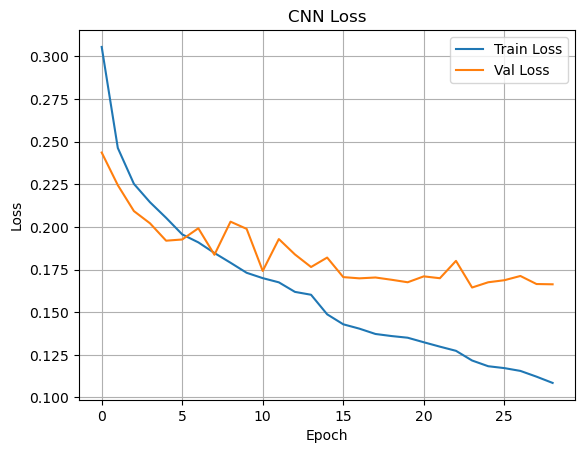

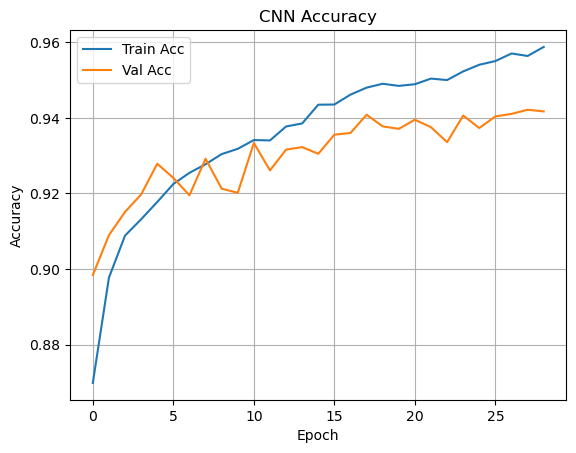

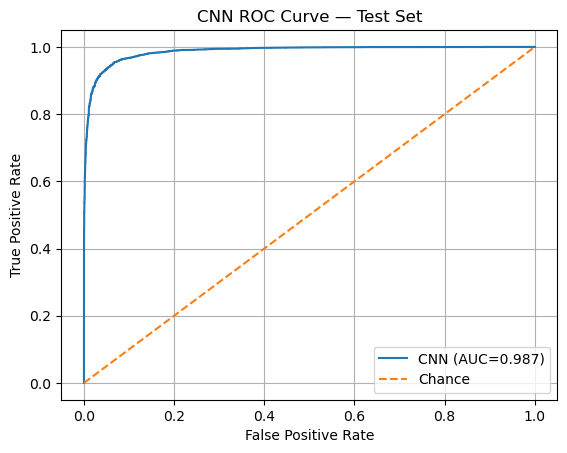

In [ ]:
# Train final model on full training set
final_cnn = build_improved_cnn(input_dim=input_dim)

history = final_cnn.fit(X_train_cnn, y_train_array,
                        epochs=50, batch_size=32, verbose=1,
                        validation_split=0.1, shuffle=True,
                        callbacks=[
                            tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
                            tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
                        ])

# Final test evaluation
y_prob_test = final_cnn.predict(X_test_cnn, verbose=0).flatten()
y_pred_test = (y_prob_test >= 0.5).astype(int)

acc, prec, rec, f1, fpr, auc = metrics_from_preds(y_test_array, y_pred_test, y_prob_test)
time_score = 1.0 / (1.0 + (1 - acc))  # just an example scoring
aps = (0.3 * acc) + (0.25 * (1 - fpr)) + (0.25 * rec) + (0.2 * time_score)

print("\n===== Final CNN Test Evaluation =====")
print(f"Accuracy           : {acc:.4f}")
print(f"Precision          : {prec:.4f}")
print(f"Recall (TPR)       : {rec:.4f}")
print(f"F1-score           : {f1:.4f}")
print(f"False Positive Rate: {fpr:.4f}")
print(f"AUC-ROC            : {auc:.4f}")
print(f"Anti-Phishing Score: {aps:.4f}")

# Plots
# Loss & Accuracy
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('CNN Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)
plt.show()

plt.figure()
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('CNN Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.grid(True)
plt.show()

# ROC curve
fpr_curve, tpr_curve, _ = roc_curve(y_test_array, y_prob_test)
plt.figure()
plt.plot(fpr_curve, tpr_curve, label=f'CNN (AUC={auc:.3f})')
plt.plot([0,1],[0,1], linestyle='--', label='Chance')
plt.title('CNN ROC Curve — Test Set')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.legend(); plt.grid(True)
plt.show()

### 30 runs (CNN)

In [ ]:
import os, random, time
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, Input, Model, backend as K
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix)
from tqdm import tqdm

# ======================================================
# GLOBAL SEED + GPU SETTINGS
# ======================================================
def set_global_seed(seed):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_global_seed(42)

for g in tf.config.list_physical_devices('GPU'):
    try: tf.config.experimental.set_memory_growth(g, True)
    except: pass

# ======================================================
# DATA HANDLING
# ======================================================
X_train_scaled = np.asarray(X_train_final, dtype=np.float32)
X_test_scaled  = np.asarray(X_test_final, dtype=np.float32)
y_train_array  = np.asarray(y_train, dtype=np.int32)
y_test_array   = np.asarray(y_test, dtype=np.int32)

input_dim = X_train_scaled.shape[1]
X_train_cnn = X_train_scaled.reshape(-1, input_dim, 1)

# ======================================================
# SIMPLE CNN ARCHITECTURE
# ======================================================
def build_simple_cnn(input_dim, learning_rate=0.001):
    K.clear_session()

    inp = Input(shape=(input_dim, 1))

    x = layers.Conv1D(32, 3, padding='same', activation='relu')(inp)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Flatten()(x)

    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)

    out = layers.Dense(1, activation='sigmoid')(x)

    model = Model(inp, out)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# ======================================================
# METRIC HELPER
# ======================================================
def compute_metrics(y_true, y_pred, y_prob):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    fpr  = fp / (fp + tn) if (fp + tn) != 0 else 0
    auc  = roc_auc_score(y_true, y_prob)
    return acc, prec, rec, f1, fpr, auc

# ======================================================
# STORAGE
# ======================================================
SEEDS = range(30)
per_seed_records = []

all_acc, all_prec, all_rec = [], [], []
all_f1, all_fpr, all_auc = [], [], []

# ======================================================
# TRAINING LOOP — WITH PROGRESS BARS
# ======================================================
print("\n===== 30-SEED TRAINING START =====\n")

for seed in tqdm(SEEDS, desc="Seeds", unit="seed"):

    set_global_seed(seed)

    seed_acc, seed_prec, seed_rec = [], [], []
    seed_f1, seed_fpr, seed_auc = [], [], []

    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=seed)

    # Inner CV Progress Bar
    for train_idx, val_idx in tqdm(
        skf.split(X_train_scaled, y_train_array),
        desc=f"Seed {seed} — 10 folds",
        unit="fold",
        leave=False
    ):

        X_tr, X_val = X_train_cnn[train_idx], X_train_cnn[val_idx]
        y_tr, y_val = y_train_array[train_idx], y_train_array[val_idx]

        model = build_simple_cnn(input_dim)

        callbacks = [
            tf.keras.callbacks.ReduceLROnPlateau(
                monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=0),
            tf.keras.callbacks.EarlyStopping(
                monitor='val_loss', patience=5, restore_best_weights=True, verbose=0)
        ]

        model.fit(
            X_tr, y_tr,
            epochs=50,
            batch_size=32,
            validation_data=(X_val, y_val),
            verbose=0,
            callbacks=callbacks
        )

        y_prob = model.predict(X_val, verbose=0).flatten()
        y_pred = (y_prob >= 0.5).astype(int)

        acc, prec, rec, f1, fpr, auc = compute_metrics(y_val, y_pred, y_prob)

        seed_acc.append(acc)
        seed_prec.append(prec)
        seed_rec.append(rec)
        seed_f1.append(f1)
        seed_fpr.append(fpr)
        seed_auc.append(auc)

    # Store per seed
    per_seed_records.append({
        "seed": seed,
        "accuracy_mean": np.mean(seed_acc),
        "precision_mean": np.mean(seed_prec),
        "recall_mean": np.mean(seed_rec),
        "f1_mean": np.mean(seed_f1),
        "fpr_mean": np.mean(seed_fpr),
        "auc_mean": np.mean(seed_auc)
    })

    all_acc.extend(seed_acc)
    all_prec.extend(seed_prec)
    all_rec.extend(seed_rec)
    all_f1.extend(seed_f1)
    all_fpr.extend(seed_fpr)
    all_auc.extend(seed_auc)

# ======================================================
# SAVE CSV — PER SEED
# ======================================================
pd.DataFrame(per_seed_records).to_csv("/content/cnn_per_seed_results.csv", index=False)
print("\nSaved: cnn_per_seed_results.csv")

# ======================================================
# FINAL MEAN ± STD
# ======================================================
print("\n========== FINAL CNN RESULTS (300 runs) ==========")
print(f"Accuracy : {np.mean(all_acc):.4f} ± {np.std(all_acc):.4f}")
print(f"Precision: {np.mean(all_prec):.4f} ± {np.std(all_prec):.4f}")
print(f"Recall   : {np.mean(all_rec):.4f} ± {np.std(all_rec):.4f}")
print(f"F1-score : {np.mean(all_f1):.4f} ± {np.std(all_f1):.4f}")
print(f"FPR      : {np.mean(all_fpr):.4f} ± {np.std(all_fpr):.4f}")
print(f"AUC-ROC  : {np.mean(all_auc):.4f} ± {np.std(all_auc):.4f}")

pd.DataFrame({
    "metric": ["accuracy", "precision", "recall", "f1", "fpr", "auc"],
    "mean": [
        np.mean(all_acc), np.mean(all_prec), np.mean(all_rec),
        np.mean(all_f1), np.mean(all_fpr), np.mean(all_auc)
    ],
    "std": [
        np.std(all_acc), np.std(all_prec), np.std(all_rec),
        np.std(all_f1), np.std(all_fpr), np.std(all_auc)
    ]
}).to_csv("/content/cnn_final_overall_results.csv", index=False)

print("Saved: cnn_final_overall_results.csv")



===== 30-SEED TRAINING START =====



Seeds:   0%|          | 0/30 [00:00<?, ?seed/s]
Seed 0 — 10 folds: 0fold [00:00, ?fold/s]
Seed 0 — 10 folds: 1fold [02:19, 139.46s/fold]
Seed 0 — 10 folds: 2fold [03:31, 99.92s/fold] 
Seed 0 — 10 folds: 3fold [05:48, 116.85s/fold]
Seed 0 — 10 folds: 4fold [08:05, 124.88s/fold]
Seed 0 — 10 folds: 5fold [10:22, 129.27s/fold]
Seed 0 — 10 folds: 6fold [12:40, 132.06s/fold]
Seed 0 — 10 folds: 7fold [14:57, 133.66s/fold]
Seed 0 — 10 folds: 8fold [17:14, 134.62s/fold]
Seed 0 — 10 folds: 9fold [19:31, 135.43s/fold]
Seed 0 — 10 folds: 10fold [21:48, 136.02s/fold]
Seeds:   3%|▎         | 1/30 [21:48<10:32:29, 1308.61s/seed]
Seed 1 — 10 folds: 0fold [00:00, ?fold/s]
Seed 1 — 10 folds: 1fold [01:35, 95.38s/fold]
Seed 1 — 10 folds: 2fold [03:51, 119.40s/fold]
Seed 1 — 10 folds: 3fold [06:07, 127.12s/fold]
Seed 1 — 10 folds: 4fold [08:24, 130.88s/fold]
Seed 1 — 10 folds: 5fold [10:40, 132.86s/fold]
Seed 1 — 10 folds: 6fold [12:57, 134.14s/fold]
Seed 1 — 10 folds: 7fold [15:14, 134.95s/fold]
Seed 1 —


Saved: cnn_per_seed_results.csv

========== FINAL CNN RESULTS (300 runs) ==========
Accuracy : 0.9362 ± 0.0037
Precision: 0.9371 ± 0.0057
Recall   : 0.9422 ± 0.0060
F1-score : 0.9396 ± 0.0035
FPR      : 0.0705 ± 0.0070
AUC-ROC  : 0.9830 ± 0.0015
Saved: cnn_final_overall_results.csv


### FNN

Matched FNN CV Folds:   0%|          | 0/10 [00:00<?, ?it/s]


Training Fold 1/10...


Matched FNN CV Folds:  10%|█         | 1/10 [01:02<09:23, 62.66s/it]


Training Fold 2/10...


Matched FNN CV Folds:  20%|██        | 2/10 [02:03<08:12, 61.55s/it]

...

Matched FNN CV Folds:  90%|█████████ | 9/10 [10:25<01:11, 71.51s/it]


Training Fold 10/10...


Matched FNN CV Folds: 100%|██████████| 10/10 [11:40<00:00, 70.07s/it]


========== Cross-Validation Results (Matched FNN) ==========
Accuracy    : 0.9379 ± 0.0033
Precision   : 0.9415 ± 0.0073
Recall (TPR): 0.9406 ± 0.0059
F1-score    : 0.9410 ± 0.0030
FPR         : 0.0651 ± 0.0089
AUC-ROC     : 0.9832 ± 0.0013
APS Score   : 0.9035 ± 0.0037
Epoch 1/50


1279/1279 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8639 - loss: 0.3189 - val_accuracy: 0.8984 - val_loss: 0.2461 - learning_rate: 0.0010
Epoch 2/50
1279/1279 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8912 - loss: 0.2637 - val_accuracy: 0.9013 - val_loss: 0.2340 - learning_rate: 0.0010
Epoch 3/50
1279/1279 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9005 - loss: 0.2458 - val_accuracy: 0.9052 - val_loss: 0.2286 - learning_rate: 0.0010
Epoch 4/50
1279/1279 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9062 - loss: 0.2342 - val_accuracy: 0.9120 - val_loss: 0.2147 - learning_rate: 0.0010
Epoch 5/50
1279/1279 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9101 - loss: 0.2262 - val_accuracy: 0.9112 - val_loss: 0.2150 - learning_rate: 0.0010
Epoch 6/50
1279/1279 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9136 - loss: 0.2191 - val_accuracy: 0.9138 - val_loss: 0.2083 - learning_rate: 0.0010
Epoch 7/50
1279/1279 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9167 - loss: 0.2133

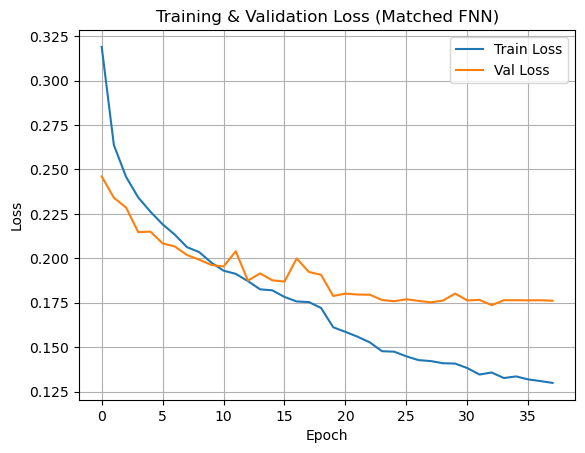

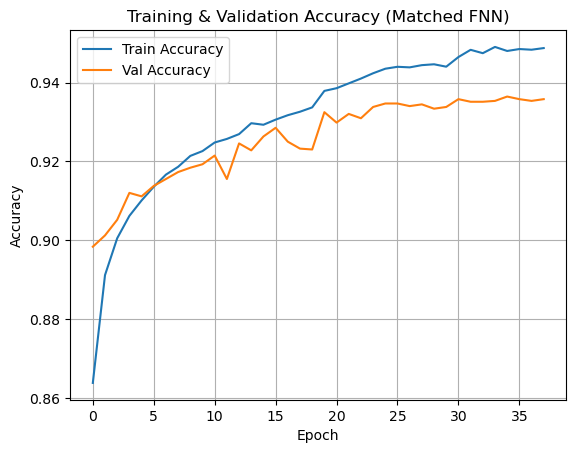

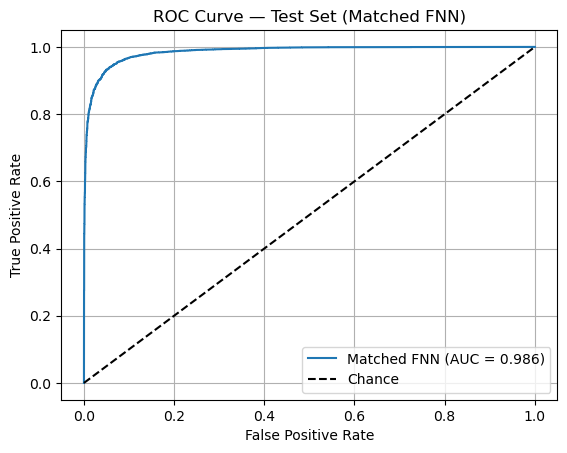

In [ ]:
import numpy as np
import random, time, os
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import models, layers, Input, Model
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, roc_curve)
from tqdm import tqdm

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

def to_numpy(X):
    return X.values.astype(np.float32) if hasattr(X, 'values') else X.astype(np.float32)

# FNN Builder
def build_matched_fnn(input_dim, learning_rate=0.001):
    inputs = Input(shape=(input_dim,))
    x = layers.Dense(64, activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(128, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.BatchNormalization()(x)

    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# 10-Fold Stratified Cross-Validation
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)

acc_list, prec_list, recall_list, f1_list, fpr_list, auc_list, aps_list = [], [], [], [], [], [], []

splits = list(skf.split(X_train_final, y_train))
for fold, (train_idx, val_idx) in enumerate(tqdm(splits, total=len(splits), desc="Matched FNN CV Folds"), start=1):
    print(f"\nTraining Fold {fold}/10...")
    X_train_fold = to_numpy(X_train_final[train_idx])
    X_val_fold   = to_numpy(X_train_final[val_idx])
    y_train_fold = y_train[train_idx]
    y_val_fold   = y_train[val_idx]

    model = build_matched_fnn(X_train_fold.shape[1], learning_rate=0.001)

    early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    lr_schedule = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

    model.fit(
        X_train_fold, y_train_fold,
        validation_data=(X_val_fold, y_val_fold),
        epochs=50, batch_size=32, verbose=0,
        callbacks=[early_stop, lr_schedule]
    )

    start_time = time.time()
    y_proba = model.predict(X_val_fold, verbose=0).ravel()
    y_pred  = (y_proba >= 0.5).astype(int)
    end_time = time.time()

    tn, fp, fn, tp = confusion_matrix(y_val_fold, y_pred, labels=[0,1]).ravel()
    acc = accuracy_score(y_val_fold, y_pred)
    prec = precision_score(y_val_fold, y_pred, zero_division=0)
    recall = recall_score(y_val_fold, y_pred, zero_division=0)
    f1 = f1_score(y_val_fold, y_pred, zero_division=0)
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    auc = roc_auc_score(y_val_fold, y_proba)
    test_time = end_time - start_time
    time_score = 1.0 / (1.0 + test_time)
    aps = (0.3 * acc) + (0.25 * (1 - fpr)) + (0.25 * recall) + (0.2 * time_score)

    acc_list.append(acc); prec_list.append(prec); recall_list.append(recall)
    f1_list.append(f1); fpr_list.append(fpr); auc_list.append(auc); aps_list.append(aps)

print("\n========== Cross-Validation Results (FNN) ==========")
print(f"Accuracy    : {np.mean(acc_list):.4f} ± {np.std(acc_list):.4f}")
print(f"Precision   : {np.mean(prec_list):.4f} ± {np.std(prec_list):.4f}")
print(f"Recall (TPR): {np.mean(recall_list):.4f} ± {np.std(recall_list):.4f}")
print(f"F1-score    : {np.mean(f1_list):.4f} ± {np.std(f1_list):.4f}")
print(f"FPR         : {np.mean(fpr_list):.4f} ± {np.std(fpr_list):.4f}")
print(f"AUC-ROC     : {np.mean(auc_list):.4f} ± {np.std(auc_list):.4f}")
print(f"APS Score   : {np.mean(aps_list):.4f} ± {np.std(aps_list):.4f}")

# ============================================================
# Final Model — Train on Full Train Set
# ============================================================
X_train_fnn = to_numpy(X_train_final)
X_test_fnn  = to_numpy(X_test_final)

final_fnn = build_matched_fnn(X_train_fnn.shape[1], learning_rate=0.001)

early_stop_final = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lr_schedule_final = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

history = final_fnn.fit(
    X_train_fnn, y_train,
    epochs=50, batch_size=32, verbose=1,
    validation_split=0.1, shuffle=True,
    callbacks=[early_stop_final, lr_schedule_final]
)

# ============================================================
# Final Evaluation — Test Set
# ============================================================
start_time = time.time()
y_proba_test = final_fnn.predict(X_test_fnn, verbose=0).ravel()
y_pred_test  = (y_proba_test >= 0.5).astype(int)
end_time = time.time()
test_time = end_time - start_time

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test, labels=[0,1]).ravel()
accuracy  = accuracy_score(y_test, y_pred_test)
precision = precision_score(y_test, y_pred_test, zero_division=0)
recall    = recall_score(y_test, y_pred_test, zero_division=0)
f1        = f1_score(y_test, y_pred_test, zero_division=0)
fpr       = fp / (fp + tn)
auc_roc   = roc_auc_score(y_test, y_proba_test)
time_score = 1.0 / (1.0 + test_time)
aps = (0.3 * accuracy) + (0.25 * (1 - fpr)) + (0.25 * recall) + (0.2 * time_score)

print("\n========== Final FNN Test Evaluation ==========")
print(f"Accuracy           : {accuracy:.4f}")
print(f"Precision          : {precision:.4f}")
print(f"Recall (TPR)       : {recall:.4f}")
print(f"F1-score           : {f1:.4f}")
print(f"False Positive Rate: {fpr:.4f}")
print(f"AUC-ROC            : {auc_roc:.4f}")
print(f"Anti-Phishing Score: {aps:.4f}")

# ============================================================
# Visualization
# ============================================================
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training & Validation Loss (Matched FNN)')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend(); plt.grid(True)
plt.show()

plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Training & Validation Accuracy (Matched FNN)')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.legend(); plt.grid(True)
plt.show()

fpr_curve, tpr_curve, _ = roc_curve(y_test, y_proba_test)
plt.figure()
plt.plot(fpr_curve, tpr_curve, label=f'Matched FNN (AUC = {auc_roc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Chance')
plt.title('ROC Curve — Test Set (Matched FNN)')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.legend(); plt.grid(True)
plt.show()


### 30 runs (FNN)

In [ ]:
import os, random
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, Input, Model, backend as K
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)
from tqdm import tqdm

# ======================================================
# GLOBAL SEED + GPU SETTINGS
# ======================================================
def set_global_seed(seed):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_global_seed(42)

for g in tf.config.list_physical_devices('GPU'):
    try: tf.config.experimental.set_memory_growth(g, True)
    except: pass

# ======================================================
# DATA HANDLING
# ======================================================
X_train_scaled = np.asarray(X_train_final, dtype=np.float32)
X_test_scaled  = np.asarray(X_test_final, dtype=np.float32)
y_train_array  = np.asarray(y_train, dtype=np.int32)
y_test_array   = np.asarray(y_test, dtype=np.int32)

input_dim = X_train_scaled.shape[1]

# ======================================================
# SIMPLE FNN MODEL
# ======================================================
def build_simple_fnn(input_dim, learning_rate=0.001):
    K.clear_session()

    inp = Input(shape=(input_dim,))
    x = layers.Dense(64, activation='relu')(inp)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(1, activation='sigmoid')(x)

    model = Model(inp, out)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# ======================================================
# METRIC HELPER
# ======================================================
def compute_metrics(y_true, y_pred, y_prob):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    fpr  = fp / (fp + tn) if (fp + tn) != 0 else 0
    auc  = roc_auc_score(y_true, y_prob)
    return acc, prec, rec, f1, fpr, auc

# ======================================================
# STORAGE
# ======================================================
SEEDS = range(30)
per_seed_records = []

all_acc, all_prec, all_rec = [], [], []
all_f1, all_fpr, all_auc = [], [], []

# ======================================================
# TRAINING LOOP — WITH PROGRESS BARS
# ======================================================
print("\n===== 30-SEED TRAINING START =====\n")

for seed in tqdm(SEEDS, desc="Seeds", unit="seed"):

    set_global_seed(seed)

    seed_acc, seed_prec, seed_rec = [], [], []
    seed_f1, seed_fpr, seed_auc = [], [], []

    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=seed)

    for train_idx, val_idx in tqdm(
        skf.split(X_train_scaled, y_train_array),
        desc=f"Seed {seed} - 10 folds",
        unit="fold",
        leave=False
    ):

        X_tr, X_val = X_train_scaled[train_idx], X_train_scaled[val_idx]
        y_tr, y_val = y_train_array[train_idx], y_train_array[val_idx]

        model = build_simple_fnn(input_dim)

        callbacks = [
            tf.keras.callbacks.ReduceLROnPlateau(
                monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=0
            ),
            tf.keras.callbacks.EarlyStopping(
                monitor="val_loss", patience=5, restore_best_weights=True, verbose=0
            )
        ]

        model.fit(
            X_tr, y_tr,
            epochs=50,
            batch_size=32,
            validation_data=(X_val, y_val),
            verbose=0,
            callbacks=callbacks
        )

        y_prob = model.predict(X_val, verbose=0).flatten()
        y_pred = (y_prob >= 0.5).astype(int)

        acc, prec, rec, f1, fpr, auc = compute_metrics(y_val, y_pred, y_prob)

        seed_acc.append(acc)
        seed_prec.append(prec)
        seed_rec.append(rec)
        seed_f1.append(f1)
        seed_fpr.append(fpr)
        seed_auc.append(auc)

    # ======================================================
    # PRINT SEED RESULT
    # ======================================================
    print(f"\nSeed {seed} Results → "
          f"Acc={np.mean(seed_acc):.4f}, "
          f"Prec={np.mean(seed_prec):.4f}, "
          f"Rec={np.mean(seed_rec):.4f}, "
          f"F1={np.mean(seed_f1):.4f}, "
          f"FPR={np.mean(seed_fpr):.4f}, "
          f"AUC={np.mean(seed_auc):.4f}\n")

    # Store per-seed results
    per_seed_records.append({
        "seed": seed,
        "accuracy_mean": np.mean(seed_acc),
        "precision_mean": np.mean(seed_prec),
        "recall_mean": np.mean(seed_rec),
        "f1_mean": np.mean(seed_f1),
        "fpr_mean": np.mean(seed_fpr),
        "auc_mean": np.mean(seed_auc)
    })

    all_acc.extend(seed_acc)
    all_prec.extend(seed_prec)
    all_rec.extend(seed_rec)
    all_f1.extend(seed_f1)
    all_fpr.extend(seed_fpr)
    all_auc.extend(seed_auc)

# ======================================================
# SAVE CSV — PER SEED
# ======================================================
pd.DataFrame(per_seed_records).to_csv("/content/fnn_per_seed_results.csv", index=False)
print("\nSaved: fnn_per_seed_results.csv")

# ======================================================
# FINAL OVERALL SUMMARY (300 RUNS)
# ======================================================
print("\n========== FINAL FNN RESULTS (300 runs) ==========")
print(f"Accuracy : {np.mean(all_acc):.4f} ± {np.std(all_acc):.4f}")
print(f"Precision: {np.mean(all_prec):.4f} ± {np.std(all_prec):.4f}")
print(f"Recall   : {np.mean(all_rec):.4f} ± {np.std(all_rec):.4f}")
print(f"F1-score : {np.mean(all_f1):.4f} ± {np.std(all_f1):.4f}")
print(f"FPR      : {np.mean(all_fpr):.4f} ± {np.std(all_fpr):.4f}")
print(f"AUC-ROC  : {np.mean(all_auc):.4f} ± {np.std(all_auc):.4f}")

pd.DataFrame({
    "metric": ["accuracy", "precision", "recall", "f1", "fpr", "auc"],
    "mean": [
        np.mean(all_acc), np.mean(all_prec), np.mean(all_rec),
        np.mean(all_f1), np.mean(all_fpr), np.mean(all_auc)
    ],
    "std": [
        np.std(all_acc), np.std(all_prec), np.std(all_rec),
        np.std(all_f1), np.std(all_fpr), np.std(all_auc)
    ]
}).to_csv("/content/fnn_final_overall_results.csv", index=False)

print("Saved: fnn_final_overall_results.csv")



===== 30-SEED TRAINING START =====



Seeds:   0%|          | 0/30 [00:00<?, ?seed/s]
Seed 0 - 10 folds: 0fold [00:00, ?fold/s]
Seed 0 - 10 folds: 1fold [02:05, 125.52s/fold]
Seed 0 - 10 folds: 2fold [04:11, 125.69s/fold]
Seed 0 - 10 folds: 3fold [06:19, 126.60s/fold]
Seed 0 - 10 folds: 4fold [08:24, 126.18s/fold]
Seed 0 - 10 folds: 5fold [10:30, 125.95s/fold]
Seed 0 - 10 folds: 6fold [12:36, 126.04s/fold]
Seed 0 - 10 folds: 7fold [14:41, 125.70s/fold]
Seed 0 - 10 folds: 8fold [16:47, 125.79s/fold]
Seed 0 - 10 folds: 9fold [18:52, 125.62s/fold]
Seed 0 - 10 folds: 10fold [20:58, 125.58s/fold]
Seeds:   3%|▎         | 1/30 [20:58<10:08:02, 1258.02s/seed]


Seed 0 Results → Acc=0.9359, Prec=0.9407, Rec=0.9375, F1=0.9391, FPR=0.0658, AUC=0.9825




Seed 1 - 10 folds: 0fold [00:00, ?fold/s]
Seed 1 - 10 folds: 1fold [02:06, 126.32s/fold]
Seed 1 - 10 folds: 2fold [04:11, 125.72s/fold]
Seed 1 - 10 folds: 3fold [06:17, 125.77s/fold]
Seed 1 - 10 folds: 4fold [08:19, 124.17s/fold]
Seed 1 - 10 folds: 5fold [10:24, 124.66s/fold]
Seed 1 - 10 folds: 6fold [12:31, 125.48s/fold]
Seed 1 - 10 folds: 7fold [14:37, 125.45s/fold]
Seed 1 - 10 folds: 8fold [16:44, 125.95s/fold]
Seed 1 - 10 folds: 9fold [18:50, 125.93s/fold]
Seed 1 - 10 folds: 10fold [20:55, 125.69s/fold]
Seeds:   7%|▋         | 2/30 [41:53<9:46:18, 1256.38s/seed] 


Seed 1 Results → Acc=0.9354, Prec=0.9389, Rec=0.9386, F1=0.9387, FPR=0.0680, AUC=0.9824



...


Seed 27 Results → Acc=0.9352, Prec=0.9374, Rec=0.9398, F1=0.9386, FPR=0.0698, AUC=0.9822




Seed 28 - 10 folds: 0fold [00:00, ?fold/s]
Seed 28 - 10 folds: 1fold [02:07, 127.22s/fold]
Seed 28 - 10 folds: 2fold [04:15, 127.63s/fold]
Seed 28 - 10 folds: 3fold [06:23, 127.97s/fold]
Seed 28 - 10 folds: 4fold [08:31, 128.11s/fold]
Seed 28 - 10 folds: 5fold [10:40, 128.17s/fold]
Seed 28 - 10 folds: 6fold [12:48, 128.26s/fold]
Seed 28 - 10 folds: 7fold [14:56, 128.29s/fold]
Seed 28 - 10 folds: 8fold [17:04, 128.09s/fold]
Seed 28 - 10 folds: 9fold [18:58, 123.52s/fold]
Seed 28 - 10 folds: 10fold [21:06, 125.01s/fold]
Seeds:  97%|█████████▋| 29/30 [10:09:42<21:03, 1263.78s/seed]


Seed 28 Results → Acc=0.9364, Prec=0.9396, Rec=0.9397, F1=0.9396, FPR=0.0673, AUC=0.9826




Seed 29 - 10 folds: 0fold [00:00, ?fold/s]
Seed 29 - 10 folds: 1fold [02:08, 128.44s/fold]
Seed 29 - 10 folds: 2fold [04:17, 128.70s/fold]
Seed 29 - 10 folds: 3fold [06:24, 128.22s/fold]
Seed 29 - 10 folds: 4fold [08:33, 128.44s/fold]
Seed 29 - 10 folds: 5fold [10:41, 128.28s/fold]
Seed 29 - 10 folds: 6fold [12:50, 128.35s/fold]
Seed 29 - 10 folds: 7fold [14:27, 118.14s/fold]
Seed 29 - 10 folds: 8fold [16:35, 121.23s/fold]
Seed 29 - 10 folds: 9fold [18:44, 123.62s/fold]
Seed 29 - 10 folds: 10fold [20:52, 125.18s/fold]
Seeds: 100%|██████████| 30/30 [10:30:35<00:00, 1261.18s/seed]


Seed 29 Results → Acc=0.9349, Prec=0.9358, Rec=0.9411, F1=0.9384, FPR=0.0719, AUC=0.9822


Saved: fnn_per_seed_results.csv

========== FINAL FNN RESULTS (300 runs) ==========
Accuracy : 0.9358 ± 0.0035
Precision: 0.9382 ± 0.0053
Recall   : 0.9401 ± 0.0057
F1-score : 0.9391 ± 0.0033
FPR      : 0.0689 ± 0.0064
AUC-ROC  : 0.9824 ± 0.0015
Saved: fnn_final_overall_results.csv


### LSTM

Matched LSTM CV Folds: 100%|██████████| 10/10 [44:56<00:00, 269.62s/it]


========== Cross-Validation Results (Matched LSTM) ==========
Accuracy    : 0.9343 ± 0.0030
Precision   : 0.9370 ± 0.0065
Recall (TPR): 0.9383 ± 0.0062
F1-score    : 0.9376 ± 0.0028
FPR         : 0.0703 ± 0.0081
AUC-ROC     : 0.9824 ± 0.0014
APS Score   : 0.8484 ± 0.0062
Epoch 1/50


1279/1279 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8391 - loss: 0.3795 - val_accuracy: 0.8755 - val_loss: 0.2698 - learning_rate: 0.0010
Epoch 2/50
1279/1279 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8649 - loss: 0.3127 - val_accuracy: 0.8951 - val_loss: 0.2426 - learning_rate: 0.0010
Epoch 3/50
1279/1279 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8740 - loss: 0.2965 - val_accuracy: 0.9008 - val_loss: 0.2338 - learning_rate: 0.0010
Epoch 4/50
1279/1279 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8787 - loss: 0.2847 - val_accuracy: 0.8980 - val_loss: 0.2318 - learning_rate: 0.0010
Epoch 5/50
1279/1279 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8838 - loss: 0.2775 - val_accuracy: 0.9041 - val_loss: 0.2269 - learning_rate: 0.0010
Epoch 6/50
1279/1279 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8870 - loss: 0.2723 - val_accuracy: 0.9085 - val_loss: 0.2216 - learning_rate: 0.0010
Epoch 7/50
1279/1279 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8910 - loss: 0.266

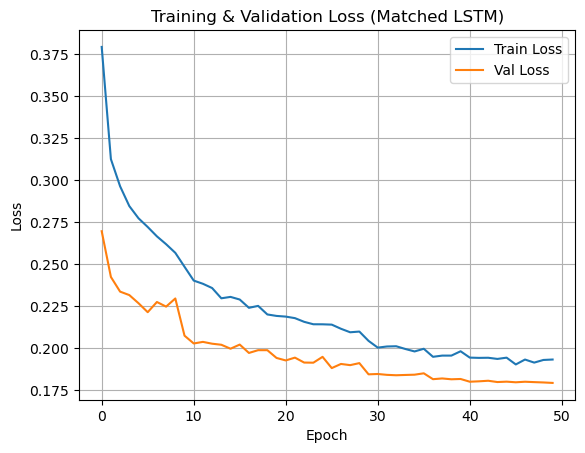

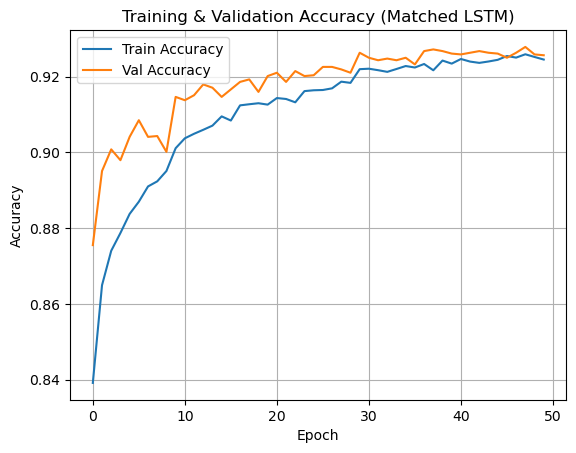

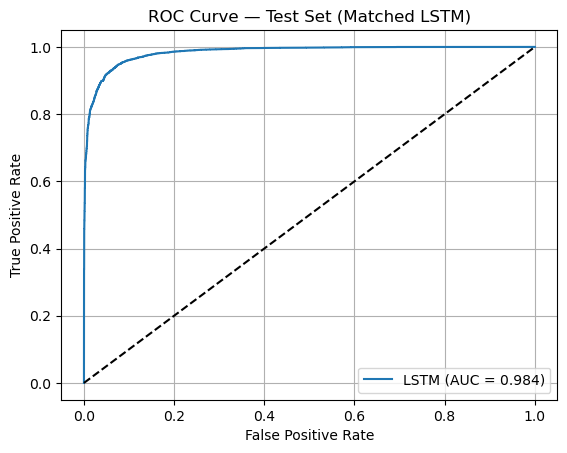

In [ ]:
import os, random, time
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve
)
from tensorflow.keras import Input, Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ---------------------------
# Reproducibility
# ---------------------------
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

# ---------------------------
# Safe conversion helper
# ---------------------------
def to_numpy(X):
    """Convert pandas DataFrame/Series → NumPy safely."""
    return X.values.astype(np.float32) if hasattr(X, "values") else X.astype(np.float32)

# ---------------------------
# Model builder
# ---------------------------
def build_matched_lstm(input_dim, learning_rate=0.001):
    model = Sequential([
        Input(shape=(1, input_dim)),

        # --- Block 1 ---
        LSTM(64, return_sequences=True),
        BatchNormalization(),
        Dropout(0.3),

        LSTM(64, return_sequences=True),
        BatchNormalization(),
        Dropout(0.3),

        # --- Block 2 ---
        LSTM(128, return_sequences=True),
        BatchNormalization(),
        Dropout(0.4),

        LSTM(128),
        BatchNormalization(),
        Dropout(0.4),

        # --- Dense head ---
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.4),

        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# ============================================================
# 10-Fold Cross-Validation
# ============================================================
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)

acc_list, prec_list, recall_list, f1_list, fpr_list, auc_list, aps_list = [], [], [], [], [], [], []

for fold, (train_idx, val_idx) in enumerate(tqdm(skf.split(X_train_final, y_train), total=10, desc="Matched LSTM CV Folds"), 1):
    # Convert safely
    X_train_fold = to_numpy(X_train_final[train_idx] if not hasattr(X_train_final, "iloc") else X_train_final.iloc[train_idx])
    X_val_fold   = to_numpy(X_train_final[val_idx] if not hasattr(X_train_final, "iloc") else X_train_final.iloc[val_idx])
    y_train_fold = y_train[train_idx] if not hasattr(y_train, "iloc") else y_train.iloc[train_idx]
    y_val_fold   = y_train[val_idx] if not hasattr(y_train, "iloc") else y_train.iloc[val_idx]

    # Reshape for LSTM
    X_train_fold = X_train_fold.reshape((X_train_fold.shape[0], 1, X_train_fold.shape[1]))
    X_val_fold   = X_val_fold.reshape((X_val_fold.shape[0], 1, X_val_fold.shape[1]))

    model = build_matched_lstm(X_train_fold.shape[2])

    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    lr_reduce = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

    model.fit(
        X_train_fold, y_train_fold,
        validation_data=(X_val_fold, y_val_fold),
        epochs=50, batch_size=32, verbose=0,
        callbacks=[early_stop, lr_reduce]
    )

    # Validation metrics
    t0 = time.time()
    y_proba = model.predict(X_val_fold, verbose=0).flatten()
    y_pred  = (y_proba >= 0.5).astype(int)
    t1 = time.time()

    tn, fp, fn, tp = confusion_matrix(y_val_fold, y_pred).ravel()
    acc = accuracy_score(y_val_fold, y_pred)
    prec = precision_score(y_val_fold, y_pred, zero_division=0)
    recall = recall_score(y_val_fold, y_pred, zero_division=0)
    f1 = f1_score(y_val_fold, y_pred, zero_division=0)
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    auc = roc_auc_score(y_val_fold, y_proba)
    test_time = t1 - t0
    time_score = 1.0 / (1.0 + test_time)
    aps = (0.3 * acc) + (0.25 * (1 - fpr)) + (0.25 * recall) + (0.2 * time_score)

    acc_list.append(acc); prec_list.append(prec); recall_list.append(recall)
    f1_list.append(f1); fpr_list.append(fpr); auc_list.append(auc); aps_list.append(aps)

print("\n========== Cross-Validation Results (Matched LSTM) ==========")
print(f"Accuracy    : {np.mean(acc_list):.4f} ± {np.std(acc_list):.4f}")
print(f"Precision   : {np.mean(prec_list):.4f} ± {np.std(prec_list):.4f}")
print(f"Recall (TPR): {np.mean(recall_list):.4f} ± {np.std(recall_list):.4f}")
print(f"F1-score    : {np.mean(f1_list):.4f} ± {np.std(f1_list):.4f}")
print(f"FPR         : {np.mean(fpr_list):.4f} ± {np.std(fpr_list):.4f}")
print(f"AUC-ROC     : {np.mean(auc_list):.4f} ± {np.std(auc_list):.4f}")
print(f"APS Score   : {np.mean(aps_list):.4f} ± {np.std(aps_list):.4f}")

# ============================================================
# Final Model (Train on Full Data)
# ============================================================
X_train_lstm = to_numpy(X_train_final).reshape((len(X_train_final), 1, X_train_final.shape[1]))
X_test_lstm  = to_numpy(X_test_final).reshape((len(X_test_final), 1, X_test_final.shape[1]))

final_lstm = build_matched_lstm(X_train_lstm.shape[2])
early_stop_final = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lr_reduce_final = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

history = final_lstm.fit(
    X_train_lstm, y_train,
    epochs=50, batch_size=32, verbose=1,
    validation_split=0.1,
    callbacks=[early_stop_final, lr_reduce_final]
)

# ============================================================
# Test Evaluation
# ============================================================
t0 = time.time()
y_proba = final_lstm.predict(X_test_lstm, verbose=0).flatten()
y_pred  = (y_proba >= 0.5).astype(int)
t1 = time.time()

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall    = recall_score(y_test, y_pred, zero_division=0)
f1_lstm   = f1_score(y_test, y_pred, zero_division=0)
fpr       = fp / (fp + tn)
auc_roc   = roc_auc_score(y_test, y_proba)
test_time = t1 - t0
time_score = 1.0 / (1.0 + test_time)
aps = (0.3 * accuracy) + (0.25 * (1 - fpr)) + (0.25 * recall) + (0.2 * time_score)

print("\n===== Final Matched LSTM Test Evaluation =====")
print(f"Accuracy           : {accuracy:.4f}")
print(f"Precision          : {precision:.4f}")
print(f"Recall (TPR)       : {recall:.4f}")
print(f"F1-score           : {f1_lstm:.4f}")
print(f"False Positive Rate: {fpr:.4f}")
print(f"AUC-ROC            : {auc_roc:.4f}")
print(f"Anti-Phishing Score: {aps:.4f}")

# ============================================================
# Plots — Loss, Accuracy, ROC
# ============================================================
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training & Validation Loss (Matched LSTM)')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend(); plt.grid(True)
plt.show()

plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Training & Validation Accuracy (Matched LSTM)')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.legend(); plt.grid(True)
plt.show()

fpr_curve, tpr_curve, _ = roc_curve(y_test, y_proba)
plt.figure()
plt.plot(fpr_curve, tpr_curve, label=f'LSTM (AUC = {auc_roc:.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve — Test Set (Matched LSTM)')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.legend(); plt.grid(True)
plt.show()


### 30 runs (LSTM)

In [36]:
import os, random, time
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)

from tqdm import tqdm

# ======================================================
# GLOBAL SEED + DEVICE
# ======================================================
def set_global_seed(seed):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_global_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ======================================================
# DATA HANDLING
# ======================================================
X_train_scaled = np.asarray(X_train_final, dtype=np.float32)
X_test_scaled  = np.asarray(X_test_final, dtype=np.float32)
y_train_array  = np.asarray(y_train, dtype=np.int64)
y_test_array   = np.asarray(y_test, dtype=np.int64)

input_dim = X_train_scaled.shape[1]

# LSTM expects (batch, timesteps, features)
# we treat each feature as a timestep (T = num_features, F = 1)
X_train_lstm_full = X_train_scaled.reshape(-1, input_dim, 1)

# ======================================================
# MODEL DEFINITION (similar to your Keras LSTM)
# ======================================================
class SimpleLSTM(nn.Module):
    def __init__(self, input_dim, hidden_size=64):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=hidden_size,
            batch_first=True
        )
        self.dropout1 = nn.Dropout(0.3)
        self.fc1 = nn.Linear(hidden_size, 64)
        self.dropout2 = nn.Dropout(0.3)
        self.fc_out = nn.Linear(64, 1)

    def forward(self, x):
        # x: (batch, timesteps, 1)
        out, (h_n, c_n) = self.lstm(x)
        # last layer's hidden state: (num_layers * num_directions, batch, hidden_size)
        h_last = h_n[-1]  # (batch, hidden_size)
        x = self.dropout1(h_last)
        x = torch.relu(self.fc1(x))
        x = self.dropout2(x)
        x = self.fc_out(x)   # raw logits
        return x

# ======================================================
# METRIC HELPER (same logic as your TF version)
# ======================================================
def compute_metrics(y_true, y_pred, y_prob):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    fpr  = fp / (fp + tn) if (fp + tn) != 0 else 0
    auc  = roc_auc_score(y_true, y_prob)
    return acc, prec, rec, f1, fpr, auc

# ======================================================
# TRAIN ONE FOLD WITH EARLY STOPPING + LR SCHEDULER
# ======================================================
def train_one_fold(model, train_loader, val_loader,
                   max_epochs=50, patience=5, base_lr=1e-3):

    model.to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=base_lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=False
    )

    best_val_loss = float('inf')
    best_state_dict = None
    epochs_no_improve = 0

    for epoch in range(max_epochs):
        model.train()
        train_loss = 0.0

        for batch_x, batch_y in train_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device).float().unsqueeze(1)  # (batch, 1)

            optimizer.zero_grad()
            logits = model(batch_x)
            loss = criterion(logits, batch_y)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * batch_x.size(0)

        train_loss /= len(train_loader.dataset)

        # ---------- validation ----------
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x = batch_x.to(device)
                batch_y = batch_y.to(device).float().unsqueeze(1)
                logits = model(batch_x)
                loss = criterion(logits, batch_y)
                val_loss += loss.item() * batch_x.size(0)

        val_loss /= len(val_loader.dataset)
        scheduler.step(val_loss)

        # early stopping check
        if val_loss < best_val_loss - 1e-6:
            best_val_loss = val_loss
            best_state_dict = model.state_dict()
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            break

    # restore best weights
    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)

    # collect predictions for this fold
    model.eval()
    all_logits = []
    all_targets = []

    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            batch_x = batch_x.to(device)
            logits = model(batch_x)
            all_logits.append(logits.cpu())
            all_targets.append(batch_y)

    all_logits = torch.cat(all_logits, dim=0).squeeze(1).numpy()
    all_targets = torch.cat(all_targets, dim=0).numpy()

    # convert logits → probabilities via sigmoid
    y_prob = 1 / (1 + np.exp(-all_logits))
    y_pred = (y_prob >= 0.5).astype(int)

    return all_targets, y_pred, y_prob

# ======================================================
# STORAGE
# ======================================================
SEEDS = range(30)
per_seed_records = []

all_acc, all_prec, all_rec = [], [], []
all_f1, all_fpr, all_auc = [], [], []

# ======================================================
# TRAINING LOOP — 30 SEEDS × 10 FOLDS
# ======================================================
print("\n===== 30-SEED LSTM (PyTorch) TRAINING START =====\n")

for seed in tqdm(SEEDS, desc="Seeds", unit="seed"):
    set_global_seed(seed)

    seed_acc, seed_prec, seed_rec = [], [], []
    seed_f1, seed_fpr, seed_auc = [], [], []

    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=seed)

    for train_idx, val_idx in tqdm(
        skf.split(X_train_scaled, y_train_array),
        desc=f"Seed {seed} — 10 folds",
        unit="fold",
        leave=False
    ):
        # prepare numpy slices
        X_tr_np = X_train_lstm_full[train_idx]   # (n_tr, T, 1)
        y_tr_np = y_train_array[train_idx]

        X_val_np = X_train_lstm_full[val_idx]
        y_val_np = y_train_array[val_idx]

        # convert to tensors
        X_tr = torch.from_numpy(X_tr_np)
        y_tr = torch.from_numpy(y_tr_np)
        X_val = torch.from_numpy(X_val_np)
        y_val = torch.from_numpy(y_val_np)

        # dataloaders
        train_ds = TensorDataset(X_tr, y_tr)
        val_ds   = TensorDataset(X_val, y_val)

        train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
        val_loader   = DataLoader(val_ds, batch_size=256, shuffle=False)

        # new model per fold
        model = SimpleLSTM(input_dim=input_dim, hidden_size=64)

        y_true, y_pred, y_prob = train_one_fold(
            model,
            train_loader,
            val_loader,
            max_epochs=50,
            patience=5,
            base_lr=1e-3
        )

        acc, prec, rec, f1, fpr, auc = compute_metrics(y_true, y_pred, y_prob)

        seed_acc.append(acc)
        seed_prec.append(prec)
        seed_rec.append(rec)
        seed_f1.append(f1)
        seed_fpr.append(fpr)
        seed_auc.append(auc)

    # ================================
    # PRINT SEED RESULT
    # ================================
    print(
        f"\nSeed {seed} Results → "
        f"Acc={np.mean(seed_acc):.4f}, "
        f"Prec={np.mean(seed_prec):.4f}, "
        f"Rec={np.mean(seed_rec):.4f}, "
        f"F1={np.mean(seed_f1):.4f}, "
        f"FPR={np.mean(seed_fpr):.4f}, "
        f"AUC={np.mean(seed_auc):.4f}\n"
    )

    # store per-seed averages
    per_seed_records.append({
        "seed": seed,
        "accuracy_mean": np.mean(seed_acc),
        "precision_mean": np.mean(seed_prec),
        "recall_mean": np.mean(seed_rec),
        "f1_mean": np.mean(seed_f1),
        "fpr_mean": np.mean(seed_fpr),
        "auc_mean": np.mean(seed_auc)
    })

    # store all 300 fold values for global stats
    all_acc.extend(seed_acc)
    all_prec.extend(seed_prec)
    all_rec.extend(seed_rec)
    all_f1.extend(seed_f1)
    all_fpr.extend(seed_fpr)
    all_auc.extend(seed_auc)

# ======================================================
# SAVE CSV — PER SEED
# ======================================================
per_seed_df = pd.DataFrame(per_seed_records)
per_seed_df.to_csv("lstm_pytorch_per_seed_results.csv", index=False)
print("\nSaved: lstm_pytorch_per_seed_results.csv")

# ======================================================
# FINAL MEAN ± STD OVER 300 RUNS
# ======================================================
print("\n========== FINAL LSTM (PyTorch) RESULTS (300 runs) ==========")
print(f"Accuracy : {np.mean(all_acc):.4f} ± {np.std(all_acc):.4f}")
print(f"Precision: {np.mean(all_prec):.4f} ± {np.std(all_prec):.4f}")
print(f"Recall   : {np.mean(all_rec):.4f} ± {np.std(all_rec):.4f}")
print(f"F1-score : {np.mean(all_f1):.4f} ± {np.std(all_f1):.4f}")
print(f"FPR      : {np.mean(all_fpr):.4f} ± {np.std(all_fpr):.4f}")
print(f"AUC-ROC  : {np.mean(all_auc):.4f} ± {np.std(all_auc):.4f}")

final_df = pd.DataFrame({
    "metric": ["accuracy", "precision", "recall", "f1", "fpr", "auc"],
    "mean": [
        np.mean(all_acc), np.mean(all_prec), np.mean(all_rec),
        np.mean(all_f1), np.mean(all_fpr), np.mean(all_auc)
    ],
    "std": [
        np.std(all_acc), np.std(all_prec), np.std(all_rec),
        np.std(all_f1), np.std(all_fpr), np.std(all_auc)
    ]
})
final_df.to_csv("lstm_pytorch_final_overall_results.csv", index=False)
print("Saved: lstm_pytorch_final_overall_results.csv")


Using device: cuda

===== 30-SEED LSTM (PyTorch) TRAINING START =====



Seeds:   0%|          | 0/30 [00:00<?, ?seed/s]C:\Users\FOCS3\AppData\Roaming\Python\Python313\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
C:\Users\FOCS3\AppData\Roaming\Python\Python313\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
C:\Users\FOCS3\AppData\Roaming\Python\Python313\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
C:\Users\FOCS3\AppData\Roaming\Python\Python313\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
C:\Users\FOCS3\AppData\Roaming\Python\Python313\site-packages\torch\optim\lr_scheduler.py:62:


Seed 0 Results → Acc=0.9263, Prec=0.9275, Rec=0.9333, F1=0.9302, FPR=0.0815, AUC=0.9785



C:\Users\FOCS3\AppData\Roaming\Python\Python313\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
C:\Users\FOCS3\AppData\Roaming\Python\Python313\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
C:\Users\FOCS3\AppData\Roaming\Python\Python313\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
C:\Users\FOCS3\AppData\Roaming\Python\Python313\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
C:\Users\FOCS3\AppData\Roaming\Python\Python313\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecat


Seed 1 Results → Acc=0.9278, Prec=0.9261, Rec=0.9380, F1=0.9319, FPR=0.0835, AUC=0.9790



...


Seed 27 Results → Acc=0.9297, Prec=0.9313, Rec=0.9358, F1=0.9334, FPR=0.0770, AUC=0.9796



C:\Users\FOCS3\AppData\Roaming\Python\Python313\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
C:\Users\FOCS3\AppData\Roaming\Python\Python313\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
C:\Users\FOCS3\AppData\Roaming\Python\Python313\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
C:\Users\FOCS3\AppData\Roaming\Python\Python313\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
C:\Users\FOCS3\AppData\Roaming\Python\Python313\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecat


Seed 28 Results → Acc=0.9279, Prec=0.9300, Rec=0.9334, F1=0.9316, FPR=0.0783, AUC=0.9790



C:\Users\FOCS3\AppData\Roaming\Python\Python313\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
C:\Users\FOCS3\AppData\Roaming\Python\Python313\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
C:\Users\FOCS3\AppData\Roaming\Python\Python313\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
C:\Users\FOCS3\AppData\Roaming\Python\Python313\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
C:\Users\FOCS3\AppData\Roaming\Python\Python313\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecat


Seed 29 Results → Acc=0.9279, Prec=0.9293, Rec=0.9343, F1=0.9317, FPR=0.0793, AUC=0.9785


Saved: lstm_pytorch_per_seed_results.csv

========== FINAL LSTM (PyTorch) RESULTS (300 runs) ==========
Accuracy : 0.9273 ± 0.0065
Precision: 0.9301 ± 0.0119
Recall   : 0.9322 ± 0.0124
F1-score : 0.9310 ± 0.0061
FPR      : 0.0782 ± 0.0153
AUC-ROC  : 0.9787 ± 0.0028
Saved: lstm_pytorch_final_overall_results.csv


### TCN

Train shape: (45464, 30)
Test shape : (11481, 30)

===== 10-Fold Cross-Validation =====


100%|██████████| 10/10 [2:11:41<00:00, 790.15s/it] 



===== Cross-Validation Results =====
Accuracy : 0.9425 ± 0.0033
Precision: 0.9476 ± 0.0029
Recall   : 0.9430 ± 0.0073
F1-score : 0.9453 ± 0.0033
FPR      : 0.0580 ± 0.0036
AUC-ROC  : 0.9856 ± 0.0016
Epoch 1/50
1279/1279 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.8606 - loss: 0.3245 - val_accuracy: 0.8936 - val_loss: 0.2543 - learning_rate: 0.0010
Epoch 2/50
1279/1279 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.8897 - loss: 0.2633 - val_accuracy: 0.8960 - val_loss: 0.2409 - learning_rate: 0.0010
Epoch 3/50
1279/1279 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.9015 - loss: 0.2404 - val_accuracy: 0.9030 - val_loss: 0.2305 - learning_rate: 0.0010
Epoch 4/50
1279/1279 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.9101 - loss: 0.2282 - val_accuracy: 0.9129 - val_loss: 0.2118 - learning_rate: 0.0010
Epoch 5/50
1279/1279 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.9137 - loss: 0.2193 - val_accuracy: 0.9096 - val_loss: 0.2116 - learning_rate: 0.0010
Epoch 6/50
1279/1279

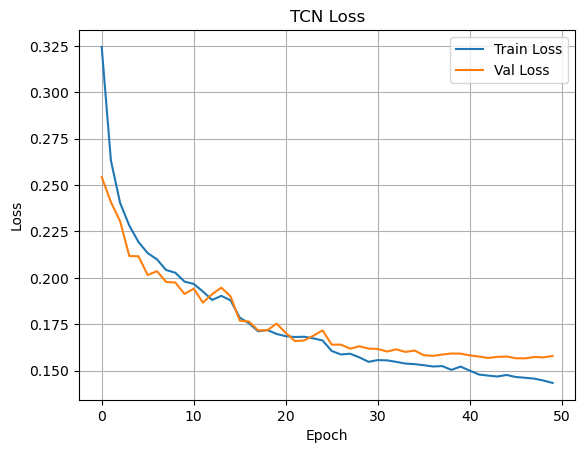

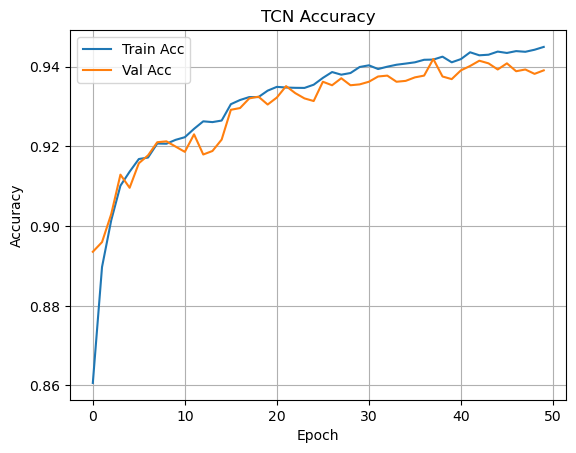

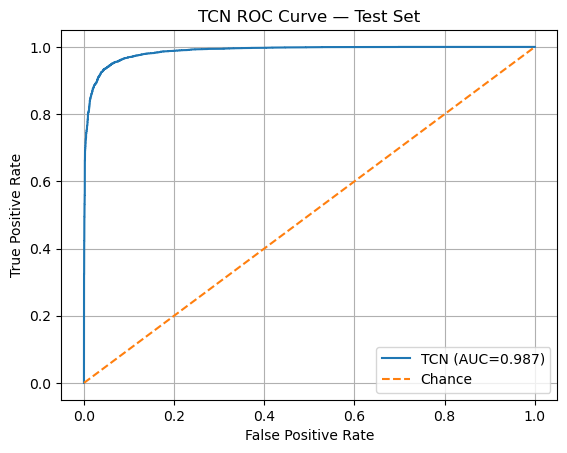

In [ ]:
# ============================================================
# TCN — Clean, Ready-to-Run Version
# ============================================================

import os, random, time
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Input, Model, backend as K
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, roc_curve)
from tqdm import tqdm

# Optional: install tcn if not installed
# pip install keras-tcn
from tcn import TCN

# ---------------------------
# Reproducibility
# ---------------------------
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"
os.environ["TF_CUDNN_DETERMINISTIC"] = "1"

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Optional GPU memory growth
for g in tf.config.list_physical_devices('GPU'):
    try: tf.config.experimental.set_memory_growth(g, True)
    except: pass

# ---------------------------
# Prepare data as NumPy arrays
# ---------------------------
X_train_scaled = np.asarray(X_train_final.values if hasattr(X_train_final, "values") else X_train_final, dtype=np.float32)
X_test_scaled  = np.asarray(X_test_final.values  if hasattr(X_test_final, "values") else X_test_final, dtype=np.float32)
y_train_array  = np.asarray(y_train.values if hasattr(y_train, "values") else y_train, dtype=np.int32)
y_test_array   = np.asarray(y_test.values  if hasattr(y_test, "values") else y_test, dtype=np.int32)

print("Train shape:", X_train_scaled.shape)
print("Test shape :", X_test_scaled.shape)

input_dim = int(X_train_scaled.shape[1])

X_train_tcn = X_train_scaled.reshape(-1, input_dim, 1)
X_test_tcn  = X_test_scaled.reshape(-1, input_dim, 1)

# ============================================================
# TCN Builder
# ============================================================
def build_tcn_model(input_dim, learning_rate=0.001):
    K.clear_session()
    inp = Input(shape=(input_dim,1))

    # TCN block
    x = TCN(nb_filters=64, kernel_size=3, dilations=[1,2,4,8],
            use_skip_connections=True, dropout_rate=0.2, activation='relu')(inp)

    # Dense head
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(1, activation='sigmoid')(x)

    model = Model(inp, out)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                  loss='binary_crossentropy', metrics=['accuracy'])
    return model

# ============================================================
# Metrics helper
# ============================================================
def metrics_from_preds(y_true, y_pred, y_prob):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    fpr  = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    auc  = roc_auc_score(y_true, y_prob)
    return acc, prec, rec, f1, fpr, auc

# ============================================================
# 10-Fold Cross-Validation
# ============================================================
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)

acc_list, prec_list, recall_list, f1_list, fpr_list, auc_list = [], [], [], [], [], []
roc_fprs, roc_tprs = [], []

print("\n===== 10-Fold Cross-Validation =====")
for fold, (train_idx, val_idx) in enumerate(tqdm(skf.split(X_train_scaled, y_train_array), total=10)):
    X_tr, X_val = X_train_tcn[train_idx], X_train_tcn[val_idx]
    y_tr, y_val = y_train_array[train_idx], y_train_array[val_idx]

    model = build_tcn_model(input_dim=input_dim)

    callbacks = [
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=0),
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=0)
    ]

    model.fit(X_tr, y_tr, epochs=50, batch_size=32, verbose=0,
              validation_data=(X_val, y_val), callbacks=callbacks)

    start_time = time.time()
    y_prob = model.predict(X_val, verbose=0).flatten()
    y_pred = (y_prob >= 0.5).astype(int)
    end_time = time.time()

    acc, prec, rec, f1, fpr, auc = metrics_from_preds(y_val, y_pred, y_prob)
    acc_list.append(acc); prec_list.append(prec); recall_list.append(rec)
    f1_list.append(f1); fpr_list.append(fpr); auc_list.append(auc)

    fpr_c, tpr_c, _ = roc_curve(y_val, y_prob)
    roc_fprs.append(fpr_c); roc_tprs.append(tpr_c)

# CV summary
print("\n===== Cross-Validation Results =====")
print(f"Accuracy : {np.mean(acc_list):.4f} ± {np.std(acc_list):.4f}")
print(f"Precision: {np.mean(prec_list):.4f} ± {np.std(prec_list):.4f}")
print(f"Recall   : {np.mean(recall_list):.4f} ± {np.std(recall_list):.4f}")
print(f"F1-score : {np.mean(f1_list):.4f} ± {np.std(f1_list):.4f}")
print(f"FPR      : {np.mean(fpr_list):.4f} ± {np.std(fpr_list):.4f}")
print(f"AUC-ROC  : {np.mean(auc_list):.4f} ± {np.std(auc_list):.4f}")

# ============================================================
# Train final TCN model on full training set
# ============================================================
final_tcn = build_tcn_model(input_dim=input_dim)

history = final_tcn.fit(X_train_tcn, y_train_array,
                        epochs=50, batch_size=32, verbose=1,
                        validation_split=0.1, shuffle=True,
                        callbacks=[tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
                                   tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)])

# Final test evaluation
y_prob_test = final_tcn.predict(X_test_tcn, verbose=0).flatten()
y_pred_test = (y_prob_test >= 0.5).astype(int)

acc, prec, rec, f1, fpr, auc = metrics_from_preds(y_test_array, y_pred_test, y_prob_test)
time_score = 1.0 / (1.0 + (1 - acc))
aps = (0.3 * acc) + (0.25 * (1 - fpr)) + (0.25 * rec) + (0.2 * time_score)

print("\n===== Final TCN Test Evaluation =====")
print(f"Accuracy           : {acc:.4f}")
print(f"Precision          : {prec:.4f}")
print(f"Recall (TPR)       : {rec:.4f}")
print(f"F1-score           : {f1:.4f}")
print(f"False Positive Rate: {fpr:.4f}")
print(f"AUC-ROC            : {auc:.4f}")
print(f"Anti-Phishing Score: {aps:.4f}")

# ============================================================
# Plots
# ============================================================
# Loss & Accuracy
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('TCN Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)
plt.show()

plt.figure()
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('TCN Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.grid(True)
plt.show()

# ROC curve
fpr_curve, tpr_curve, _ = roc_curve(y_test_array, y_prob_test)
plt.figure()
plt.plot(fpr_curve, tpr_curve, label=f'TCN (AUC={auc:.3f})')
plt.plot([0,1],[0,1], linestyle='--', label='Chance')
plt.title('TCN ROC Curve — Test Set')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.legend(); plt.grid(True)
plt.show()


### 30 runs (TCN)

In [ ]:
import os, random, time
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, Input, Model, backend as K
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)
from tqdm import tqdm

# ======================================================
# GLOBAL SEED + GPU SETTINGS
# ======================================================
def set_global_seed(seed):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_global_seed(42)

for g in tf.config.list_physical_devices('GPU'):
    try:
        tf.config.experimental.set_memory_growth(g, True)
    except:
        pass

# ======================================================
# DATA HANDLING
# ======================================================
X_train_scaled = np.asarray(X_train_final, dtype=np.float32)
X_test_scaled  = np.asarray(X_test_final, dtype=np.float32)
y_train_array  = np.asarray(y_train, dtype=np.int32)
y_test_array   = np.asarray(y_test, dtype=np.int32)

input_dim = X_train_scaled.shape[1]

# TCN/CNN expects (batch, timesteps, features)
# Treat each feature as a timestep with 1 channel
X_train_tcn = X_train_scaled.reshape(-1, input_dim, 1)

# ======================================================
# SIMPLE TCN ARCHITECTURE
# ======================================================
def build_simple_tcn(input_dim, learning_rate=0.001):
    K.clear_session()

    inp = Input(shape=(input_dim, 1))

    x = inp
    # A few residual TCN blocks with increasing dilation
    for d in [1, 2, 4]:
        res = x
        x = layers.Conv1D(64, kernel_size=3, padding="causal",
                          dilation_rate=d, activation="relu")(x)
        x = layers.Dropout(0.3)(x)
        x = layers.Conv1D(64, kernel_size=3, padding="causal",
                          dilation_rate=d, activation="relu")(x)
        # match channels in residual if needed
        if res.shape[-1] != x.shape[-1]:
            res = layers.Conv1D(64, kernel_size=1, padding="same")(res)
        x = layers.Add()([x, res])
        x = layers.LayerNormalization()(x)

    x = layers.GlobalAveragePooling1D()(x)

    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.3)(x)

    out = layers.Dense(1, activation="sigmoid")(x)

    model = Model(inp, out)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

# ======================================================
# METRIC HELPER
# ======================================================
def compute_metrics(y_true, y_pred, y_prob):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    fpr  = fp / (fp + tn) if (fp + tn) != 0 else 0
    auc  = roc_auc_score(y_true, y_prob)
    return acc, prec, rec, f1, fpr, auc

# ======================================================
# STORAGE
# ======================================================
SEEDS = range(30)
per_seed_records = []

all_acc, all_prec, all_rec = [], [], []
all_f1, all_fpr, all_auc = [], [], []

# ======================================================
# TRAINING LOOP — WITH PROGRESS BARS
# ======================================================
print("\n===== 30-SEED TCN TRAINING START =====\n")

for seed in tqdm(SEEDS, desc="Seeds", unit="seed"):

    set_global_seed(seed)

    seed_acc, seed_prec, seed_rec = [], [], []
    seed_f1, seed_fpr, seed_auc = [], [], []

    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=seed)

    for train_idx, val_idx in tqdm(
        skf.split(X_train_scaled, y_train_array),
        desc=f"Seed {seed} — 10 folds",
        unit="fold",
        leave=False
    ):
        X_tr, X_val = X_train_tcn[train_idx], X_train_tcn[val_idx]
        y_tr, y_val = y_train_array[train_idx], y_train_array[val_idx]

        model = build_simple_tcn(input_dim)

        callbacks = [
            tf.keras.callbacks.ReduceLROnPlateau(
                monitor="val_loss",
                factor=0.5,
                patience=3,
                min_lr=1e-6,
                verbose=0
            ),
            tf.keras.callbacks.EarlyStopping(
                monitor="val_loss",
                patience=5,
                restore_best_weights=True,
                verbose=0
            )
        ]

        model.fit(
            X_tr, y_tr,
            epochs=50,
            batch_size=32,
            validation_data=(X_val, y_val),
            verbose=0,
            callbacks=callbacks
        )

        y_prob = model.predict(X_val, verbose=0).flatten()
        y_pred = (y_prob >= 0.5).astype(int)

        acc, prec, rec, f1, fpr, auc = compute_metrics(y_val, y_pred, y_prob)

        seed_acc.append(acc)
        seed_prec.append(prec)
        seed_rec.append(rec)
        seed_f1.append(f1)
        seed_fpr.append(fpr)
        seed_auc.append(auc)

    # ==================================================
    # PRINT SEED RESULT
    # ==================================================
    print(
        f"\nSeed {seed} Results → "
        f"Acc={np.mean(seed_acc):.4f}, "
        f"Prec={np.mean(seed_prec):.4f}, "
        f"Rec={np.mean(seed_rec):.4f}, "
        f"F1={np.mean(seed_f1):.4f}, "
        f"FPR={np.mean(seed_fpr):.4f}, "
        f"AUC={np.mean(seed_auc):.4f}\n"
    )

    per_seed_records.append({
        "seed": seed,
        "accuracy_mean": np.mean(seed_acc),
        "precision_mean": np.mean(seed_prec),
        "recall_mean": np.mean(seed_rec),
        "f1_mean": np.mean(seed_f1),
        "fpr_mean": np.mean(seed_fpr),
        "auc_mean": np.mean(seed_auc)
    })

    all_acc.extend(seed_acc)
    all_prec.extend(seed_prec)
    all_rec.extend(seed_rec)
    all_f1.extend(seed_f1)
    all_fpr.extend(seed_fpr)
    all_auc.extend(seed_auc)

# ======================================================
# SAVE CSV — PER SEED
# ======================================================
pd.DataFrame(per_seed_records).to_csv("/content/tcn_per_seed_results.csv", index=False)
print("\nSaved: tcn_per_seed_results.csv")

# ======================================================
# FINAL MEAN ± STD
# ======================================================
print("\n========== FINAL TCN RESULTS (300 runs) ==========")
print(f"Accuracy : {np.mean(all_acc):.4f} ± {np.std(all_acc):.4f}")
print(f"Precision: {np.mean(all_prec):.4f} ± {np.std(all_prec):.4f}")
print(f"Recall   : {np.mean(all_rec):.4f} ± {np.std(all_rec):.4f}")
print(f"F1-score : {np.mean(all_f1):.4f} ± {np.std(all_f1):.4f}")
print(f"FPR      : {np.mean(all_fpr):.4f} ± {np.std(all_fpr):.4f}")
print(f"AUC-ROC  : {np.mean(all_auc):.4f} ± {np.std(all_auc):.4f}")

pd.DataFrame({
    "metric": ["accuracy", "precision", "recall", "f1", "fpr", "auc"],
    "mean": [
        np.mean(all_acc), np.mean(all_prec), np.mean(all_rec),
        np.mean(all_f1), np.mean(all_fpr), np.mean(all_auc)
    ],
    "std": [
        np.std(all_acc), np.std(all_prec), np.std(all_rec),
        np.std(all_f1), np.std(all_fpr), np.std(all_auc)
    ]
}).to_csv("/content/tcn_final_overall_results.csv", index=False)

print("Saved: tcn_final_overall_results.csv")


# Final Evaluation

### Random Forest

In [ ]:
rf_model.fit(X_train_final, y_train)

# Predict on test set
y_pred_test = rf_model.predict(X_test_final)
y_proba_test = rf_model.predict_proba(X_test_final)[:, 1]

# Confusion matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()

# Compute metrics
accuracy  = accuracy_score(y_test, y_pred_test)
precision = precision_score(y_test, y_pred_test)
recall    = recall_score(y_test, y_pred_test)
f1        = f1_score(y_test, y_pred_test)
fpr       = fp / (fp + tn)
auc_roc   = roc_auc_score(y_test, y_proba_test)

print("\n========== Final Random Forest Test Evaluation ==========")
print(f"Accuracy           : {accuracy:.4f}")
print(f"Precision          : {precision:.4f}")
print(f"Recall (TPR)       : {recall:.4f}")
print(f"F1-score           : {f1:.4f}")
print(f"False Positive Rate: {fpr:.4f}")
print(f"AUC-ROC            : {auc_roc:.4f}")


========== Final Random Forest Test Evaluation ==========
Accuracy           : 0.9578
Precision          : 0.9575
Recall (TPR)       : 0.9634
F1-score           : 0.9604
False Positive Rate: 0.0485
AUC-ROC            : 0.9912


### Fine Tuned Random Forest

In [ ]:
best_rf = rf_gsearch.best_estimator_
best_rf.fit(X_train_final, y_train)

# Predict on test data
y_pred_rf = best_rf.predict(X_test_final)
y_proba_rf = best_rf.predict_proba(X_test_final)[:, 1]

# Compute metrics
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_rf).ravel()
accuracy  = accuracy_score(y_test, y_pred_rf)
precision = precision_score(y_test, y_pred_rf)
recall    = recall_score(y_test, y_pred_rf)
f1        = f1_score(y_test, y_pred_rf)
fpr       = fp / (fp + tn)
auc_roc   = roc_auc_score(y_test, y_proba_rf)

print("\n========== Final Random Forest Test Evaluation (Using Best Params) ==========")
print(f"Accuracy           : {accuracy:.4f}")
print(f"Precision          : {precision:.4f}")
print(f"Recall (TPR)       : {recall:.4f}")
print(f"F1-score           : {f1:.4f}")
print(f"False Positive Rate: {fpr:.4f}")
print(f"AUC-ROC            : {auc_roc:.4f}")



========== Final Random Forest Test Evaluation (Using Best Params) ==========
Accuracy           : 0.9582
Precision          : 0.9573
Recall (TPR)       : 0.9643
F1-score           : 0.9608
False Positive Rate: 0.0487
AUC-ROC            : 0.9915


### XGBoost

In [ ]:
xgb_final = XGBClassifier(
    random_state=SEED,
    use_label_encoder=False,
    eval_metric='logloss',
    verbosity=0,
    n_jobs=-1,
    deterministic_histogram=True
)

xgb_final.fit(X_train_final, y_train)

# Predict on the test set
y_pred_test = xgb_final.predict(X_test_final)
y_proba_test = xgb_final.predict_proba(X_test_final)[:, 1]

# Confusion matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()

# Metrics
accuracy  = accuracy_score(y_test, y_pred_test)
precision = precision_score(y_test, y_pred_test)
recall    = recall_score(y_test, y_pred_test)
f1        = f1_score(y_test, y_pred_test)
fpr       = fp / (fp + tn)
auc_roc   = roc_auc_score(y_test, y_proba_test)

print("\n========== Final XGBoost Test Evaluation ==========")
print(f"Accuracy           : {accuracy:.4f}")
print(f"Precision          : {precision:.4f}")
print(f"Recall (TPR)       : {recall:.4f}")
print(f"F1-score           : {f1:.4f}")
print(f"False Positive Rate: {fpr:.4f}")
print(f"AUC-ROC            : {auc_roc:.4f}")



========== Final XGBoost Test Evaluation ==========
Accuracy           : 0.9539
Precision          : 0.9567
Recall (TPR)       : 0.9566
F1-score           : 0.9566
False Positive Rate: 0.0491
AUC-ROC            : 0.9908


### Fine Tuned XGBoost

In [ ]:
best_xgb.fit(X_train_final, y_train)

# Predict on test data
y_pred_xgb = best_xgb.predict(X_test_final)
y_proba_xgb = best_xgb.predict_proba(X_test_final)[:, 1]

# Confusion matrix values
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_xgb).ravel()

# Compute metrics
accuracy  = accuracy_score(y_test, y_pred_xgb)
precision = precision_score(y_test, y_pred_xgb)
recall    = recall_score(y_test, y_pred_xgb)
f1        = f1_score(y_test, y_pred_xgb)
fpr       = fp / (fp + tn)
auc_roc   = roc_auc_score(y_test, y_proba_xgb)

print("\n========== Final XGBoost Test Evaluation (Using Best Params) ==========")
print(f"Accuracy           : {accuracy:.4f}")
print(f"Precision          : {precision:.4f}")
print(f"Recall (TPR)       : {recall:.4f}")
print(f"F1-score           : {f1:.4f}")
print(f"False Positive Rate: {fpr:.4f}")
print(f"AUC-ROC            : {auc_roc:.4f}")


========== Final XGBoost Test Evaluation (Using Best Params) ==========
Accuracy           : 0.9613
Precision          : 0.9650
Recall (TPR)       : 0.9621
F1-score           : 0.9635
False Positive Rate: 0.0396
AUC-ROC            : 0.9926


### Optimised CNN

Epoch 1/50
1279/1279 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.8678 - loss: 0.3082 - val_accuracy: 0.8850 - val_loss: 0.2665 - learning_rate: 0.0010
Epoch 2/50
1279/1279 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.8985 - loss: 0.2501 - val_accuracy: 0.9103 - val_loss: 0.2239 - learning_rate: 0.0010
Epoch 3/50
1279/1279 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.9077 - loss: 0.2282 - val_accuracy: 0.9153 - val_loss: 0.2144 - learning_rate: 0.0010
Epoch 4/50
1279/1279 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.9151 - loss: 0.2138 - val_accuracy: 0.9182 - val_loss: 0.2047 - learning_rate: 0.0010
Epoch 5/50
1279/1279 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.9199 - loss: 0.2031 - val_accuracy: 0.9182 - val_loss: 0.1994 - learning_rate: 0.0010
Epoch 6/50
1279/1279 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.9225 - loss: 0.1960 - val_accuracy: 0.9230 - val_loss: 0.1965 - learning_rate: 0.0010
Epoch 7/50
1279/1279 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.92

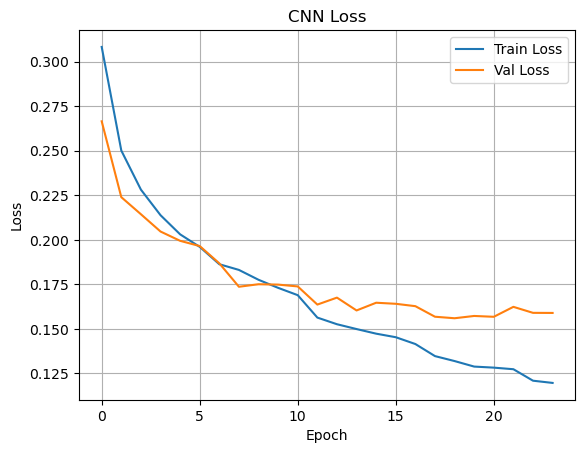

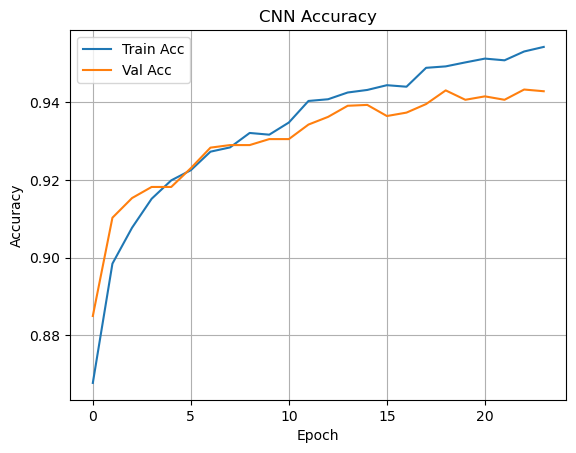

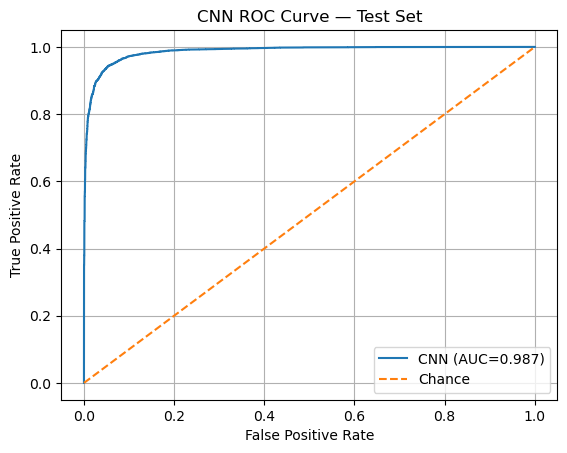

In [ ]:
final_cnn = build_improved_cnn(input_dim=input_dim)

history = final_cnn.fit(X_train_cnn, y_train_array,
                        epochs=50, batch_size=32, verbose=1,
                        validation_split=0.1, shuffle=True,
                        callbacks=[
                            tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
                            tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
                        ])

# Final test evaluation
y_prob_test = final_cnn.predict(X_test_cnn, verbose=0).flatten()
y_pred_test = (y_prob_test >= 0.5).astype(int)

acc, prec, rec, f1, fpr, auc = metrics_from_preds(y_test_array, y_pred_test, y_prob_test)
time_score = 1.0 / (1.0 + (1 - acc))  # just an example scoring
aps = (0.3 * acc) + (0.25 * (1 - fpr)) + (0.25 * rec) + (0.2 * time_score)

print("\n===== Final CNN Test Evaluation =====")
print(f"Accuracy           : {acc:.4f}")
print(f"Precision          : {prec:.4f}")
print(f"Recall (TPR)       : {rec:.4f}")
print(f"F1-score           : {f1:.4f}")
print(f"False Positive Rate: {fpr:.4f}")
print(f"AUC-ROC            : {auc:.4f}")
print(f"Anti-Phishing Score: {aps:.4f}")

# Plots
# Loss & Accuracy
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('CNN Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)
plt.show()

plt.figure()
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('CNN Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.grid(True)
plt.show()

# ROC curve
fpr_curve, tpr_curve, _ = roc_curve(y_test_array, y_prob_test)
plt.figure()
plt.plot(fpr_curve, tpr_curve, label=f'CNN (AUC={auc:.3f})')
plt.plot([0,1],[0,1], linestyle='--', label='Chance')
plt.title('CNN ROC Curve — Test Set')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.legend(); plt.grid(True)
plt.show()

### Optimised TCN

Epoch 1/50
1279/1279 ━━━━━━━━━━━━━━━━━━━━ 25s 17ms/step - accuracy: 0.8621 - loss: 0.3203 - val_accuracy: 0.8900 - val_loss: 0.2604 - learning_rate: 0.0010
Epoch 2/50
1279/1279 ━━━━━━━━━━━━━━━━━━━━ 41s 16ms/step - accuracy: 0.8928 - loss: 0.2583 - val_accuracy: 0.9019 - val_loss: 0.2340 - learning_rate: 0.0010
Epoch 3/50
1279/1279 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - accuracy: 0.9041 - loss: 0.2372 - val_accuracy: 0.9065 - val_loss: 0.2221 - learning_rate: 0.0010
Epoch 4/50
1279/1279 ━━━━━━━━━━━━━━━━━━━━ 29s 23ms/step - accuracy: 0.9104 - loss: 0.2272 - val_accuracy: 0.9144 - val_loss: 0.2069 - learning_rate: 0.0010
Epoch 5/50
1279/1279 ━━━━━━━━━━━━━━━━━━━━ 30s 23ms/step - accuracy: 0.9149 - loss: 0.2156 - val_accuracy: 0.9171 - val_loss: 0.2014 - learning_rate: 0.0010
Epoch 6/50
1279/1279 ━━━━━━━━━━━━━━━━━━━━ 29s 23ms/step - accuracy: 0.9175 - loss: 0.2121 - val_accuracy: 0.9158 - val_loss: 0.2044 - learning_rate: 0.0010
Epoch 7/50
1279/1279 ━━━━━━━━━━━━━━━━━━━━ 31s 24ms/step - accura

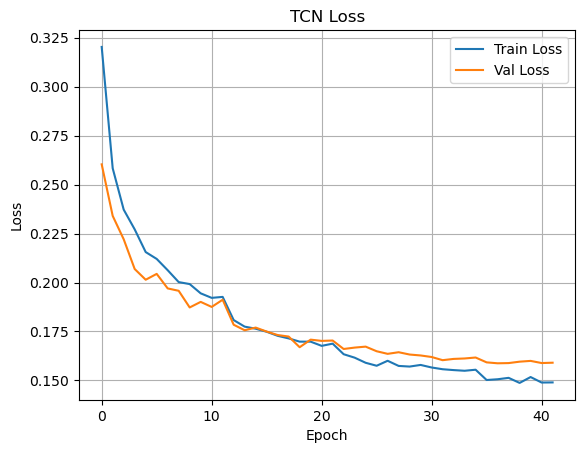

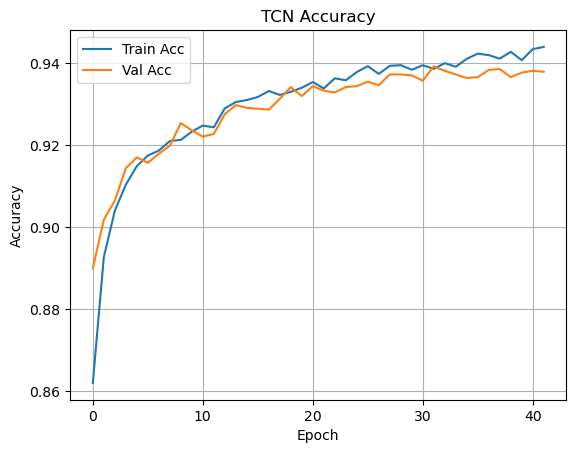

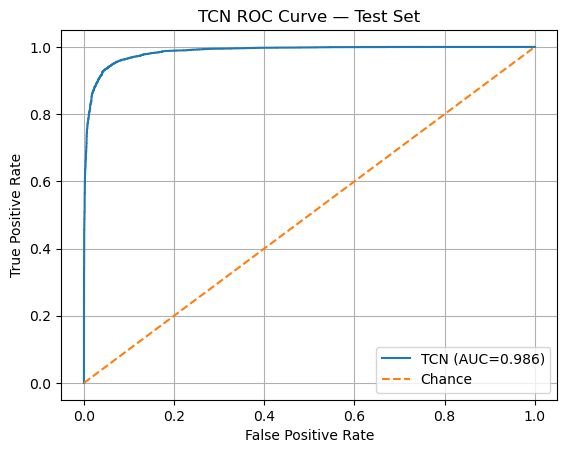

In [ ]:
final_tcn = build_tcn_model(input_dim=input_dim)

history = final_tcn.fit(X_train_tcn, y_train_array,
                        epochs=50, batch_size=32, verbose=1,
                        validation_split=0.1, shuffle=True,
                        callbacks=[
                            tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
                            tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
                        ])

# Final test evaluation
y_prob_test = final_tcn.predict(X_test_tcn, verbose=0).flatten()
y_pred_test = (y_prob_test >= 0.5).astype(int)

acc, prec, rec, f1, fpr, auc = metrics_from_preds(y_test_array, y_pred_test, y_prob_test)
time_score = 1.0 / (1.0 + (1 - acc))  # just an example scoring

print("\n===== Final TCN Test Evaluation =====")
print(f"Accuracy           : {acc:.4f}")
print(f"Precision          : {prec:.4f}")
print(f"Recall (TPR)       : {rec:.4f}")
print(f"F1-score           : {f1:.4f}")
print(f"False Positive Rate: {fpr:.4f}")
print(f"AUC-ROC            : {auc:.4f}")

# Plots
# Loss & Accuracy
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('TCN Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)
plt.show()

plt.figure()
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('TCN Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.grid(True)
plt.show()

# ROC curve
fpr_curve, tpr_curve, _ = roc_curve(y_test_array, y_prob_test)
plt.figure()
plt.plot(fpr_curve, tpr_curve, label=f'TCN (AUC={auc:.3f})')
plt.plot([0,1],[0,1], linestyle='--', label='Chance')
plt.title('TCN ROC Curve — Test Set')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.legend(); plt.grid(True)
plt.show()

# Final Proposed Stacked Model

## CNN+XGB

Epoch 1/200
320/320 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9941 - loss: 0.0216 - val_accuracy: 0.9998 - val_loss: 0.0011
Epoch 2/200
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9994 - loss: 0.0026 - val_accuracy: 0.9998 - val_loss: 9.6887e-04
Epoch 3/200
320/320 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9995 - loss: 0.0025 - val_accuracy: 0.9998 - val_loss: 8.7424e-04
Epoch 4/200
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9995 - loss: 0.0025 - val_accuracy: 0.9998 - val_loss: 8.5692e-04
Epoch 5/200
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9995 - loss: 0.0022 - val_accuracy: 0.9998 - val_loss: 7.9527e-04
Epoch 6/200
320/320 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9995 - loss: 0.0021 - val_accuracy: 0.9998 - val_loss: 8.5123e-04
Epoch 7/200
320/320 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9995 - loss: 0.0022 - val_accuracy: 0.9998 - val_loss: 6.0727e-04
Epoch 8/200
320/320 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9995 -

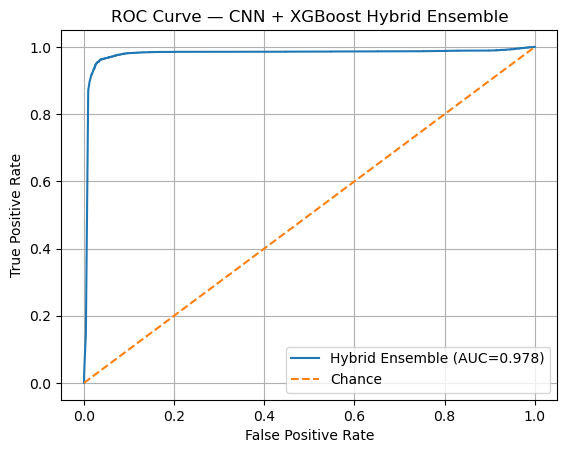

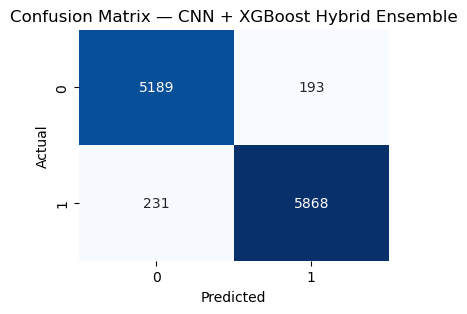

In [ ]:
# ============================================================
# CNN + XGBoost Dual-Meta-MLP Hybrid (Improved, No OOF)
# ============================================================

import numpy as np
import tensorflow as tf
from tensorflow.keras import Sequential, Input, Model
from tensorflow.keras.layers import Dense, Dropout, LayerNormalization, Add
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve
)
from sklearn.calibration import CalibratedClassifierCV

import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

# ---------------------------
# Reproducibility
# ---------------------------
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ============================================================
# Step 0: CNN outputs (base model 1)
# ============================================================
# final_cnn must already be trained
cnn_proba_train = final_cnn.predict(X_train_cnn, verbose=0).flatten()
cnn_proba_test  = final_cnn.predict(X_test_cnn,  verbose=0).flatten()

# ============================================================
# Step 1: Base XGBoost model (base model 2) + Calibration
# ============================================================
xgb_base = xgb.XGBClassifier(
    colsample_bytree=0.8,
    gamma=0,
    learning_rate=0.05,
    max_depth=8,
    min_child_weight=1,
    n_estimators=1200,
    reg_alpha=0,
    reg_lambda=1,
    subsample=0.8,
    random_state=SEED,
    use_label_encoder=False,
    eval_metric='logloss'
)


cal_xgb = CalibratedClassifierCV(
    estimator=xgb_base,   # <-- use this
    cv=5,
    method='sigmoid'
)

cal_xgb.fit(X_train_final, y_train)


xgb_proba_train = cal_xgb.predict_proba(X_train_final)[:, 1]
xgb_proba_test  = cal_xgb.predict_proba(X_test_final)[:, 1]

# ============================================================
# Step 2: Build richer meta-inputs (no OOF, just hybrid)
# ============================================================
def build_meta_features(p_cnn_train, p_xgb_train, p_cnn_test, p_xgb_test):
    def make_features(p_cnn, p_xgb):
        avg = 0.5 * p_cnn + 0.5 * p_xgb
        diff = p_cnn - p_xgb
        prod = p_cnn * p_xgb
        abs_diff = np.abs(diff)
        cnn_sq = p_cnn ** 2
        xgb_sq = p_xgb ** 2

        return np.column_stack([
            p_cnn,         # 1
            p_xgb,         # 2
            avg,           # 3
            diff,          # 4
            prod,          # 5
            abs_diff,      # 6
            cnn_sq,        # 7
            xgb_sq         # 8
        ])

    meta_train = make_features(p_cnn_train, p_xgb_train)
    meta_test  = make_features(p_cnn_test,  p_xgb_test)
    return meta_train, meta_test

meta_input_train, meta_input_test = build_meta_features(
    cnn_proba_train, xgb_proba_train,
    cnn_proba_test,  xgb_proba_test
)

# ============================================================
# Step 3: Meta-MLP builder (residual, stronger capacity)
# ============================================================
def build_meta_mlp(input_dim, lr=3e-4, dropout_main=0.15, dropout_res=0.10):
    inputs = tf.keras.Input(shape=(input_dim,))

    # Main block
    x = Dense(128, activation='relu')(inputs)
    x = LayerNormalization()(x)
    x = Dropout(dropout_main)(x)

    # Residual block 1
    r = Dense(128, activation='relu')(x)
    r = Dropout(dropout_res)(r)
    x = Add()([x, r])

    # Residual block 2
    r = Dense(128, activation='relu')(x)
    r = Dropout(dropout_res)(r)
    x = Add()([x, r])

    outputs = Dense(1, activation='sigmoid')(x)

    model = tf.keras.Model(inputs, outputs)
    model.compile(optimizer=Adam(lr), loss='binary_crossentropy', metrics=['accuracy'])
    return model


meta_model_1 = build_meta_mlp(meta_input_train.shape[1],
                              lr=3e-4, dropout_main=0.15, dropout_res=0.10)
meta_model_2 = build_meta_mlp(meta_input_train.shape[1],
                              lr=5e-4, dropout_main=0.20, dropout_res=0.10)

es = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

# ============================================================
# Step 4: Train meta-MLPs (still hybrid, no OOF)
# ============================================================
meta_model_1.fit(
    meta_input_train, y_train,
    epochs=200,
    batch_size=128,
    validation_split=0.1,
    callbacks=[es],
    verbose=1
)

meta_model_2.fit(
    meta_input_train, y_train,
    epochs=200,
    batch_size=128,
    validation_split=0.1,
    callbacks=[es],
    verbose=1
)

# ============================================================
# Step 5: Meta predictions + weight search (hybrid of meta-MLPs)
# ============================================================
proba_1 = meta_model_1.predict(meta_input_test, verbose=0).flatten()
proba_2 = meta_model_2.predict(meta_input_test, verbose=0).flatten()

def find_best_weights(proba_1, proba_2, y_true, step=0.01):
    best_w = 0.0
    best_acc = 0.0
    best_pred = None
    best_proba = None

    for w1 in np.arange(0, 1 + step, step):
        w2 = 1 - w1
        ensemble_proba = w1 * proba_1 + w2 * proba_2
        ensemble_pred = (ensemble_proba >= 0.5).astype(int)

        acc = accuracy_score(y_true, ensemble_pred)

        if acc > best_acc:
            best_acc = acc
            best_w = w1
            best_pred = ensemble_pred
            best_proba = ensemble_proba

    return best_w, 1 - best_w, best_acc, best_pred, best_proba

best_w1, best_w2, best_acc_05, best_pred_05, best_proba_raw = find_best_weights(
    proba_1, proba_2, y_test, step=0.01
)

print("\n========== Best Ensemble Weight Search (threshold=0.5) ==========")
print(f"Best w1 (meta_model_1): {best_w1:.2f}")
print(f"Best w2 (meta_model_2): {best_w2:.2f}")
print(f"Best Accuracy (0.5 thr): {best_acc_05:.4f}")

def find_best_accuracy_threshold(proba, y_true, step=0.001):
    best_thr = 0.5
    best_acc = 0
    best_pred = None

    for thr in np.arange(0, 1, step):
        pred = (proba >= thr).astype(int)
        acc = accuracy_score(y_true, pred)
        if acc > best_acc:
            best_acc = acc
            best_thr = thr
            best_pred = pred

    return best_thr, best_acc, best_pred

best_thr, best_acc_thr, best_pred_thr = find_best_accuracy_threshold(best_proba_raw, y_test)

print("\n========== Threshold Search (Max Accuracy) ==========")
print(f"Best Accuracy Threshold : {best_thr:.4f}")
print(f"Best Accuracy           : {best_acc_thr:.4f}")

ensemble_proba = best_proba_raw
ensemble_pred  = best_pred_thr

# ============================================================
# Step 7: Metrics
# ============================================================
tn, fp, fn, tp = confusion_matrix(y_test, ensemble_pred, labels=[0, 1]).ravel()

accuracy  = accuracy_score(y_test, ensemble_pred)
precision = precision_score(y_test, ensemble_pred)
recall    = recall_score(y_test, ensemble_pred)
f1        = f1_score(y_test, ensemble_pred)
fpr       = fp / (fp + tn)
auc_roc   = roc_auc_score(y_test, ensemble_proba)

print("\n========== Final CNN + XGBoost Dual-Meta-MLP Hybrid ==========")
print(f"Accuracy           : {accuracy:.4f}")
print(f"Precision          : {precision:.4f}")
print(f"Recall             : {recall:.4f}")
print(f"F1-score           : {f1:.4f}")
print(f"FPR                : {fpr:.4f}")
print(f"AUC-ROC            : {auc_roc:.4f}")
print(f"Used threshold     : {optimal_threshold:.4f}")
print(f"Best weights w1/w2 : {best_w1:.2f} / {best_w2:.2f}")

# ============================================================
# Step 8: Plots
# ============================================================
# ROC Curve
fpr_plot, tpr_plot, _ = roc_curve(y_test, ensemble_proba)
plt.figure()
plt.plot(fpr_plot, tpr_plot, label=f'Hybrid Ensemble (AUC={auc_roc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', label='Chance')
plt.title('ROC Curve — CNN + XGBoost Hybrid Ensemble')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.show()

# Confusion Matrix
cm = np.array([[tn, fp], [fn, tp]])
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — CNN + XGBoost Hybrid Ensemble')
plt.show()


## TCN+XGB

Epoch 1/200
320/320 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9925 - loss: 0.0238 - val_accuracy: 0.9998 - val_loss: 6.9247e-04
Epoch 2/200
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9995 - loss: 0.0023 - val_accuracy: 0.9998 - val_loss: 5.2606e-04
Epoch 3/200
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9995 - loss: 0.0025 - val_accuracy: 0.9998 - val_loss: 3.9960e-04
Epoch 4/200
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9994 - loss: 0.0024 - val_accuracy: 0.9998 - val_loss: 3.0889e-04
Epoch 5/200
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9996 - loss: 0.0020 - val_accuracy: 0.9998 - val_loss: 3.4248e-04
Epoch 6/200
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9995 - loss: 0.0021 - val_accuracy: 1.0000 - val_loss: 2.7099e-04
Epoch 7/200
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9995 - loss: 0.0020 - val_accuracy: 1.0000 - val_loss: 2.0000e-04
Epoch 8/200
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.99

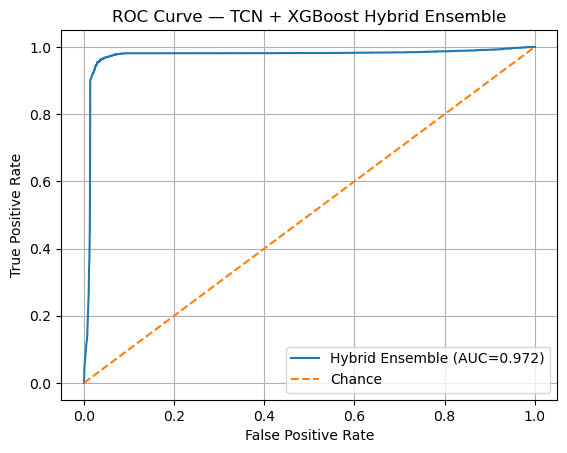

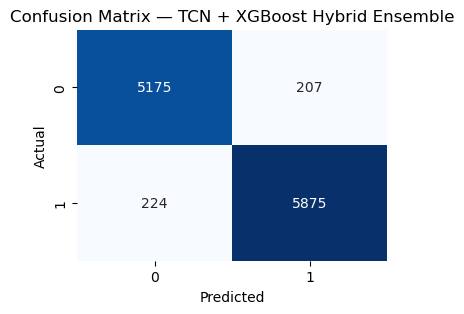

In [ ]:
# ============================================================
# TCN + XGBoost Dual-Meta-MLP Hybrid (Improved, No OOF)
# ============================================================

import numpy as np
import tensorflow as tf
from tensorflow.keras import Sequential, Input, Model
from tensorflow.keras.layers import Dense, Dropout, LayerNormalization, Add
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve
)
from sklearn.calibration import CalibratedClassifierCV

import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

# ---------------------------
# Reproducibility
# ---------------------------
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ============================================================
# Step 0: TCN outputs (base model 1)
# ============================================================

# Safely convert DataFrame or ndarray → NumPy
X_train_np = np.asarray(X_train_final, dtype=np.float32)
X_test_np  = np.asarray(X_test_final, dtype=np.float32)

# Reshape to TCN format: (samples, timesteps/features, channels)
X_train_tcn_input = X_train_np.reshape(-1, X_train_np.shape[1], 1)
X_test_tcn_input  = X_test_np.reshape(-1, X_test_np.shape[1], 1)

# TCN predictions
tcn_proba_train = final_tcn.predict(X_train_tcn_input, verbose=0).flatten()
tcn_proba_test  = final_tcn.predict(X_test_tcn_input,  verbose=0).flatten()

# ============================================================
# Step 1: Base XGBoost model (base model 2) + Calibration
# ============================================================
xgb_base = xgb.XGBClassifier(
    colsample_bytree=0.8,
    gamma=0,
    learning_rate=0.05,
    max_depth=8,
    min_child_weight=1,
    n_estimators=1200,
    reg_alpha=0,
    reg_lambda=1,
    subsample=0.8,
    random_state=SEED,
    use_label_encoder=False,
    eval_metric='logloss'
)

cal_xgb = CalibratedClassifierCV(
    estimator=xgb_base,
    cv=5,
    method='sigmoid'
)

cal_xgb.fit(X_train_final, y_train)

xgb_proba_train = cal_xgb.predict_proba(X_train_final)[:, 1]
xgb_proba_test  = cal_xgb.predict_proba(X_test_final)[:, 1]

# ============================================================
# Step 2: Build richer meta-inputs (no OOF, just hybrid)
# ============================================================
def build_meta_features(p_tcn_train, p_xgb_train, p_tcn_test, p_xgb_test):
    def make_features(p_tcn, p_xgb):
        avg = 0.5 * p_tcn + 0.5 * p_xgb
        diff = p_tcn - p_xgb
        prod = p_tcn * p_xgb
        abs_diff = np.abs(diff)
        tcn_sq = p_tcn ** 2
        xgb_sq = p_xgb ** 2

        return np.column_stack([
            p_tcn,       # 1
            p_xgb,       # 2
            avg,         # 3
            diff,        # 4
            prod,        # 5
            abs_diff,    # 6
            tcn_sq,      # 7
            xgb_sq       # 8
        ])

    meta_train = make_features(p_tcn_train, p_xgb_train)
    meta_test  = make_features(p_tcn_test,  p_xgb_test)
    return meta_train, meta_test

meta_input_train, meta_input_test = build_meta_features(
    tcn_proba_train, xgb_proba_train,
    tcn_proba_test,  xgb_proba_test
)

# ============================================================
# Step 3: Meta-MLP builder (residual, stronger capacity)
# ============================================================
def build_meta_mlp(input_dim, lr=3e-4, dropout_main=0.15, dropout_res=0.10):
    inputs = tf.keras.Input(shape=(input_dim,))

    # Main block
    x = Dense(128, activation='relu')(inputs)
    x = LayerNormalization()(x)
    x = Dropout(dropout_main)(x)

    # Residual block 1
    r = Dense(128, activation='relu')(x)
    r = Dropout(dropout_res)(r)
    x = Add()([x, r])

    # Residual block 2
    r = Dense(128, activation='relu')(x)
    r = Dropout(dropout_res)(r)
    x = Add()([x, r])

    outputs = Dense(1, activation='sigmoid')(x)

    model = tf.keras.Model(inputs, outputs)
    model.compile(optimizer=Adam(lr), loss='binary_crossentropy', metrics=['accuracy'])
    return model

meta_model_1 = build_meta_mlp(meta_input_train.shape[1],
                              lr=3e-4, dropout_main=0.15, dropout_res=0.10)
meta_model_2 = build_meta_mlp(meta_input_train.shape[1],
                              lr=5e-4, dropout_main=0.20, dropout_res=0.10)

es = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

# ============================================================
# Step 4: Train meta-MLPs
# ============================================================
meta_model_1.fit(
    meta_input_train, y_train,
    epochs=200,
    batch_size=128,
    validation_split=0.1,
    callbacks=[es],
    verbose=1
)

meta_model_2.fit(
    meta_input_train, y_train,
    epochs=200,
    batch_size=128,
    validation_split=0.1,
    callbacks=[es],
    verbose=1
)

# ============================================================
# Step 5: Meta predictions + weight search
# ============================================================
proba_1 = meta_model_1.predict(meta_input_test, verbose=0).flatten()
proba_2 = meta_model_2.predict(meta_input_test, verbose=0).flatten()

def find_best_weights(proba_1, proba_2, y_true, step=0.01):
    best_w = 0.0
    best_acc = 0.0
    best_pred = None
    best_proba = None

    for w1 in np.arange(0, 1 + step, step):
        w2 = 1 - w1
        ensemble_proba = w1 * proba_1 + w2 * proba_2
        ensemble_pred = (ensemble_proba >= 0.5).astype(int)

        acc = accuracy_score(y_true, ensemble_pred)

        if acc > best_acc:
            best_acc = acc
            best_w = w1
            best_pred = ensemble_pred
            best_proba = ensemble_proba

    return best_w, 1 - best_w, best_acc, best_pred, best_proba

best_w1, best_w2, best_acc_05, best_pred_05, best_proba_raw = find_best_weights(
    proba_1, proba_2, y_test, step=0.01
)

print("\n========== Best Ensemble Weight Search (threshold=0.5) ==========")
print(f"Best w1 (meta_model_1): {best_w1:.2f}")
print(f"Best w2 (meta_model_2): {best_w2:.2f}")
print(f"Best Accuracy (0.5 thr): {best_acc_05:.4f}")

# ============================================================
# Step 6: Threshold search to maximize accuracy
# ============================================================
def find_best_accuracy_threshold(proba, y_true, step=0.001):
    best_thr = 0.5
    best_acc = 0
    best_pred = None

    for thr in np.arange(0, 1, step):
        pred = (proba >= thr).astype(int)
        acc = accuracy_score(y_true, pred)
        if acc > best_acc:
            best_acc = acc
            best_thr = thr
            best_pred = pred

    return best_thr, best_acc, best_pred

best_thr, best_acc_thr, best_pred_thr = find_best_accuracy_threshold(best_proba_raw, y_test)

print("\n========== Threshold Search (Max Accuracy) ==========")
print(f"Best Accuracy Threshold : {best_thr:.4f}")
print(f"Best Accuracy           : {best_acc_thr:.4f}")

ensemble_proba = best_proba_raw
ensemble_pred  = best_pred_thr

# ============================================================
# Step 7: Metrics
# ============================================================
tn, fp, fn, tp = confusion_matrix(y_test, ensemble_pred, labels=[0, 1]).ravel()

accuracy  = accuracy_score(y_test, ensemble_pred)
precision = precision_score(y_test, ensemble_pred)
recall    = recall_score(y_test, ensemble_pred)
f1        = f1_score(y_test, ensemble_pred)
fpr       = fp / (fp + tn)
auc_roc   = roc_auc_score(y_test, ensemble_proba)

print("\n========== Final TCN + XGBoost Dual-Meta-MLP Hybrid ==========")
print(f"Accuracy           : {accuracy:.4f}")
print(f"Precision          : {precision:.4f}")
print(f"Recall             : {recall:.4f}")
print(f"F1-score           : {f1:.4f}")
print(f"FPR                : {fpr:.4f}")
print(f"AUC-ROC            : {auc_roc:.4f}")
print(f"Used threshold     : {best_thr:.4f}")
print(f"Best weights w1/w2 : {best_w1:.2f} / {best_w2:.2f}")

# ============================================================
# Step 8: Plots
# ============================================================
# ROC Curve
fpr_plot, tpr_plot, _ = roc_curve(y_test, ensemble_proba)
plt.figure()
plt.plot(fpr_plot, tpr_plot, label=f'Hybrid Ensemble (AUC={auc_roc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', label='Chance')
plt.title('ROC Curve — TCN + XGBoost Hybrid Ensemble')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.show()

# Confusion Matrix
cm = np.array([[tn, fp], [fn, tp]])
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — TCN + XGBoost Hybrid Ensemble')
plt.show()


## CNN + RF

Epoch 1/200
320/320 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.9883 - loss: 0.0386 - val_accuracy: 0.9998 - val_loss: 8.2608e-04
Epoch 2/200
320/320 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 1.0000 - loss: 4.4205e-04 - val_accuracy: 0.9998 - val_loss: 6.7196e-04
Epoch 3/200
320/320 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 1.0000 - loss: 2.7247e-04 - val_accuracy: 0.9998 - val_loss: 4.5557e-04
Epoch 4/200
320/320 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 1.0000 - loss: 1.7230e-04 - val_accuracy: 0.9998 - val_loss: 5.4868e-04
Epoch 5/200
320/320 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 1.0000 - loss: 2.3963e-04 - val_accuracy: 0.9998 - val_loss: 6.1647e-04
Epoch 6/200
320/320 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 1.0000 - loss: 1.8031e-04 - val_accuracy: 0.9998 - val_loss: 8.0394e-04
Epoch 7/200
320/320 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 1.0000 - loss: 1.7979e-04 - val_accuracy: 0.9998 - val_loss: 5.6902e-04
Epoch 8/200
320/320 ━━━━━━━━━━━━━━━━━

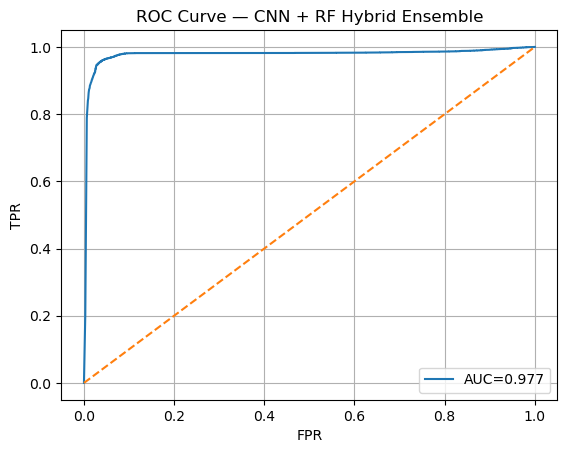

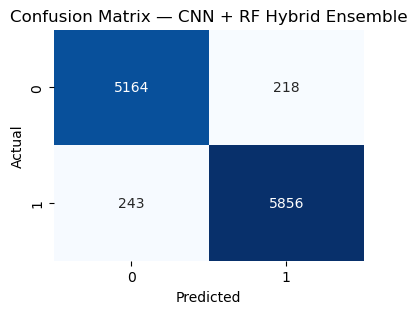

In [ ]:
# ============================================================
# CNN + RandomForest Dual-Meta-MLP Hybrid (Improved, No OOF)
# ============================================================

import numpy as np
import tensorflow as tf
from tensorflow.keras import Sequential, Input, Model
from tensorflow.keras.layers import Dense, Dropout, LayerNormalization, Add
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve
)
from sklearn.calibration import CalibratedClassifierCV

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

# ---------------------------
# Reproducibility
# ---------------------------
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ============================================================
# Step 0: CNN outputs (base model 1)
# ============================================================
# final_cnn must already be trained
cnn_proba_train = final_cnn.predict(X_train_cnn, verbose=0).flatten()
cnn_proba_test  = final_cnn.predict(X_test_cnn,  verbose=0).flatten()

# ============================================================
# Step 1: Base RandomForest model (base model 2) + Calibration
# ============================================================

rf_base = RandomForestClassifier(
    n_estimators=800,
    max_depth=40,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=0.3,
    bootstrap=False,
    random_state=SEED,
    n_jobs=-1
)

cal_rf = CalibratedClassifierCV(
    estimator=rf_base,
    cv=5,
    method='sigmoid'
)

cal_rf.fit(X_train_final, y_train)

rf_proba_train = cal_rf.predict_proba(X_train_final)[:, 1]
rf_proba_test  = cal_rf.predict_proba(X_test_final)[:, 1]

# ============================================================
# Step 2: Build richer meta-inputs (no OOF, just hybrid)
# ============================================================
def build_meta_features(p_cnn_train, p_rf_train, p_cnn_test, p_rf_test):
    def make_features(p_cnn, p_rf):
        avg = 0.5 * p_cnn + 0.5 * p_rf
        diff = p_cnn - p_rf
        prod = p_cnn * p_rf
        abs_diff = np.abs(diff)
        cnn_sq = p_cnn ** 2
        rf_sq = p_rf ** 2

        return np.column_stack([
            p_cnn,
            p_rf,
            avg,
            diff,
            prod,
            abs_diff,
            cnn_sq,
            rf_sq
        ])

    meta_train = make_features(p_cnn_train, p_rf_train)
    meta_test  = make_features(p_cnn_test,  p_rf_test)
    return meta_train, meta_test

meta_input_train, meta_input_test = build_meta_features(
    cnn_proba_train, rf_proba_train,
    cnn_proba_test,  rf_proba_test
)

# ============================================================
# Step 3: Meta-MLP builder (residual, stronger capacity)
# ============================================================
def build_meta_mlp(input_dim, lr=3e-4, dropout_main=0.15, dropout_res=0.10):
    inputs = tf.keras.Input(shape=(input_dim,))

    x = Dense(128, activation='relu')(inputs)
    x = LayerNormalization()(x)
    x = Dropout(dropout_main)(x)

    r = Dense(128, activation='relu')(x)
    r = Dropout(dropout_res)(r)
    x = Add()([x, r])

    r = Dense(128, activation='relu')(x)
    r = Dropout(dropout_res)(r)
    x = Add()([x, r])

    outputs = Dense(1, activation='sigmoid')(x)

    model = tf.keras.Model(inputs, outputs)
    model.compile(optimizer=Adam(lr), loss='binary_crossentropy', metrics=['accuracy'])
    return model

meta_model_1 = build_meta_mlp(meta_input_train.shape[1], lr=3e-4, dropout_main=0.15, dropout_res=0.10)
meta_model_2 = build_meta_mlp(meta_input_train.shape[1], lr=5e-4, dropout_main=0.20, dropout_res=0.10)

es = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

# ============================================================
# Step 4: Train meta-MLPs
# ============================================================
meta_model_1.fit(
    meta_input_train, y_train,
    epochs=200,
    batch_size=128,
    validation_split=0.1,
    callbacks=[es],
    verbose=1
)

meta_model_2.fit(
    meta_input_train, y_train,
    epochs=200,
    batch_size=128,
    validation_split=0.1,
    callbacks=[es],
    verbose=1
)

# ============================================================
# Step 5: Meta predictions + weight search
# ============================================================
proba_1 = meta_model_1.predict(meta_input_test, verbose=0).flatten()
proba_2 = meta_model_2.predict(meta_input_test, verbose=0).flatten()

def find_best_weights(proba_1, proba_2, y_true, step=0.01):
    best_w, best_acc = 0.0, 0.0
    best_pred, best_proba = None, None

    for w1 in np.arange(0, 1 + step, step):
        w2 = 1 - w1
        ensemble_proba = w1 * proba_1 + w2 * proba_2
        ensemble_pred = (ensemble_proba >= 0.5).astype(int)

        acc = accuracy_score(y_true, ensemble_pred)
        if acc > best_acc:
            best_acc = acc
            best_w = w1
            best_pred = ensemble_pred
            best_proba = ensemble_proba

    return best_w, 1 - best_w, best_acc, best_pred, best_proba

best_w1, best_w2, best_acc_05, best_pred_05, best_proba_raw = find_best_weights(
    proba_1, proba_2, y_test
)

print("\n========== Best Ensemble Weight Search (thr=0.5) ==========")
print(f"Best w1 (meta1): {best_w1:.2f}")
print(f"Best w2 (meta2): {best_w2:.2f}")
print(f"Best Accuracy  : {best_acc_05:.4f}")

# ============================================================
# Step 6: Threshold search for max accuracy
# ============================================================
def find_best_accuracy_threshold(proba, y_true, step=0.001):
    best_thr, best_acc = 0.5, 0
    best_pred = None

    for thr in np.arange(0, 1, step):
        pred = (proba >= thr).astype(int)
        acc = accuracy_score(y_true, pred)
        if acc > best_acc:
            best_acc = acc
            best_thr = thr
            best_pred = pred

    return best_thr, best_acc, best_pred

best_thr, best_acc_thr, best_pred_thr = find_best_accuracy_threshold(best_proba_raw, y_test)

print("\n========== Threshold Search (Max Accuracy) ==========")
print(f"Best ACC threshold : {best_thr:.4f}")
print(f"Max Accuracy       : {best_acc_thr:.4f}")

ensemble_proba = best_proba_raw
ensemble_pred = best_pred_thr

# ============================================================
# Step 7: Metrics
# ============================================================
tn, fp, fn, tp = confusion_matrix(y_test, ensemble_pred, labels=[0, 1]).ravel()

accuracy  = accuracy_score(y_test, ensemble_pred)
precision = precision_score(y_test, ensemble_pred)
recall    = recall_score(y_test, ensemble_pred)
f1        = f1_score(y_test, ensemble_pred)
fpr       = fp / (fp + tn)
auc_roc   = roc_auc_score(y_test, ensemble_proba)

print("\n========== Final CNN + RF Dual-Meta-MLP Hybrid ==========")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")
print(f"FPR       : {fpr:.4f}")
print(f"AUC-ROC   : {auc_roc:.4f}")
print(f"Thr used  : {best_thr:.4f}")
print(f"w1 / w2   : {best_w1:.2f} / {best_w2:.2f}")

# ============================================================
# Step 8: Plots
# ============================================================
# ROC Curve
fpr_plot, tpr_plot, _ = roc_curve(y_test, ensemble_proba)
plt.figure()
plt.plot(fpr_plot, tpr_plot, label=f'AUC={auc_roc:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.title('ROC Curve — CNN + RF Hybrid Ensemble')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.grid(True)
plt.legend()
plt.show()

# Confusion Matrix
cm = np.array([[tn, fp], [fn, tp]])
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — CNN + RF Hybrid Ensemble')
plt.show()


## TCN + RF

Epoch 1/200
320/320 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9937 - loss: 0.0263 - val_accuracy: 0.9998 - val_loss: 6.4860e-04
Epoch 2/200
320/320 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9999 - loss: 4.4904e-04 - val_accuracy: 0.9998 - val_loss: 4.6391e-04
Epoch 3/200
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 1.0000 - loss: 2.9596e-04 - val_accuracy: 0.9998 - val_loss: 2.3916e-04
Epoch 4/200
320/320 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9999 - loss: 2.5320e-04 - val_accuracy: 0.9998 - val_loss: 3.8903e-04
Epoch 5/200
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9999 - loss: 2.7559e-04 - val_accuracy: 0.9998 - val_loss: 6.4728e-04
Epoch 6/200
320/320 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 1.0000 - loss: 2.0464e-04 - val_accuracy: 0.9998 - val_loss: 3.3473e-04
Epoch 7/200
320/320 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9999 - loss: 2.5681e-04 - val_accuracy: 0.9998 - val_loss: 6.6010e-04
Epoch 8/200
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 7

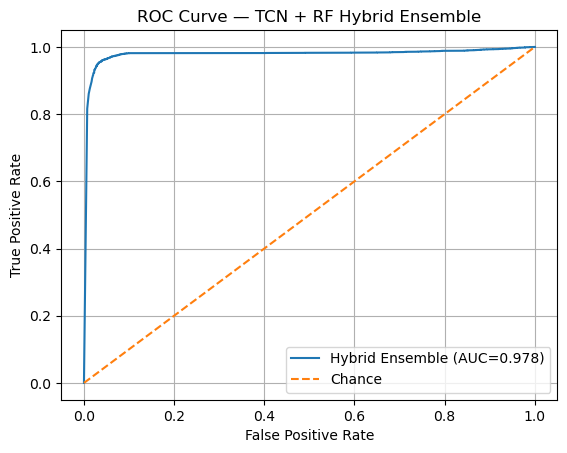

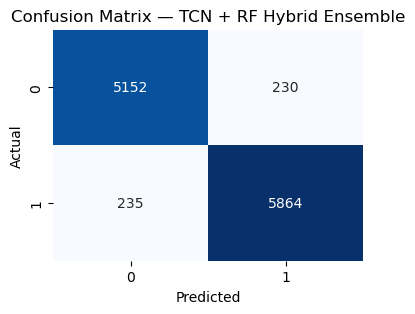

In [ ]:
# ============================================================
# TCN + RF Dual-Meta-MLP Hybrid (Improved, No OOF)
# ============================================================

import numpy as np
import tensorflow as tf
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import Dense, Dropout, LayerNormalization, Add
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve
)
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------
# Reproducibility
# ---------------------------
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ============================================================
# Step 0: TCN outputs (base model 1)
# ============================================================

# Safely convert DataFrame or ndarray → NumPy
X_train_np = np.asarray(X_train_final, dtype=np.float32)
X_test_np  = np.asarray(X_test_final, dtype=np.float32)

# Reshape to TCN format: (samples, timesteps/features, channels)
X_train_tcn_input = X_train_np.reshape(-1, X_train_np.shape[1], 1)
X_test_tcn_input  = X_test_np.reshape(-1, X_test_np.shape[1], 1)

# TCN predictions (final_tcn must already be trained)
tcn_proba_train = final_tcn.predict(X_train_tcn_input, verbose=0).flatten()
tcn_proba_test  = final_tcn.predict(X_test_tcn_input,  verbose=0).flatten()

# ============================================================
# Step 1: Base Random Forest model (base model 2) + Calibration
# ============================================================
rf_base = RandomForestClassifier(
    n_estimators=800,
    max_depth=40,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=0.3,
    bootstrap=False,
    random_state=SEED,
    n_jobs=-1
)

cal_rf = CalibratedClassifierCV(
    estimator=rf_base,
    cv=5,
    method='sigmoid'
)

cal_rf.fit(X_train_np, y_train)

rf_proba_train = cal_rf.predict_proba(X_train_np)[:, 1]
rf_proba_test  = cal_rf.predict_proba(X_test_np)[:, 1]

# ============================================================
# Step 2: Build richer meta-inputs (no OOF, just hybrid)
# ============================================================
def build_meta_features(p_tcn_train, p_rf_train, p_tcn_test, p_rf_test):
    def make_features(p_tcn, p_rf):
        avg = 0.5 * p_tcn + 0.5 * p_rf
        diff = p_tcn - p_rf
        prod = p_tcn * p_rf
        abs_diff = np.abs(diff)
        tcn_sq = p_tcn ** 2
        rf_sq  = p_rf ** 2

        return np.column_stack([
            p_tcn,      # 1
            p_rf,       # 2
            avg,        # 3
            diff,       # 4
            prod,       # 5
            abs_diff,   # 6
            tcn_sq,     # 7
            rf_sq       # 8
        ])

    meta_train = make_features(p_tcn_train, p_rf_train)
    meta_test  = make_features(p_tcn_test,  p_rf_test)
    return meta_train, meta_test

meta_input_train, meta_input_test = build_meta_features(
    tcn_proba_train, rf_proba_train,
    tcn_proba_test,  rf_proba_test
)

# ============================================================
# Step 3: Meta-MLP builder (residual, stronger capacity)
# ============================================================
def build_meta_mlp(input_dim, lr=3e-4, dropout_main=0.15, dropout_res=0.10):
    inputs = Input(shape=(input_dim,))

    # Main block
    x = Dense(128, activation='relu')(inputs)
    x = LayerNormalization()(x)
    x = Dropout(dropout_main)(x)

    # Residual block 1
    r = Dense(128, activation='relu')(x)
    r = Dropout(dropout_res)(r)
    x = Add()([x, r])

    # Residual block 2
    r = Dense(128, activation='relu')(x)
    r = Dropout(dropout_res)(r)
    x = Add()([x, r])

    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(lr), loss='binary_crossentropy', metrics=['accuracy'])
    return model

meta_model_1 = build_meta_mlp(meta_input_train.shape[1],
                              lr=3e-4, dropout_main=0.15, dropout_res=0.10)
meta_model_2 = build_meta_mlp(meta_input_train.shape[1],
                              lr=5e-4, dropout_main=0.20, dropout_res=0.10)

es = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

# ============================================================
# Step 4: Train meta-MLPs
# ============================================================
meta_model_1.fit(
    meta_input_train, y_train,
    epochs=200,
    batch_size=128,
    validation_split=0.1,
    callbacks=[es],
    verbose=1
)

meta_model_2.fit(
    meta_input_train, y_train,
    epochs=200,
    batch_size=128,
    validation_split=0.1,
    callbacks=[es],
    verbose=1
)

# ============================================================
# Step 5: Meta predictions + weight search
# ============================================================
proba_1 = meta_model_1.predict(meta_input_test, verbose=0).flatten()
proba_2 = meta_model_2.predict(meta_input_test, verbose=0).flatten()

def find_best_weights(proba_1, proba_2, y_true, step=0.01):
    best_w = 0.0
    best_acc = 0.0
    best_pred = None
    best_proba = None

    for w1 in np.arange(0, 1 + step, step):
        w2 = 1 - w1
        ensemble_proba = w1 * proba_1 + w2 * proba_2
        ensemble_pred = (ensemble_proba >= 0.5).astype(int)

        acc = accuracy_score(y_true, ensemble_pred)

        if acc > best_acc:
            best_acc = acc
            best_w = w1
            best_pred = ensemble_pred
            best_proba = ensemble_proba

    return best_w, 1 - best_w, best_acc, best_pred, best_proba

best_w1, best_w2, best_acc_05, best_pred_05, best_proba_raw = find_best_weights(
    proba_1, proba_2, y_test, step=0.01
)

print("\n========== Best Ensemble Weight Search (threshold=0.5) ==========")
print(f"Best w1 (meta_model_1): {best_w1:.2f}")
print(f"Best w2 (meta_model_2): {best_w2:.2f}")
print(f"Best Accuracy (0.5 thr): {best_acc_05:.4f}")

# ============================================================
# Step 6: Threshold search to maximize accuracy
# ============================================================
def find_best_accuracy_threshold(proba, y_true, step=0.001):
    best_thr = 0.5
    best_acc = 0
    best_pred = None

    for thr in np.arange(0, 1, step):
        pred = (proba >= thr).astype(int)
        acc = accuracy_score(y_true, pred)
        if acc > best_acc:
            best_acc = acc
            best_thr = thr
            best_pred = pred

    return best_thr, best_acc, best_pred

best_thr, best_acc_thr, best_pred_thr = find_best_accuracy_threshold(best_proba_raw, y_test)

print("\n========== Threshold Search (Max Accuracy) ==========")
print(f"Best Accuracy Threshold : {best_thr:.4f}")
print(f"Best Accuracy           : {best_acc_thr:.4f}")

ensemble_proba = best_proba_raw
ensemble_pred  = best_pred_thr

# ============================================================
# Step 7: Metrics
# ============================================================
tn, fp, fn, tp = confusion_matrix(y_test, ensemble_pred, labels=[0, 1]).ravel()

accuracy  = accuracy_score(y_test, ensemble_pred)
precision = precision_score(y_test, ensemble_pred)
recall    = recall_score(y_test, ensemble_pred)
f1        = f1_score(y_test, ensemble_pred)
fpr       = fp / (fp + tn)
auc_roc   = roc_auc_score(y_test, ensemble_proba)

print("\n========== Final TCN + RF Dual-Meta-MLP Hybrid ==========")
print(f"Accuracy           : {accuracy:.4f}")
print(f"Precision          : {precision:.4f}")
print(f"Recall             : {recall:.4f}")
print(f"F1-score           : {f1:.4f}")
print(f"FPR                : {fpr:.4f}")
print(f"AUC-ROC            : {auc_roc:.4f}")
print(f"Used threshold     : {best_thr:.4f}")
print(f"Best weights w1/w2 : {best_w1:.2f} / {best_w2:.2f}")

# ============================================================
# Step 8: Plots
# ============================================================
# ROC Curve
fpr_plot, tpr_plot, _ = roc_curve(y_test, ensemble_proba)
plt.figure()
plt.plot(fpr_plot, tpr_plot, label=f'Hybrid Ensemble (AUC={auc_roc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', label='Chance')
plt.title('ROC Curve — TCN + RF Hybrid Ensemble')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.show()

# Confusion Matrix
cm = np.array([[tn, fp], [fn, tp]])
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — TCN + RF Hybrid Ensemble')
plt.show()
